### Basic neural activity analysis with single camera tracking
#### analyze the firing rate PC1,2,3
#### making the demo videos
#### the following detailed analysis focused on pull related behavioral events
#### the pull action start events are defined based on the movement onset before each pull
#### capture the entire section of neural activity from Pull Start/Onset to pull actions
#### include multiple ways to defined trial start; such as based on speed, or pca that consider multiple continuous variables

In [1]:
# note:
# need to use pyddm environment to run this

In [2]:
import pandas as pd
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import seaborn 
import seaborn as sns
import scipy
import scipy.stats as st
import scipy.io
from sklearn.neighbors import KernelDensity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import string
import warnings
import pickle
import json

from scipy.ndimage import gaussian_filter1d

import os
import glob
import random
from time import time

from scipy.ndimage import label


### function - get body part location for each pair of cameras

In [3]:
from ana_functions.body_part_locs_eachpair import body_part_locs_eachpair
from ana_functions.body_part_locs_singlecam import body_part_locs_singlecam

### function - align the two cameras

In [4]:
from ana_functions.camera_align import camera_align       

### function - merge the two pairs of cameras

In [5]:
from ana_functions.camera_merge import camera_merge

### function - find social gaze time point

In [6]:
from ana_functions.find_socialgaze_timepoint import find_socialgaze_timepoint
from ana_functions.find_socialgaze_timepoint_singlecam import find_socialgaze_timepoint_singlecam
from ana_functions.find_socialgaze_timepoint_singlecam_wholebody import find_socialgaze_timepoint_singlecam_wholebody
from ana_functions.find_socialgaze_timepoint_singlecam_wholebody_2 import find_socialgaze_timepoint_singlecam_wholebody_2


### function - define time point of behavioral events

In [7]:
from ana_functions.bhv_events_timepoint import bhv_events_timepoint
from ana_functions.bhv_events_timepoint_singlecam import bhv_events_timepoint_singlecam

### function - plot behavioral events

In [8]:
from ana_functions.plot_bhv_events import plot_bhv_events
from ana_functions.plot_bhv_events_levertube import plot_bhv_events_levertube
from ana_functions.plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection import plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection
from ana_functions.plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection_highbhvDimension_to_lowPCspace import plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection_highbhvDimension_to_lowPCspace


from ana_functions.draw_self_loop import draw_self_loop
import matplotlib.patches as mpatches 
from matplotlib.collections import PatchCollection

### function - plot inter-pull interval

In [9]:
from ana_functions.plot_interpull_interval import plot_interpull_interval

### function - make demo videos with skeleton and inportant vectors

In [10]:
from ana_functions.tracking_video_singlecam_demo import tracking_video_singlecam_demo
from ana_functions.tracking_video_singlecam_wholebody_demo import tracking_video_singlecam_wholebody_demo
from ana_functions.tracking_video_singlecam_wholebody_withNeuron_demo import tracking_video_singlecam_wholebody_withNeuron_demo
from ana_functions.tracking_video_singlecam_wholebody_withNeuron_sepbhv_demo import tracking_video_singlecam_wholebody_withNeuron_sepbhv_demo
from ana_functions.tracking_frame_singlecam_wholebody_withNeuron_sepbhv_demo import tracking_frame_singlecam_wholebody_withNeuron_sepbhv_demo

### function - interval between all behavioral events

In [11]:
from ana_functions.bhv_events_interval import bhv_events_interval

### function - spike analysis

In [12]:
from ana_functions.spike_analysis_FR_calculation import spike_analysis_FR_calculation
from ana_functions.plot_spike_triggered_singlecam_bhvevent import plot_spike_triggered_singlecam_bhvevent
from ana_functions.plot_bhv_events_aligned_FR_PullStartToPull_variedSection import plot_bhv_events_aligned_FR_PullStartToPull_variedSection
from ana_functions.plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection_highbhvDimension_to_lowPCspace import plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection_highbhvDimension_to_lowPCspace

from ana_functions.plot_strategy_aligned_FR import plot_strategy_aligned_FR

### function - PCA projection

In [13]:
from ana_functions.PCA_around_bhv_events import PCA_around_bhv_events
from ana_functions.PCA_around_bhv_events_video import PCA_around_bhv_events_video
from ana_functions.confidence_ellipse import confidence_ellipse

### function - other useful functions

In [14]:
# for defining the meaningful social gaze (the continuous gaze distribution that is closest to the pull) 
from ana_functions.keep_closest_cluster_single_trial import keep_closest_cluster_single_trial

In [15]:
# get useful information about pulls
from ana_functions.get_pull_infos import get_pull_infos

In [16]:
# use the gaze vector speed and face mass speed to find the pull action start time within IPI
from ana_functions.find_sharp_increases_withinIPI import find_sharp_increases_withinIPI
from ana_functions.find_sharp_increases_withinIPI import find_sharp_increases_withinIPI_dual_speed

In [17]:
# method 2: find the lowest timepoint then the increase point as the pull onset
from ana_functions.find_rising_onset_after_min_withinIPI import find_rising_onset_after_min_withinIPI
from ana_functions.find_rising_onset_after_min_withinIPI import find_rising_onset_after_min_dual_speed

In [18]:
# method 2: find the lowest timepoint then the increase point as the pull onset
from ana_functions.find_rising_onset_after_min_withinIPI import find_rising_onset_after_min_withinIPI
from ana_functions.find_rising_onset_after_min_withinIPI import find_rising_onset_after_min_dual_speed

## Analyze each session

### prepare the basic behavioral data (especially the time stamps for each bhv events)

In [28]:
# instead of using gaze angle threshold, use the target rectagon to deside gaze info
# ...need to update
sqr_thres_tubelever = 75 # draw the square around tube and lever
sqr_thres_face = 1.15 # a ratio for defining face boundary
sqr_thres_body = 4 # how many times to enlongate the face box boundry to the body


# get the fps of the analyzed video
fps = 30

# get the fs for neural recording
fs_spikes = 20000
fs_lfp = 1000

# frame number of the demo video
nframes = 0.5*30 # second*30fps
# nframes = 45*30 # second*30fps

# re-analyze the video or not
reanalyze_video = 0
redo_anystep = 1

# if use onset of the first increase after min
doOnsetAfterMin = 1
if not doOnsetAfterMin:
    doOnsetAfterMin_suffix = ''
elif doOnsetAfterMin:
    doOnsetAfterMin_suffix = 'PullOnsetAfterMin_'

# if use a hmm based method to find the trial start
doHMMmethod = 0
if doHMMmethod:
    doOnsetAfterMin_suffix = 'HMMmethods_'

    

# do OFC sessions or DLPFC sessions
do_OFC = 0
do_DLPFC  = 1
if do_OFC:
    savefile_sufix = '_OFCs'
elif do_DLPFC:
    savefile_sufix = '_DLPFCs'
else:
    savefile_sufix = ''
    
# all the videos (no misaligned ones)
# aligned with the audio
# get the session start time from "videosound_bhv_sync.py/.ipynb"
# currently the session_start_time will be manually typed in. It can be updated after a better method is used


# dodson ginger
if 1:
    if do_DLPFC:
        neural_record_conditions = [
                                    '20240531_Dodson_MC',
                                    '20240603_Dodson_MC_and_SR',
                                    '20240603_Dodson_MC_and_SR',
                                    '20240604_Dodson_MC',
                                    '20240605_Dodson_MC_and_SR',
                                    '20240605_Dodson_MC_and_SR',
                                    '20240606_Dodson_MC_and_SR',
                                    '20240606_Dodson_MC_and_SR',
                                    '20240607_Dodson_SR',
                                    '20240610_Dodson_MC',
                                    '20240611_Dodson_SR',
                                    '20240612_Dodson_MC',
                                    '20240613_Dodson_SR',
                                    '20240620_Dodson_SR',
                                    '20240719_Dodson_MC',
                                        
                                    '20250129_Dodson_MC',
                                    '20250130_Dodson_SR',
                                    '20250131_Dodson_MC',
                                
            
                                    '20250210_Dodson_SR_withKoala',
                                    '20250211_Dodson_MC_withKoala',
                                    '20250212_Dodson_SR_withKoala',
                                    '20250214_Dodson_MC_withKoala',
                                    '20250217_Dodson_SR_withKoala',
                                    '20250218_Dodson_MC_withKoala',
                                    '20250219_Dodson_SR_withKoala',
                                    '20250220_Dodson_MC_withKoala',
                                    '20250224_Dodson_KoalaAL_withKoala',
                                    '20250226_Dodson_MC_withKoala',
                                    '20250227_Dodson_KoalaAL_withKoala',
                                    '20250228_Dodson_DodsonAL_withKoala',
                                    '20250304_Dodson_DodsonAL_withKoala',
                                    '20250305_Dodson_MC_withKoala',
                                    '20250306_Dodson_KoalaAL_withKoala',
                                    '20250307_Dodson_DodsonAL_withKoala',
                                    '20250310_Dodson_MC_withKoala',
                                    '20250312_Dodson_NV_withKoala',
                                    '20250313_Dodson_NV_withKoala',
                                    '20250314_Dodson_NV_withKoala',
            
                                    '20250401_Dodson_MC_withKanga',
                                    '20250402_Dodson_MC_withKanga',
                                    '20250403_Dodson_MC_withKanga',
                                    '20250404_Dodson_SR_withKanga',
                                    '20250407_Dodson_SR_withKanga',
                                    '20250408_Dodson_SR_withKanga',
                                    '20250409_Dodson_MC_withKanga',
            
                                    '20250415_Dodson_MC_withKanga',
                                    # '20250416_Dodson_SR_withKanga', # has to remove from the later analysis, recording has problems
                                    '20250417_Dodson_MC_withKanga',
                                    '20250418_Dodson_SR_withKanga',
                                    '20250421_Dodson_SR_withKanga',
                                    '20250422_Dodson_MC_withKanga',
                                    '20250422_Dodson_SR_withKanga',
            
                                    '20250423_Dodson_MC_withKanga',
                                    '20250423_Dodson_SR_withKanga', 
                                    '20250424_Dodson_NV_withKanga',
                                    '20250424_Dodson_MC_withKanga',
                                    '20250424_Dodson_SR_withKanga',            
                                    '20250425_Dodson_NV_withKanga',
                                    '20250425_Dodson_SR_withKanga',
                                    '20250428_Dodson_NV_withKanga',
                                    '20250428_Dodson_MC_withKanga',
                                    '20250428_Dodson_SR_withKanga',  
                                    '20250429_Dodson_NV_withKanga',
                                    '20250429_Dodson_MC_withKanga',
                                    '20250429_Dodson_SR_withKanga',  
                                    '20250430_Dodson_NV_withKanga',
                                    '20250430_Dodson_MC_withKanga',
                                    '20250430_Dodson_SR_withKanga',  
            
                                   ]
        task_conditions = [
                            'MC',           
                            'MC',
                            'SR',
                            'MC',
                            'MC',
                            'SR',
                            'MC',
                            'SR',
                            'SR',
                            'MC',
                            'SR',
                            'MC',
                            'SR',
                            'SR',
                            'MC',
                            
                            'MC_withGingerNew',
                            'SR_withGingerNew',
                            'MC_withGingerNew',
            
                            'SR_withKoala',
                            'MC_withKoala',
                            'SR_withKoala',
                            'MC_withKoala',
                            'SR_withKoala',
                            'MC_withKoala',
                            'SR_withKoala',
                            'MC_withKoala',
                            'MC_KoalaAuto_withKoala',
                            'MC_withKoala',
                            'MC_KoalaAuto_withKoala',
                            'MC_DodsonAuto_withKoala',
                            'MC_DodsonAuto_withKoala',
                            'MC_withKoala',
                            'MC_KoalaAuto_withKoala',
                            'MC_DodsonAuto_withKoala',
                            'MC_withKoala',
                            'NV_withKoala',
                            'NV_withKoala',
                            'NV_withKoala',

                            'MC_withKanga',
                            'MC_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',
                            'SR_withKanga',
                            'SR_withKanga',
                            'MC_withKanga',
            
                            'MC_withKanga',
                            # 'SR_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',
                            'SR_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',
            
                            'MC_withKanga',
                            'SR_withKanga', 
                            'NV_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',            
                            'NV_withKanga',
                            'SR_withKanga',
                            'NV_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',  
                            'NV_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',  
                            'NV_withKanga',
                            'MC_withKanga',
                            'SR_withKanga',  
                          ]
        dates_list = [
                        '20240531',
                        '20240603_MC',
                        '20240603_SR',
                        '20240604',
                        '20240605_MC',
                        '20240605_SR',
                        '20240606_MC',
                        '20240606_SR',
                        '20240607',
                        '20240610_MC',
                        '20240611',
                        '20240612',
                        '20240613',
                        '20240620',
                        '20240719',
            
                        '20250129',
                        '20250130',
                        '20250131',
            
                        '20250210',
                        '20250211',
                        '20250212',
                        '20250214',
                        '20250217',
                        '20250218',
                        '20250219',
                        '20250220',
                        '20250224',
                        '20250226',
                        '20250227',
                        '20250228',
                        '20250304',
                        '20250305',
                        '20250306',
                        '20250307',
                        '20250310',
                        '20250312',
                        '20250313',
                        '20250314',
            
                        '20250401',
                        '20250402',
                        '20250403',
                        '20250404',
                        '20250407',
                        '20250408',
                        '20250409',
            
                        '20250415',
                        # '20250416',
                        '20250417',
                        '20250418',
                        '20250421',
                        '20250422',
                        '20250422_SR',
            
                        '20250423',
                        '20250423_SR', 
                        '20250424',
                        '20250424_MC',
                        '20250424_SR',            
                        '20250425',
                        '20250425_SR',
                        '20250428_NV',
                        '20250428_MC',
                        '20250428_SR',  
                        '20250429_NV',
                        '20250429_MC',
                        '20250429_SR',  
                        '20250430_NV',
                        '20250430_MC',
                        '20250430_SR',  
                     ]
        videodates_list = [
                            '20240531',
                            '20240603',
                            '20240603',
                            '20240604',
                            '20240605',
                            '20240605',
                            '20240606',
                            '20240606',
                            '20240607',
                            '20240610_MC',
                            '20240611',
                            '20240612',
                            '20240613',
                            '20240620',
                            '20240719',
            
                            '20250129',
                            '20250130',
                            '20250131',
                            
                            '20250210',
                            '20250211',
                            '20250212',
                            '20250214',
                            '20250217',
                            '20250218',          
                            '20250219',
                            '20250220',
                            '20250224',
                            '20250226',
                            '20250227',
                            '20250228',
                            '20250304',
                            '20250305',
                            '20250306',
                            '20250307',
                            '20250310',
                            '20250312',
                            '20250313',
                            '20250314',
            
                            '20250401',
                            '20250402',
                            '20250403',
                            '20250404',
                            '20250407',
                            '20250408',
                            '20250409',
            
                            '20250415',
                            # '20250416',
                            '20250417',
                            '20250418',
                            '20250421',
                            '20250422',
                            '20250422_SR',
            
                            '20250423',
                            '20250423_SR', 
                            '20250424',
                            '20250424_MC',
                            '20250424_SR',            
                            '20250425',
                            '20250425_SR',
                            '20250428_NV',
                            '20250428_MC',
                            '20250428_SR',  
                            '20250429_NV',
                            '20250429_MC',
                            '20250429_SR',  
                            '20250430_NV',
                            '20250430_MC',
                            '20250430_SR',  
            
                          ] # to deal with the sessions that MC and SR were in the same session
        session_start_times = [ 
                                0.00,
                                340,
                                340,
                                72.0,
                                60.1,
                                60.1,
                                82.2,
                                82.2,
                                35.8,
                                0.00,
                                29.2,
                                35.8,
                                62.5,
                                71.5,
                                54.4,
            
                                0.00,
                                0.00,
                                0.00,
            
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
            
                                0.00,
                                0.00,
                                73.5,
                                0.00,
                                76.1,
                                81.5,
                                0.00,
            
                                363,
                                # 0.00,
                                79.0,
                                162.6,
                                231.9,
                                109,
                                0.00,
            
                                0.00,
                                0.00, 
                                0.00,
                                0.00,
                                0.00,          
                                0.00,
                                93.0,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00, 
                                0.00,
                                274.4,
                                0.00,
            
                              ] # in second
        
        kilosortvers = list((np.ones(np.shape(dates_list))*4).astype(int))
        
        trig_channelnames = [ 'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0',# 'Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                              'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                             
                              ]
        animal1_fixedorders = ['dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson',# 'dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson',
                              ]
        recordedanimals = animal1_fixedorders 
        animal2_fixedorders = ['ginger','ginger','ginger','ginger','ginger','ginger','ginger','ginger','ginger',
                               'ginger','ginger','ginger','ginger','ginger','ginger','gingerNew','gingerNew','gingerNew',
                               'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala',
                               'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala', 'koala',
                               'koala', 'koala', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga', # 'kanga', 
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                               'kanga', 'kanga', 'kanga', 'kanga', 'kanga',
                              ]

        animal1_filenames = ["Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             'Dodson',# 'Dodson',
                             'Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson',
                             'Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson','Dodson',
                             'Dodson','Dodson','Dodson','Dodson','Dodson',
                            ]
        animal2_filenames = ["Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger",
                             "Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger","Ginger",
                             "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala",
                             "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala", "Koala",
                             "Koala", "Koala", "Kanga", "Kanga", "Kanga", "Kanga", "Kanga", "Kanga", "Kanga",
                             'Kanga', # 'Kanga', 
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                             'Kanga', 'Kanga', 'Kanga', 'Kanga', 'Kanga',
                            ]
        
    elif do_OFC:
        # pick only five sessions for each conditions
        neural_record_conditions = [
                                     '20231101_Dodson_withGinger_MC',
                                     '20231107_Dodson_withGinger_MC',
                                     '20231122_Dodson_withGinger_MC',
                                     '20231129_Dodson_withGinger_MC',
                                     # '20231101_Dodson_withGinger_SR',
                                     # '20231107_Dodson_withGinger_SR',
                                     # '20231122_Dodson_withGinger_SR',
                                     # '20231129_Dodson_withGinger_SR',
                                   ]
        task_conditions = [
                            'MC',
                            'MC',
                            'MC',
                            'MC',
                            # 'SR',
                            # 'SR',
                            # 'SR',
                            # 'SR',
                          ]
        dates_list = [
                      "20231101_MC",
                      "20231107_MC",
                      "20231122_MC",
                      "20231129_MC",
                      # "20231101_SR",
                      # "20231107_SR",
                      # "20231122_SR",
                      # "20231129_SR",      
                     ]
        videodates_list = dates_list
        session_start_times = [ 
                                 0.00,   
                                 0.00,  
                                 0.00,  
                                 0.00, 
                                 # 0.00,   
                                 # 0.00,  
                                 # 0.00,  
                                 # 0.00, 
                              ] # in second
        kilosortvers = [ 
                         2, 
                         2, 
                         4, 
                         4,
                         # 2, 
                         # 2, 
                         # 4, 
                         # 4,
                       ]
    
        trig_channelnames = ['Dev1/ai0']*np.shape(dates_list)[0]
        animal1_fixedorders = ['dodson']*np.shape(dates_list)[0]
        recordedanimals = animal1_fixedorders
        animal2_fixedorders = ['ginger']*np.shape(dates_list)[0]

        animal1_filenames = ["Dodson"]*np.shape(dates_list)[0]
        animal2_filenames = ["Ginger"]*np.shape(dates_list)[0]

    
# dannon kanga
if 0:
    if do_DLPFC:
        neural_record_conditions = [
                                     '20240508_Kanga_SR',
                                     '20240509_Kanga_MC',
                                     '20240513_Kanga_MC',
                                     '20240514_Kanga_SR',
                                     '20240523_Kanga_MC',
                                     '20240524_Kanga_SR',
                                     '20240606_Kanga_MC',
                                     '20240613_Kanga_MC_DannonAuto',
                                     '20240614_Kanga_MC_DannonAuto',
                                     '20240617_Kanga_MC_DannonAuto',
                                     '20240618_Kanga_MC_KangaAuto',
                                     '20240619_Kanga_MC_KangaAuto',
                                     '20240620_Kanga_MC_KangaAuto',
                                     '20240621_1_Kanga_NoVis',
                                     '20240624_Kanga_NoVis',
                                     '20240626_Kanga_NoVis',
            
                                     '20240808_Kanga_MC_withGinger',
                                     '20240809_Kanga_MC_withGinger',
                                     '20240812_Kanga_MC_withGinger',
                                     '20240813_Kanga_MC_withKoala',
                                     '20240814_Kanga_MC_withKoala',
                                     '20240815_Kanga_MC_withKoala',
                                     '20240819_Kanga_MC_withVermelho',
                                     '20240821_Kanga_MC_withVermelho',
                                     '20240822_Kanga_MC_withVermelho',
            
                                     '20250415_Kanga_MC_withDodson',
                                     '20250416_Kanga_SR_withDodson',
                                     '20250417_Kanga_MC_withDodson',
                                     '20250418_Kanga_SR_withDodson',
                                     '20250421_Kanga_SR_withDodson',
                                     '20250422_Kanga_MC_withDodson',
                                     '20250422_Kanga_SR_withDodson',
            
                                    '20250423_Kanga_MC_withDodson',
                                    '20250423_Kanga_SR_withDodson', 
                                    '20250424_Kanga_NV_withDodson',
                                    '20250424_Kanga_MC_withDodson',
                                    '20250424_Kanga_SR_withDodson',            
                                    '20250425_Kanga_NV_withDodson',
                                    '20250425_Kanga_SR_withDodson',
                                    '20250428_Kanga_NV_withDodson',
                                    '20250428_Kanga_MC_withDodson',
                                    '20250428_Kanga_SR_withDodson',  
                                    '20250429_Kanga_NV_withDodson',
                                    '20250429_Kanga_MC_withDodson',
                                    '20250429_Kanga_SR_withDodson',  
                                    '20250430_Kanga_NV_withDodson',
                                    '20250430_Kanga_MC_withDodson',
                                    '20250430_Kanga_SR_withDodson',  
                                   ]
        dates_list = [
                      "20240508",
                      "20240509",
                      "20240513",
                      "20240514",
                      "20240523",
                      "20240524",
                      "20240606",
                      "20240613",
                      "20240614",
                      "20240617",
                      "20240618",
                      "20240619",
                      "20240620",
                      "20240621_1",
                      "20240624",
                      "20240626",
            
                      "20240808",
                      "20240809",
                      "20240812",
                      "20240813",
                      "20240814",
                      "20240815",
                      "20240819",
                      "20240821",
                      "20240822",
            
                      "20250415",
                      "20250416",
                      "20250417",
                      "20250418",
                      "20250421",
                      "20250422",
                      "20250422_SR",
            
                        '20250423',
                        '20250423_SR', 
                        '20250424',
                        '20250424_MC',
                        '20250424_SR',            
                        '20250425',
                        '20250425_SR',
                        '20250428_NV',
                        '20250428_MC',
                        '20250428_SR',  
                        '20250429_NV',
                        '20250429_MC',
                        '20250429_SR',  
                        '20250430_NV',
                        '20250430_MC',
                        '20250430_SR',  
                     ]
        videodates_list = dates_list
        task_conditions = [
                             'SR',
                             'MC',
                             'MC',
                             'SR',
                             'MC',
                             'SR',
                             'MC',
                             'MC_DannonAuto',
                             'MC_DannonAuto',
                             'MC_DannonAuto',
                             'MC_KangaAuto',
                             'MC_KangaAuto',
                             'MC_KangaAuto',
                             'NV',
                             'NV',
                             'NV',   
                            
                             'MC_withGinger',
                             'MC_withGinger',
                             'MC_withGinger',
                             'MC_withKoala',
                             'MC_withKoala',
                             'MC_withKoala',
                             'MC_withVermelho',
                             'MC_withVermelho',
                             'MC_withVermelho',
            
                             'MC_withDodson',
                             'SR_withDodson',
                             'MC_withDodson',
                             'SR_withDodson',
                             'SR_withDodson',
                             'MC_withDodson',
                             'SR_withDodson',
            
                             'MC_withDodson',
                            'SR_withDodson', 
                            'NV_withDodson',
                            'MC_withDodson',
                            'SR_withDodson',            
                            'NV_withDodson',
                            'SR_withDodson',
                            'NV_withDodson',
                            'MC_withDodson',
                            'SR_withDodson',  
                            'NV_withDodson',
                            'MC_withDodson',
                            'SR_withDodson',  
                            'NV_withDodson',
                            'MC_withDodson',
                            'SR_withDodson',  
                          ]
        session_start_times = [ 
                                 0.00,
                                 36.0,
                                 69.5,
                                 0.00,
                                 62.0,
                                 0.00,
                                 89.0,
                                 0.00,
                                 0.00,
                                 0.00,
                                 165.8,
                                 96.0, 
                                 0.00,
                                 0.00,
                                 0.00,
                                 48.0,
                                
                                 59.2,
                                 49.5,
                                 40.0,
                                 50.0,
                                 0.00,
                                 69.8,
                                 85.0,
                                 212.9,
                                 68.5,
            
                                 363,
                                 0.00,
                                 79.0,
                                 162.6,
                                 231.9,
                                 109,
                                 0.00,
            
                                0.00,
                                0.00, 
                                0.00,
                                0.00,
                                0.00,          
                                0.00,
                                93.0,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00,
                                0.00, 
                                0.00,
                                274.4,
                                0.00,
                              ] # in second
        kilosortvers = list((np.ones(np.shape(dates_list))*4).astype(int))
        
        trig_channelnames = ['Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                             'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                             'Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0','Dev1/ai0',
                             'Dev1/ai0','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai0','Dev1/ai0',
                             'Dev1/ai0','Dev1/ai0','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9',
                             'Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9','Dev1/ai9',
                              ]
        
        animal1_fixedorders = ['dannon','dannon','dannon','dannon','dannon','dannon','dannon','dannon',
                               'dannon','dannon','dannon','dannon','dannon','dannon','dannon','dannon',
                               'ginger','ginger','ginger','koala','koala','koala','vermelho','vermelho',
                               'vermelho','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                               'dodson','dodson','dodson','dodson','dodson','dodson','dodson','dodson',
                              ]
        animal2_fixedorders = ['kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                               'kanga','kanga','kanga','kanga','kanga','kanga','kanga','kanga',
                              ]
        recordedanimals = animal2_fixedorders

        animal1_filenames = ["Dannon","Dannon","Dannon","Dannon","Dannon","Dannon","Dannon","Dannon",
                             "Dannon","Dannon","Dannon","Dannon","Dannon","Dannon","Dannon","Dannon",
                             "Ginger","Ginger","Ginger", "Kanga", "Kanga", "Kanga", "Kanga", "Kanga",
                              "Kanga","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             "Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson","Dodson",
                             
                            ]
        animal2_filenames = ["Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                             "Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                             "Kanga","Kanga","Kanga","Koala","Koala","Koala","Vermelho","Vermelho",
                             "Vermelho","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                             "Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                             "Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga","Kanga",
                            ]
        
    elif do_OFC:
        # pick only five sessions for each conditions
        neural_record_conditions = [
                                     
                                   ]
        dates_list = [
                      
                     ]
        videodates_list = dates_list
        task_conditions = [
                           
                          ]
        session_start_times = [ 
                                
                              ] # in second
        kilosortvers = [ 

                       ]
    
        animal1_fixedorders = ['dannon']*np.shape(dates_list)[0]
        animal2_fixedorders = ['kanga']*np.shape(dates_list)[0]
        recordedanimals = animal2_fixedorders
        
        animal1_filenames = ["Dannon"]*np.shape(dates_list)[0]
        animal2_filenames = ["Kanga"]*np.shape(dates_list)[0]
    

    
# a test case
if 0: # kanga example
    neural_record_conditions = ['20250415_Kanga_MC_withDodson']
    dates_list = ["20250415"]
    videodates_list = dates_list
    task_conditions = ['MC_withDodson']
    session_start_times = [363] # in second
    kilosortvers = [4]
    trig_channelnames = ['Dev1/ai9']
    animal1_fixedorders = ['dodson']
    animal2_fixedorders = ['kanga']
    recordedanimals = animal2_fixedorders
    animal1_filenames = ["Dodson"]
    animal2_filenames = ["Kanga"]
if 1: # dodson example 
    neural_record_conditions = ['20250415_Dodson_MC_withKanga']
    dates_list = ["20250415"]
    videodates_list = dates_list
    task_conditions = ['MC_withKanga']
    session_start_times = [363] # in second
    kilosortvers = [4]
    trig_channelnames = ['Dev1/ai0']
    animal1_fixedorders = ['dodson']
    recordedanimals = animal1_fixedorders
    animal2_fixedorders = ['kanga']
    animal1_filenames = ["Dodson"]
    animal2_filenames = ["Kanga"]
    
ndates = np.shape(dates_list)[0]

session_start_frames = session_start_times * fps # fps is 30Hz

# totalsess_time = 600

# video tracking results info
animalnames_videotrack = ['dodson','scorch'] # does not really mean dodson and scorch, instead, indicate animal1 and animal2
bodypartnames_videotrack = ['rightTuft','whiteBlaze','leftTuft','rightEye','leftEye','mouth']


# which camera to analyzed
cameraID = 'camera-2'
cameraID_short = 'cam2'

considerlevertube = 1
considertubeonly = 0

# location of levers and tubes for camera 2
# # camera 1
# lever_locs_camI = {'dodson':np.array([645,600]),'scorch':np.array([425,435])}
# tube_locs_camI  = {'dodson':np.array([1350,630]),'scorch':np.array([555,345])}
# # camera 2
# # location of the estimiated middle of the box
lever_locs_camI = {'dodson':np.array([1325,615]),'scorch':np.array([560,615])}
# # location of the estimated lever
# lever_locs_camI = {'dodson':np.array([1335,715]),'scorch':np.array([550,715])}
tube_locs_camI  = {'dodson':np.array([1550,515]),'scorch':np.array([350,515])}
# # old
# # lever_locs_camI = {'dodson':np.array([1335,715]),'scorch':np.array([550,715])}
# # tube_locs_camI  = {'dodson':np.array([1650,490]),'scorch':np.array([250,490])}
# # camera 3
# lever_locs_camI = {'dodson':np.array([1580,440]),'scorch':np.array([1296,540])}
# tube_locs_camI  = {'dodson':np.array([1470,375]),'scorch':np.array([805,475])}


if np.shape(session_start_times)[0] != np.shape(dates_list)[0]:
    exit()

    
# define bhv events summarizing variables     
tasktypes_all_dates = np.zeros((ndates,1))
coopthres_all_dates = np.zeros((ndates,1))

succ_rate_all_dates = np.zeros((ndates,1))
interpullintv_all_dates = np.zeros((ndates,1))
trialnum_all_dates = np.zeros((ndates,1))

owgaze1_num_all_dates = np.zeros((ndates,1))
owgaze2_num_all_dates = np.zeros((ndates,1))
mtgaze1_num_all_dates = np.zeros((ndates,1))
mtgaze2_num_all_dates = np.zeros((ndates,1))
pull1_num_all_dates = np.zeros((ndates,1))
pull2_num_all_dates = np.zeros((ndates,1))

pull1_intv_all_dates = np.zeros((ndates,1))
pull2_intv_all_dates = np.zeros((ndates,1))
pull1_minintv_all_dates = np.zeros((ndates,1))
pull2_minintv_all_dates = np.zeros((ndates,1))

bhv_intv_all_dates = dict.fromkeys(dates_list, [])

pull_infos_all_dates = dict.fromkeys(dates_list, []) # keep some useful information about pulls - time from last reward, number of preceding failed pull etc

pull_rts_all_dates = dict.fromkeys(dates_list, [])

pullstartTopull_trig_events_all_dates = dict.fromkeys(dates_list, [])
succpullstartTopull_trig_events_all_dates = dict.fromkeys(dates_list, [])
failpullstartTopull_trig_events_all_dates = dict.fromkeys(dates_list, [])

bhvevents_pullstartTopull_aligned_FR_allevents_all_dates = dict.fromkeys(dates_list, [])


# where to save the summarizing data
data_saved_folder = '/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/3d_recontruction_analysis_self_and_coop_task_data_saved/'

# neural data folder
neural_data_folder = '/gpfs/radev/pi/nandy/jadi_gibbs_data/Marmoset_neural_recording/'

    

In [29]:
print(np.shape(neural_record_conditions))
print(np.shape(task_conditions))
print(np.shape(dates_list))
print(np.shape(videodates_list)) 
print(np.shape(session_start_times))

print(np.shape(kilosortvers))

print(np.shape(trig_channelnames))
print(np.shape(animal1_fixedorders)) 
print(np.shape(recordedanimals))
print(np.shape(animal2_fixedorders))

print(np.shape(animal1_filenames))
print(np.shape(animal2_filenames))  

(1,)
(1,)
(1,)
(1,)
(1,)
(1,)
(1,)
(1,)
(1,)
(1,)
(1,)
(1,)


In [30]:
# basic behavior analysis (define time stamps for each bhv events, etc)

try:
    #
    print('loading all data')
    
    # load saved data
    data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'
    
    with open(data_saved_subfolder+'/owgaze1_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        owgaze1_num_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/owgaze2_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        owgaze2_num_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/mtgaze1_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        mtgaze1_num_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/mtgaze2_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        mtgaze2_num_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/pull1_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pull1_num_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/pull2_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pull2_num_all_dates = pickle.load(f)
        
    with open(data_saved_subfolder+'/pull1_intv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pull1_intv_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/pull2_intv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pull2_intv_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/pull1_minintv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pull1_intv_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/pull2_minintv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pull2_intv_all_dates = pickle.load(f)

    with open(data_saved_subfolder+'/pull_infos_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pull_infos_all_dates  = pickle.load(f)  
        
    with open(data_saved_subfolder+'/pull_rts_all_dates_'+doOnsetAfterMin_suffix+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pull_rts_all_dates  = pickle.load(f)
        
    with open(data_saved_subfolder+'/tasktypes_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        tasktypes_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/coopthres_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        coopthres_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/succ_rate_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        succ_rate_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/interpullintv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        interpullintv_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/trialnum_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        trialnum_all_dates = pickle.load(f)
    with open(data_saved_subfolder+'/bhv_intv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        bhv_intv_all_dates = pickle.load(f)
      
    with open(data_saved_subfolder+'/pullstartTopull_trig_events_all_dates_'+doOnsetAfterMin_suffix+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        pullstartTopull_trig_events_all_dates = pickle.load(f) 
    with open(data_saved_subfolder+'/succpullstartTopull_trig_events_all_dates_'+doOnsetAfterMin_suffix+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        succpullstartTopull_trig_events_all_dates = pickle.load(f) 
    with open(data_saved_subfolder+'/failpullstartTopull_trig_events_all_dates_'+doOnsetAfterMin_suffix+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        failpullstartTopull_trig_events_all_dates = pickle.load(f) 
    
    with open(data_saved_subfolder+'/bhvevents_pullstartTopull_aligned_FR_allevents_all_dates_'+doOnsetAfterMin_suffix+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
        bhvevents_pullstartTopull_aligned_FR_allevents_all_dates = pickle.load(f) 
        
        
    if redo_anystep:
        dummy
    
    # dummpy
    
    print('all data from all dates are loaded; pull start focus')

except:

    print('analyze all dates')

    for idate in np.arange(0,ndates,1):
    
        date_tgt = dates_list[idate]
        videodate_tgt = videodates_list[idate]
        
        neural_record_condition = neural_record_conditions[idate]
        
        session_start_time = session_start_times[idate]
        
        kilosortver = kilosortvers[idate]

        trig_channelname = trig_channelnames[idate]
        
        animal1_filename = animal1_filenames[idate]
        animal2_filename = animal2_filenames[idate]
        
        animal1_fixedorder = [animal1_fixedorders[idate]]
        animal2_fixedorder = [animal2_fixedorders[idate]]
        
        recordedanimal = recordedanimals[idate]

        #
        pull_rts_all_dates[date_tgt] = dict.fromkeys([animal1_fixedorder[0],animal2_fixedorder[0]],[])
        
        # folder and file path
        camera12_analyzed_path = "/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/test_video_cooperative_task_3d/"+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_camera12/"
        camera23_analyzed_path = "/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/test_video_cooperative_task_3d/"+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_camera23/"
        
        # 
        try: 
            singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_camera_withHeadchamberFeb28shuffle1_167500"
            bodyparts_camI_camIJ = camera12_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
            if not os.path.exists(bodyparts_camI_camIJ):
                singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_camera_withHeadchamberFeb28shuffle1_80000"
                bodyparts_camI_camIJ = camera12_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
            if not os.path.exists(bodyparts_camI_camIJ):
                singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_cameraSep1shuffle1_150000"
                bodyparts_camI_camIJ = camera12_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"                
            # get the bodypart data from files
            bodyparts_locs_camI = body_part_locs_singlecam(bodyparts_camI_camIJ,singlecam_ana_type,animalnames_videotrack,bodypartnames_videotrack,videodate_tgt)
            video_file_original = camera12_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+".mp4"
        except:
            singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_camera_withHeadchamberFeb28shuffle1_167500"
            bodyparts_camI_camIJ = camera23_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
            if not os.path.exists(bodyparts_camI_camIJ):
                singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_camera_withHeadchamberFeb28shuffle1_80000"
                bodyparts_camI_camIJ = camera23_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
            if not os.path.exists(bodyparts_camI_camIJ):
                singlecam_ana_type = "DLC_dlcrnetms5_marmoset_tracking_with_middle_cameraSep1shuffle1_150000"
                bodyparts_camI_camIJ = camera23_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+singlecam_ana_type+"_el_filtered.h5"
            
            # get the bodypart data from files
            bodyparts_locs_camI = body_part_locs_singlecam(bodyparts_camI_camIJ,singlecam_ana_type,animalnames_videotrack,bodypartnames_videotrack,videodate_tgt)
            video_file_original = camera23_analyzed_path+videodate_tgt+"_"+animal1_filename+"_"+animal2_filename+"_"+cameraID+".mp4"        
        
        
        # load behavioral results
        try:
            bhv_data_path = "/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/marmoset_tracking_bhv_data_from_task_code/"+date_tgt+"_"+animal1_filename+"_"+animal2_filename+"/"
            trial_record_json = glob.glob(bhv_data_path +date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_TrialRecord_" + "*.json")
            bhv_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_bhv_data_" + "*.json")
            session_info_json = glob.glob(bhv_data_path + date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_session_info_" + "*.json")
            ni_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal2_filename+"_"+animal1_filename+"_ni_data_" + "*.json")
            #
            trial_record = pd.read_json(trial_record_json[0])
            bhv_data = pd.read_json(bhv_data_json[0])
            session_info = pd.read_json(session_info_json[0])
            # 
            with open(ni_data_json[0]) as f:
                for line in f:
                    ni_data=json.loads(line)   
        except:
            bhv_data_path = "/gpfs/radev/pi/nandy/jadi_gibbs_data/VideoTracker_SocialInter/marmoset_tracking_bhv_data_from_task_code/"+date_tgt+"_"+animal1_filename+"_"+animal2_filename+"/"
            trial_record_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_TrialRecord_" + "*.json")
            bhv_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_bhv_data_" + "*.json")
            session_info_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_session_info_" + "*.json")
            ni_data_json = glob.glob(bhv_data_path + date_tgt+"_"+animal1_filename+"_"+animal2_filename+"_ni_data_" + "*.json")
            #
            trial_record = pd.read_json(trial_record_json[0])
            bhv_data = pd.read_json(bhv_data_json[0])
            session_info = pd.read_json(session_info_json[0])
            #
            with open(ni_data_json[0]) as f:
                for line in f:
                    ni_data=json.loads(line)

        # get animal info from the session information
        animal1 = session_info['lever1_animal'][0].lower()
        animal2 = session_info['lever2_animal'][0].lower()

        
        # get task type and cooperation threshold
        try:
            coop_thres = session_info["pulltime_thres"][0]
            tasktype = session_info["task_type"][0]
        except:
            coop_thres = 0
            tasktype = 1
        tasktypes_all_dates[idate] = tasktype
        coopthres_all_dates[idate] = coop_thres   

        # successful trial or not
        succtrial_ornot = np.array((trial_record['rewarded']>0).astype(int))
        succpull1_ornot = np.array((np.isin(bhv_data[bhv_data['behavior_events']==1]['trial_number'],trial_record[trial_record['rewarded']>0]['trial_number'])).astype(int))
        succpull2_ornot = np.array((np.isin(bhv_data[bhv_data['behavior_events']==2]['trial_number'],trial_record[trial_record['rewarded']>0]['trial_number'])).astype(int))
        succpulls_ornot = [succpull1_ornot,succpull2_ornot]
            
        # clean up the trial_record
        warnings.filterwarnings('ignore')
        trial_record_clean = pd.DataFrame(columns=trial_record.columns)
        # for itrial in np.arange(0,np.max(trial_record['trial_number']),1):
        for itrial in trial_record['trial_number']:
            # trial_record_clean.loc[itrial] = trial_record[trial_record['trial_number']==itrial+1].iloc[[0]]
            trial_record_clean = trial_record_clean.append(trial_record[trial_record['trial_number']==itrial].iloc[[0]])
        trial_record_clean = trial_record_clean.reset_index(drop = True)

        # change bhv_data time to the absolute time
        time_points_new = pd.DataFrame(np.zeros(np.shape(bhv_data)[0]),columns=["time_points_new"])
        # for itrial in np.arange(0,np.max(trial_record_clean['trial_number']),1):
        for itrial in np.arange(0,np.shape(trial_record_clean)[0],1):
            # ind = bhv_data["trial_number"]==itrial+1
            ind = bhv_data["trial_number"]==trial_record_clean['trial_number'][itrial]
            new_time_itrial = bhv_data[ind]["time_points"] + trial_record_clean["trial_starttime"].iloc[itrial]
            time_points_new["time_points_new"][ind] = new_time_itrial
        bhv_data["time_points"] = time_points_new["time_points_new"]
        bhv_data = bhv_data[bhv_data["time_points"] != 0]


        # analyze behavior results
        # succ_rate_all_dates[idate] = np.sum(trial_record_clean["rewarded"]>0)/np.shape(trial_record_clean)[0]
        succ_rate_all_dates[idate] = np.sum((bhv_data['behavior_events']==3)|(bhv_data['behavior_events']==4))/np.sum((bhv_data['behavior_events']==1)|(bhv_data['behavior_events']==2))
        trialnum_all_dates[idate] = np.shape(trial_record_clean)[0]
        #
        pullid = np.array(bhv_data[(bhv_data['behavior_events']==1) | (bhv_data['behavior_events']==2)]["behavior_events"])
        pulltime = np.array(bhv_data[(bhv_data['behavior_events']==1) | (bhv_data['behavior_events']==2)]["time_points"])
        pullid_diff = np.abs(pullid[1:] - pullid[0:-1])
        pulltime_diff = pulltime[1:] - pulltime[0:-1]
        interpull_intv = pulltime_diff[pullid_diff==1]
        interpull_intv = interpull_intv[interpull_intv<10]
        mean_interpull_intv = np.nanmean(interpull_intv)
        std_interpull_intv = np.nanstd(interpull_intv)
        #
        interpullintv_all_dates[idate] = mean_interpull_intv
        # 
        if np.isin(animal1,animal1_fixedorder):
            pull1_num_all_dates[idate] = np.sum(bhv_data['behavior_events']==1) 
            pull2_num_all_dates[idate] = np.sum(bhv_data['behavior_events']==2)
        else:
            pull1_num_all_dates[idate] = np.sum(bhv_data['behavior_events']==2) 
            pull2_num_all_dates[idate] = np.sum(bhv_data['behavior_events']==1)

        #
        pulltime1 = np.array(bhv_data[(bhv_data['behavior_events']==1)]['time_points'])
        pulltime2 = np.array(bhv_data[(bhv_data['behavior_events']==2)]['time_points'])
        # 
        if np.isin(animal1,animal1_fixedorder):
            try:
                pull1_intv_all_dates[idate] = np.nanmean(pulltime1[1:]-pulltime1[0:-1])
                pull1_minintv_all_dates[idate] = np.nanmin(pulltime1[1:]-pulltime1[0:-1])
            except:
                pull1_intv_all_dates[idate] = np.nan
                pull1_minintv_all_dates[idate] = np.nan
            try:
                pull2_intv_all_dates[idate] = np.nanmean(pulltime2[1:]-pulltime2[0:-1])
                pull2_minintv_all_dates[idate] = np.nanmin(pulltime2[1:]-pulltime2[0:-1])
            except:
                pull2_intv_all_dates[idate] = np.nan
                pull2_minintv_all_dates[idate] = np.nan
        else:
            try:
                pull1_intv_all_dates[idate] = np.nanmean(pulltime2[1:]-pulltime2[0:-1])
                pull1_minintv_all_dates[idate] = np.nanmin(pulltime2[1:]-pulltime2[0:-1])
            except:
                pull1_intv_all_dates[idate] = np.nan
                pull1_minintv_all_dates[idate] = np.nan
            try:
                pull2_intv_all_dates[idate] = np.nanmean(pulltime1[1:]-pulltime1[0:-1])
                pull2_minintv_all_dates[idate] = np.nanmin(pulltime1[1:]-pulltime1[0:-1])
            except:
                pull2_intv_all_dates[idate] = np.nan
                pull2_minintv_all_dates[idate] = np.nan
        
        
        # load behavioral event results
        try:
            # dummy
            print('load social gaze with '+cameraID+' only of '+date_tgt)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_look_ornot.pkl', 'rb') as f:
                output_look_ornot = pickle.load(f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_allvectors.pkl', 'rb') as f:
                output_allvectors = pickle.load(f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_allangles.pkl', 'rb') as f:
                output_allangles = pickle.load(f)  
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_key_locations.pkl', 'rb') as f:
                output_key_locations = pickle.load(f)
        except:   
            print('analyze social gaze with '+cameraID+' only of '+date_tgt)
            # get social gaze information 
            output_look_ornot, output_allvectors, output_allangles = find_socialgaze_timepoint_singlecam_wholebody(bodyparts_locs_camI,lever_locs_camI,tube_locs_camI,
                                                                                                                   considerlevertube,considertubeonly,sqr_thres_tubelever,
                                                                                                                   sqr_thres_face,sqr_thres_body)
            output_key_locations = find_socialgaze_timepoint_singlecam_wholebody_2(bodyparts_locs_camI,lever_locs_camI,tube_locs_camI,considerlevertube)
            
            # save data
            current_dir = data_saved_folder+'/bhv_events_singlecam_wholebody/'+animal1_fixedorder[0]+animal2_fixedorder[0]
            add_date_dir = os.path.join(current_dir,cameraID+'/'+date_tgt)
            if not os.path.exists(add_date_dir):
                os.makedirs(add_date_dir)
            #
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_look_ornot.pkl', 'wb') as f:
                pickle.dump(output_look_ornot, f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_allvectors.pkl', 'wb') as f:
                pickle.dump(output_allvectors, f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_allangles.pkl', 'wb') as f:
                pickle.dump(output_allangles, f)
            with open(data_saved_folder+"bhv_events_singlecam_wholebody/"+animal1_fixedorder[0]+animal2_fixedorder[0]+"/"+cameraID+'/'+date_tgt+'/output_key_locations.pkl', 'wb') as f:
                pickle.dump(output_key_locations, f)
                

        look_at_other_or_not_merge = output_look_ornot['look_at_other_or_not_merge']
        look_at_tube_or_not_merge = output_look_ornot['look_at_tube_or_not_merge']
        look_at_lever_or_not_merge = output_look_ornot['look_at_lever_or_not_merge']
        look_at_otherlever_or_not_merge = output_look_ornot['look_at_otherlever_or_not_merge']
        look_at_otherface_or_not_merge = output_look_ornot['look_at_otherface_or_not_merge']
        
        # change the unit to second and align to the start of the session
        session_start_time = session_start_times[idate]
        look_at_other_or_not_merge['time_in_second'] = np.arange(0,np.shape(look_at_other_or_not_merge['dodson'])[0],1)/fps - session_start_time
        look_at_lever_or_not_merge['time_in_second'] = np.arange(0,np.shape(look_at_lever_or_not_merge['dodson'])[0],1)/fps - session_start_time
        look_at_tube_or_not_merge['time_in_second'] = np.arange(0,np.shape(look_at_tube_or_not_merge['dodson'])[0],1)/fps - session_start_time 
        look_at_otherlever_or_not_merge['time_in_second'] = np.arange(0,np.shape(look_at_otherlever_or_not_merge['dodson'])[0],1)/fps - session_start_time
        look_at_otherface_or_not_merge['time_in_second'] = np.arange(0,np.shape(look_at_otherface_or_not_merge['dodson'])[0],1)/fps - session_start_time

        
        # find time point of behavioral events
        output_time_points_socialgaze ,output_time_points_levertube = bhv_events_timepoint_singlecam(bhv_data,look_at_other_or_not_merge,look_at_lever_or_not_merge,look_at_tube_or_not_merge)
        time_point_pull1 = output_time_points_socialgaze['time_point_pull1']
        time_point_pull2 = output_time_points_socialgaze['time_point_pull2']
        oneway_gaze1 = output_time_points_socialgaze['oneway_gaze1']
        oneway_gaze2 = output_time_points_socialgaze['oneway_gaze2']
        mutual_gaze1 = output_time_points_socialgaze['mutual_gaze1']
        mutual_gaze2 = output_time_points_socialgaze['mutual_gaze2']
        # 
        # mostly just for the sessions in which MC and SR are in the same session 
        firstpulltime = np.nanmin([np.nanmin(time_point_pull1),np.nanmin(time_point_pull2)])
        oneway_gaze1 = oneway_gaze1[oneway_gaze1>(firstpulltime-15)] # 15s before the first pull (animal1 or 2) count as the active period
        oneway_gaze2 = oneway_gaze2[oneway_gaze2>(firstpulltime-15)]
        mutual_gaze1 = mutual_gaze1[mutual_gaze1>(firstpulltime-15)]
        mutual_gaze2 = mutual_gaze2[mutual_gaze2>(firstpulltime-15)]  
        #    
        # newly added condition: only consider gaze during the active pulling time (15s after the last pull)    
        lastpulltime = np.nanmax([np.nanmax(time_point_pull1),np.nanmax(time_point_pull2)])
        oneway_gaze1 = oneway_gaze1[oneway_gaze1<(lastpulltime+15)]    
        oneway_gaze2 = oneway_gaze2[oneway_gaze2<(lastpulltime+15)]
        mutual_gaze1 = mutual_gaze1[mutual_gaze1<(lastpulltime+15)]
        mutual_gaze2 = mutual_gaze2[mutual_gaze2<(lastpulltime+15)] 
        
        # new total session time (instead of 600s) - total time of the video recording
        totalsess_time = np.floor(np.shape(output_look_ornot['look_at_lever_or_not_merge']['dodson'])[0]/30) 
        
        # make sure all task code registered event, aka pulls, are within the video recording
        ind_good_pull1 = time_point_pull1 < (totalsess_time - session_start_time)
        time_point_pull1 = time_point_pull1[ind_good_pull1]
        ind_good_pull2 = time_point_pull2 < (totalsess_time - session_start_time)
        time_point_pull2 = time_point_pull2[ind_good_pull2]
        
            
        # define successful pulls and failed pulls
        if 0: # old definition; not in use
            trialnum_succ = np.array(trial_record_clean['trial_number'][trial_record_clean['rewarded']>0])
            bhv_data_succ = bhv_data[np.isin(bhv_data['trial_number'],trialnum_succ)]
            #
            time_point_pull1_succ = bhv_data_succ["time_points"][bhv_data_succ["behavior_events"]==1]
            time_point_pull2_succ = bhv_data_succ["time_points"][bhv_data_succ["behavior_events"]==2]
            time_point_pull1_succ = np.round(time_point_pull1_succ,1)
            time_point_pull2_succ = np.round(time_point_pull2_succ,1)
            #
            trialnum_fail = np.array(trial_record_clean['trial_number'][trial_record_clean['rewarded']==0])
            bhv_data_fail = bhv_data[np.isin(bhv_data['trial_number'],trialnum_fail)]
            #
            time_point_pull1_fail = bhv_data_fail["time_points"][bhv_data_fail["behavior_events"]==1]
            time_point_pull2_fail = bhv_data_fail["time_points"][bhv_data_fail["behavior_events"]==2]
            time_point_pull1_fail = np.round(time_point_pull1_fail,1)
            time_point_pull2_fail = np.round(time_point_pull2_fail,1)
        else:
            # a new definition of successful and failed pulls
            # separate successful and failed pulls
            # step 1 all pull and juice
            time_point_pull1 = bhv_data["time_points"][bhv_data["behavior_events"]==1]
            time_point_pull2 = bhv_data["time_points"][bhv_data["behavior_events"]==2]
            time_point_juice1 = bhv_data["time_points"][bhv_data["behavior_events"]==3]
            time_point_juice2 = bhv_data["time_points"][bhv_data["behavior_events"]==4]
            # step 2:
            # pull 1
            # Find the last pull before each juice
            successful_pull1 = [time_point_pull1[time_point_pull1 < juice].max() for juice in time_point_juice1]
            # Convert to Pandas Series
            successful_pull1 = pd.Series(successful_pull1, index=time_point_juice1.index)
            # Find failed pulls (pulls that are not successful)
            failed_pull1 = time_point_pull1[~time_point_pull1.isin(successful_pull1)]
            # pull 2
            # Find the last pull before each juice
            successful_pull2 = [time_point_pull2[time_point_pull2 < juice].max() for juice in time_point_juice2]
            # Convert to Pandas Series
            successful_pull2 = pd.Series(successful_pull2, index=time_point_juice2.index)
            # Find failed pulls (pulls that are not successful)
            failed_pull2 = time_point_pull2[~time_point_pull2.isin(successful_pull2)]
            #
            # step 3:
            time_point_pull1_succ = np.round(successful_pull1,1)
            time_point_pull2_succ = np.round(successful_pull2,1)
            time_point_pull1_fail = np.round(failed_pull1,1)
            time_point_pull2_fail = np.round(failed_pull2,1)
        #
        # make sure all task code registered event, aka pulls, are within the video recording
        ind_good_pull1 = time_point_pull1 < (totalsess_time - session_start_time)
        time_point_pull1 = time_point_pull1[ind_good_pull1]
        ind_good_pull2 = time_point_pull2 < (totalsess_time - session_start_time)
        time_point_pull2 = time_point_pull2[ind_good_pull2]
        #
        ind_good_pull1_succ = time_point_pull1_succ < (totalsess_time - session_start_time)
        time_point_pull1_succ = time_point_pull1_succ[ind_good_pull1_succ]
        ind_good_pull2_succ = time_point_pull2_succ < (totalsess_time - session_start_time)
        time_point_pull2_succ = time_point_pull2_succ[ind_good_pull2_succ]
        #
        ind_good_pull1_fail = time_point_pull1_fail < (totalsess_time - session_start_time)
        time_point_pull1_fail = time_point_pull1_fail[ind_good_pull1_fail]
        ind_good_pull2_fail = time_point_pull2_fail < (totalsess_time - session_start_time)
        time_point_pull2_fail = time_point_pull2_fail[ind_good_pull2_fail]
        
        # 
        time_point_pulls_succfail = { "pull1_succ":time_point_pull1_succ,
                                      "pull2_succ":time_point_pull2_succ,
                                      "pull1_fail":time_point_pull1_fail,
                                      "pull2_fail":time_point_pull2_fail,
                                    }
        
        # 
        # based on time point pull and juice, define some features for each pull action
        pull_infos = get_pull_infos(animal1, animal2, time_point_pull1, time_point_pull2, 
                                    time_point_juice1, time_point_juice2)
        pull_infos_all_dates[date_tgt] = pull_infos
        
            
        #
        if np.isin(animal1,animal1_fixedorder):
            owgaze1_num_all_dates[idate] = np.shape(oneway_gaze1)[0]
            owgaze2_num_all_dates[idate] = np.shape(oneway_gaze2)[0]
            mtgaze1_num_all_dates[idate] = np.shape(mutual_gaze1)[0]
            mtgaze2_num_all_dates[idate] = np.shape(mutual_gaze2)[0]
        else:            
            owgaze1_num_all_dates[idate] = np.shape(oneway_gaze2)[0]
            owgaze2_num_all_dates[idate] = np.shape(oneway_gaze1)[0]
            mtgaze1_num_all_dates[idate] = np.shape(mutual_gaze2)[0]
            mtgaze2_num_all_dates[idate] = np.shape(mutual_gaze1)[0]
            

        # define variables and use them to find the 'onset' of pull decision
        print('use the gaze vector speed and face mass speed to define the start of the pull decision')
        #
        gausKernelsize = 16
        #
        # clean the data
        time_point_pull1_temp = np.array(time_point_pull1)+session_start_time
        time_point_pull1_temp = time_point_pull1_temp[time_point_pull1_temp<totalsess_time]
        time_point_pull2_temp = np.array(time_point_pull2)+session_start_time
        time_point_pull2_temp = time_point_pull2_temp[time_point_pull2_temp<totalsess_time]
        #
        # organize the data into a time series
        pull1_data = np.zeros([int(totalsess_time*fps),])
        pull1_data[np.round(time_point_pull1_temp*fps).astype(int)]=1
        #
        pull2_data = np.zeros([int(totalsess_time*fps),])
        pull2_data[np.round(time_point_pull2_temp*fps).astype(int)]=1
        #
        facemass1 = output_key_locations['facemass_loc_all_merge']['dodson'].transpose()
        facemass1 = np.hstack((facemass1,[[np.nan],[np.nan]]))
        at1_min_at0 = (facemass1[:,1:]-facemass1[:,:-1])
        speed1_data = np.sqrt(np.einsum('ij,ij->j', at1_min_at0, at1_min_at0))*fps 
        speed1_data = scipy.ndimage.gaussian_filter1d(speed1_data,gausKernelsize)
        #
        facemass2 = output_key_locations['facemass_loc_all_merge']['scorch'].transpose()
        facemass2 = np.hstack((facemass2,[[np.nan],[np.nan]]))
        at1_min_at0 = (facemass2[:,1:]-facemass2[:,:-1])
        speed2_data = np.sqrt(np.einsum('ij,ij->j', at1_min_at0, at1_min_at0))*fps 
        speed2_data = scipy.ndimage.gaussian_filter1d(speed2_data,gausKernelsize)
        #
        gazevect1 = np.array(output_allvectors['head_vect_all_merge']['dodson']).transpose()
        gazevect1 = np.hstack((gazevect1, [[np.nan], [np.nan]]))
        at1 = gazevect1[:, 1:]
        at0 = gazevect1[:, :-1] 
        nframes = np.shape(at1)[1]
        anglespeed1_data = np.full(nframes, np.nan)
        eps = 1e-10
        for iframe in np.arange(0, nframes, 1):
            norm1 = np.linalg.norm(at1[:, iframe]) + eps
            norm0 = np.linalg.norm(at0[:, iframe]) + eps
            dot_val = np.dot(at1[:, iframe]/norm1, at0[:, iframe]/norm0)
            anglespeed1_data[iframe] = np.arccos(np.clip(dot_val, -1.0, 1.0))    
        # fill NaNs
        nans = np.isnan(anglespeed1_data)
        if np.any(~nans):
            anglespeed1_data[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), anglespeed1_data[~nans])
        anglespeed1_data = scipy.ndimage.gaussian_filter1d(anglespeed1_data, gausKernelsize)
        #
        gazevect2 = np.array(output_allvectors['head_vect_all_merge']['scorch']).transpose()
        gazevect2 = np.hstack((gazevect2, [[np.nan], [np.nan]]))
        at1 = gazevect2[:, 1:]
        at0 = gazevect2[:, :-1] 
        nframes = np.shape(at1)[1]
        anglespeed2_data = np.full(nframes, np.nan)
        for iframe in np.arange(0, nframes, 1):
            norm1 = np.linalg.norm(at1[:, iframe]) + eps
            norm0 = np.linalg.norm(at0[:, iframe]) + eps
            dot_val = np.dot(at1[:, iframe]/norm1, at0[:, iframe]/norm0)
            anglespeed2_data[iframe] = np.arccos(np.clip(dot_val, -1.0, 1.0))    
        # fill NaNs
        nans = np.isnan(anglespeed2_data)
        if np.any(~nans):
            anglespeed2_data[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), anglespeed2_data[~nans])
        anglespeed2_data = scipy.ndimage.gaussian_filter1d(anglespeed2_data, gausKernelsize)
        
        #
        # use one of the two methods; not the HMM based method
        if not doHMMmethod:
            if not doOnsetAfterMin:
                # find the transitional time point of angle speed and speed in IPI
                speed1_increase = find_sharp_increases_withinIPI(pull1_data,speed1_data,session_start_time,fps)
                anglespeed1_increase = find_sharp_increases_withinIPI(pull1_data,anglespeed1_data,session_start_time,fps)
                # find the transitional time point using both angle speed and mass speed in IPI
                pull1_action_onset_frames = find_sharp_increases_withinIPI_dual_speed(pull1_data, speed1_data, anglespeed1_data, 
                                                                                      session_start_time, fps)
                #
                speed2_increase = find_sharp_increases_withinIPI(pull2_data,speed2_data,session_start_time,fps)
                anglespeed2_increase = find_sharp_increases_withinIPI(pull2_data,anglespeed2_data,session_start_time,fps)
                # find the transitional time point using both angle speed and mass speed in IPI
                pull2_action_onset_frames = find_sharp_increases_withinIPI_dual_speed(pull2_data, speed2_data, anglespeed2_data, 
                                                                                      session_start_time, fps)
            #
            elif doOnsetAfterMin:
                # find the transitional time point of angle speed and speed in IPI
                speed1_increase = find_rising_onset_after_min_withinIPI(pull1_data,speed1_data,session_start_time,fps)
                anglespeed1_increase = find_rising_onset_after_min_withinIPI(pull1_data,anglespeed1_data,session_start_time,fps)
                # find the transitional time point using both angle speed and mass speed in IPI
                pull1_action_onset_frames = find_rising_onset_after_min_dual_speed(pull1_data, speed1_data, anglespeed1_data, 
                                                                                      session_start_time, fps)
                #
                speed2_increase = find_rising_onset_after_min_withinIPI(pull2_data,speed2_data,session_start_time,fps)
                anglespeed2_increase = find_rising_onset_after_min_withinIPI(pull2_data,anglespeed2_data,session_start_time,fps)
                # find the transitional time point using both angle speed and mass speed in IPI
                pull2_action_onset_frames = find_rising_onset_after_min_dual_speed(pull2_data, speed2_data, anglespeed2_data, 
                                                                                      session_start_time, fps)
        #
        elif doHMMmethod:
            n_states = 3
            
            pull1_action_onset_framepoints, _ = get_trial_start_frames_from_HMM(speed1_data, anglespeed1_data, pull1_data, 
                                                                                fps, session_start_time, n_states)
            pull1_action_onset_frames = np.isin(np.arange(len(pull1_data)), pull1_action_onset_framepoints).astype(int)
            #
            pull2_action_onset_framepoints, _ = get_trial_start_frames_from_HMM(speed2_data, anglespeed2_data, pull2_data, 
                                                                                fps, session_start_time, n_states)
            pull2_action_onset_frames = np.isin(np.arange(len(pull2_data)), pull2_action_onset_framepoints).astype(int)

            
        #
        # store the pull reaction time information
        # temporary fix
        try:
            pull_data_points = np.where(pull1_data)[0]
            pullonset_data_points = np.where(pull1_action_onset_frames)[0]
            pull1_rt = (pull_data_points - pullonset_data_points)/fps
            pull_rts_all_dates[date_tgt][animal1] = pull1_rt
            #
            pull_data_points = np.where(pull2_data)[0]
            pullonset_data_points = np.where(pull2_action_onset_frames)[0]
            pull2_rt = (pull_data_points - pullonset_data_points)/fps
            pull_rts_all_dates[date_tgt][animal2] = pull2_rt
        except:
            continue
        
        
        #
        # replace time_point_pull_xxx to the pull onset
        time_point_pull1 = np.array(np.round(time_point_pull1,1))
        time_point_pull2 = np.array(np.round(time_point_pull2,1))
        time_point_pull1_succ = np.array(time_point_pull1_succ)
        time_point_pull2_succ = np.array(time_point_pull2_succ)
        time_point_pull1_fail = np.array(time_point_pull1_fail)
        time_point_pull2_fail = np.array(time_point_pull2_fail)
        #
        time_point_pull1_succ_idx = np.isin(time_point_pull1,time_point_pull1_succ)
        time_point_pull2_succ_idx = np.isin(time_point_pull2,time_point_pull2_succ)
        time_point_pull1_fail_idx = np.isin(time_point_pull1,time_point_pull1_fail)
        time_point_pull2_fail_idx = np.isin(time_point_pull2,time_point_pull2_fail)
        #
        time_point_pull1 = np.where(pull1_action_onset_frames)[0]/fps - session_start_time
        time_point_pull2 = np.where(pull2_action_onset_frames)[0]/fps - session_start_time
        #
        time_point_pull1_succ = time_point_pull1[time_point_pull1_succ_idx]
        time_point_pull2_succ = time_point_pull2[time_point_pull2_succ_idx]
        time_point_pull1_fail = time_point_pull1[time_point_pull1_fail_idx]
        time_point_pull2_fail = time_point_pull2[time_point_pull2_fail_idx]
        #
        pull1_rt_succ = pull1_rt[time_point_pull1_succ_idx]
        pull2_rt_succ = pull2_rt[time_point_pull2_succ_idx]
        pull1_rt_fail = pull1_rt[time_point_pull1_fail_idx]
        pull2_rt_fail = pull2_rt[time_point_pull2_fail_idx]
        
        
        # plot key continuous behavioral variables
        if 0:
            print('plot self pull start triggered bhv variables')
            
            filepath_cont_var = data_saved_folder+'bhv_events_continuous_variables_singlecam_wholebody/'+animal1_fixedorder[0]+animal2_fixedorder[0]+'/'+cameraID+'/'+date_tgt+'/'
            if not os.path.exists(filepath_cont_var):
                os.makedirs(filepath_cont_var)
                        
            min_length = np.shape(look_at_other_or_not_merge['dodson'])[0] # frame numbers of the video recording

            # NOTE! This one used the wrong and old version of separating successful and failed 
            pull_trig_events_summary = plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection_highbhvDimension_to_lowPCspace(
                                    pull1_rt, pull2_rt, animal1, animal2, 
                                    session_start_time, min_length, succpulls_ornot, time_point_pull1, time_point_pull2, 
                                    oneway_gaze1, oneway_gaze2, mutual_gaze1, mutual_gaze2, animalnames_videotrack,
                                    output_look_ornot, output_allvectors, output_allangles,output_key_locations)
            pullstartTopull_trig_events_all_dates[date_tgt] = pull_trig_events_summary
            
            # successful pull
            try:
                pull_trig_events_summary = plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection_highbhvDimension_to_lowPCspace(
                                        pull1_rt_succ, pull2_rt_succ, animal1, animal2, 
                                        session_start_time, min_length, succpulls_ornot, 
                                        time_point_pull1_succ, time_point_pull2_succ, 
                                        oneway_gaze1, oneway_gaze2, mutual_gaze1, mutual_gaze2, animalnames_videotrack,
                                        output_look_ornot, output_allvectors, output_allangles,output_key_locations)
                succpullstartTopull_trig_events_all_dates[date_tgt] = pull_trig_events_summary
            except:
                succpullstartTopull_trig_events_all_dates[date_tgt] = np.nan
            
            # failed pull
            try:
                pull_trig_events_summary = plot_continuous_bhv_var_singlecam_PullStartToPull_variedSection_highbhvDimension_to_lowPCspace(
                                        pull1_rt_fail, pull2_rt_fail, animal1, animal2, 
                                        session_start_time, min_length, succpulls_ornot, 
                                        time_point_pull1_fail, time_point_pull2_fail, 
                                        oneway_gaze1, oneway_gaze2, mutual_gaze1, mutual_gaze2, animalnames_videotrack,
                                        output_look_ornot, output_allvectors, output_allangles,output_key_locations)
                failpullstartTopull_trig_events_all_dates[date_tgt] = pull_trig_events_summary
            except:
                failpullstartTopull_trig_events_all_dates[date_tgt] = np.nan
                
        
        # session starting time compared with the neural recording
        session_start_time_niboard_offset = ni_data['session_t0_offset'] # in the unit of second
        try:
            neural_start_time_niboard_offset = ni_data['trigger_ts'][0]['elapsed_time'] # in the unit of second
        except: # for the multi-animal recording setup
            neural_start_time_niboard_offset = next(
                entry['timepoints'][0]['elapsed_time']
                for entry in ni_data['trigger_ts']
                if entry['channel_name'] == f"{trig_channelname}")
        neural_start_time_session_start_offset = neural_start_time_niboard_offset-session_start_time_niboard_offset
    
    
        # load channel maps
        channel_map_file = '/home/ws523/kilisort_spikesorting/Channel-Maps/Neuronexus_whitematter_2x32.mat'
        # channel_map_file = '/home/ws523/kilisort_spikesorting/Channel-Maps/Neuronexus_whitematter_2x32_kilosort4_new.mat'
        channel_map_data = scipy.io.loadmat(channel_map_file)
            
        # # load spike sorting results
        if 0:
            print('load spike data for '+neural_record_condition)
            if kilosortver == 2:
                spike_time_file = neural_data_folder+neural_record_condition+'/Kilosort/spike_times.npy'
                spike_time_data = np.load(spike_time_file)
            elif kilosortver == 4:
                spike_time_file = neural_data_folder+neural_record_condition+'/kilosort4_6500HzNotch/spike_times.npy'
                spike_time_data = np.load(spike_time_file)
            # 
            # align the FR recording time stamps
            spike_time_data = spike_time_data + fs_spikes*neural_start_time_session_start_offset
            # down-sample the spike recording resolution to 30Hz
            spike_time_data = spike_time_data/fs_spikes*fps
            spike_time_data = np.round(spike_time_data)
            #
            if kilosortver == 2:
                spike_clusters_file = neural_data_folder+neural_record_condition+'/Kilosort/spike_clusters.npy'
                spike_clusters_data = np.load(spike_clusters_file)
                spike_channels_data = np.copy(spike_clusters_data)
            elif kilosortver == 4:
                spike_clusters_file = neural_data_folder+neural_record_condition+'/kilosort4_6500HzNotch/spike_clusters.npy'
                spike_clusters_data = np.load(spike_clusters_file)
                spike_channels_data = np.copy(spike_clusters_data)
            #
            if kilosortver == 2:
                channel_maps_file = neural_data_folder+neural_record_condition+'/Kilosort/channel_map.npy'
                channel_maps_data = np.load(channel_maps_file)
            elif kilosortver == 4:
                channel_maps_file = neural_data_folder+neural_record_condition+'/kilosort4_6500HzNotch/channel_map.npy'
                channel_maps_data = np.load(channel_maps_file)
            #
            if kilosortver == 2:
                channel_pos_file = neural_data_folder+neural_record_condition+'/Kilosort/channel_positions.npy'
                channel_pos_data = np.load(channel_pos_file)
            elif kilosortver == 4:
                channel_pos_file = neural_data_folder+neural_record_condition+'/kilosort4_6500HzNotch/channel_positions.npy'
                channel_pos_data = np.load(channel_pos_file)
            #
            if kilosortver == 2:
                clusters_info_file = neural_data_folder+neural_record_condition+'/Kilosort/cluster_info.tsv'
                clusters_info_data = pd.read_csv(clusters_info_file,sep="\t")
            elif kilosortver == 4:
                clusters_info_file = neural_data_folder+neural_record_condition+'/kilosort4_6500HzNotch/cluster_info.tsv'
                clusters_info_data = pd.read_csv(clusters_info_file,sep="\t")
            #
            # only get the spikes that are manually checked
            try:
                good_clusters = clusters_info_data[(clusters_info_data.group=='good')|(clusters_info_data.group=='mua')]['cluster_id'].values
            except:
                good_clusters = clusters_info_data[(clusters_info_data.group=='good')|(clusters_info_data.group=='mua')]['id'].values
            #
            clusters_info_data = clusters_info_data[~pd.isnull(clusters_info_data.group)]
            #
            spike_time_data = spike_time_data[np.isin(spike_clusters_data,good_clusters)]
            spike_channels_data = spike_channels_data[np.isin(spike_clusters_data,good_clusters)]
            spike_clusters_data = spike_clusters_data[np.isin(spike_clusters_data,good_clusters)]
            
            #
            nclusters = np.shape(clusters_info_data)[0]
            #
            for icluster in np.arange(0,nclusters,1):
                try:
                    cluster_id = clusters_info_data['id'].iloc[icluster]
                except:
                    cluster_id = clusters_info_data['cluster_id'].iloc[icluster]
                spike_channels_data[np.isin(spike_clusters_data,cluster_id)] = clusters_info_data['ch'].iloc[icluster]   
            # 
            # get the channel to depth information, change 2 shanks to 1 shank 
            try:
                channel_depth=np.hstack([channel_pos_data[channel_pos_data[:,0]==0,1]*2,channel_pos_data[channel_pos_data[:,0]==1,1]*2+1])
                # channel_depth=np.hstack([channel_pos_data[channel_pos_data[:,0]==0,1],channel_pos_data[channel_pos_data[:,0]==31.2,1]])            
                # channel_to_depth = np.vstack([channel_maps_data.T[0],channel_depth])
                channel_to_depth = np.vstack([channel_maps_data.T,channel_depth])
            except:
                channel_depth=np.hstack([channel_pos_data[channel_pos_data[:,0]==0,1],channel_pos_data[channel_pos_data[:,0]==31.2,1]])            
                # channel_to_depth = np.vstack([channel_maps_data.T[0],channel_depth])
                channel_to_depth = np.vstack([channel_maps_data.T,channel_depth])
                channel_to_depth[1] = channel_to_depth[1]/30-64 # make the y axis consistent
            #
           
            
            # calculate the firing rate
            # FR_kernel = 0.20 # in the unit of second
            FR_kernel = 1/30 # in the unit of second # 1/30 same resolution as the video recording
            # FR_kernel is sent to to be this if want to explore it's relationship with continuous trackng data
            
            totalsess_time_forFR = np.floor(np.shape(output_look_ornot['look_at_lever_or_not_merge']['dodson'])[0]/30)  # to match the total time of the video recording
            _,FR_timepoint_allch,FR_allch,FR_zscore_allch = spike_analysis_FR_calculation(fps, FR_kernel, totalsess_time_forFR,
                                                                                          spike_clusters_data, spike_time_data)
            # _,FR_timepoint_allch,FR_allch,FR_zscore_allch = spike_analysis_FR_calculation(fps,FR_kernel,totalsess_time_forFR,
            #                                                                              spike_channels_data, spike_time_data)
            # behavioral events aligned firing rate for each unit
            if 1: 
                print('plot event aligned firing rate; pull start focus')
                #
                #
                gaze_thresold = 0.2 # min length threshold to define if a gaze is real gaze or noise, in the unit of second 
                #
                bhvevents_aligned_FR_allevents_all = plot_bhv_events_aligned_FR_PullStartToPull_variedSection(
                                           animal1, animal2,time_point_pull1,time_point_pull2,time_point_pulls_succfail,
                                           oneway_gaze1,oneway_gaze2,mutual_gaze1,mutual_gaze2,gaze_thresold,totalsess_time_forFR,
                                           pull1_rt, pull2_rt,fps,FR_timepoint_allch,FR_zscore_allch,clusters_info_data)
                
                bhvevents_pullstartTopull_aligned_FR_allevents_all_dates[date_tgt] = bhvevents_aligned_FR_allevents_all
                
                
        

    # save data
    if 0:
        
        data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'
        if not os.path.exists(data_saved_subfolder):
            os.makedirs(data_saved_subfolder)
                
        # with open(data_saved_subfolder+'/DBN_input_data_alltypes_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
        #     pickle.dump(DBN_input_data_alltypes, f)

        with open(data_saved_subfolder+'/owgaze1_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(owgaze1_num_all_dates, f)
        with open(data_saved_subfolder+'/owgaze2_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(owgaze2_num_all_dates, f)
        with open(data_saved_subfolder+'/mtgaze1_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(mtgaze1_num_all_dates, f)
        with open(data_saved_subfolder+'/mtgaze2_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(mtgaze2_num_all_dates, f)
        with open(data_saved_subfolder+'/pull1_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pull1_num_all_dates, f)
        with open(data_saved_subfolder+'/pull2_num_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pull2_num_all_dates, f)
            
        with open(data_saved_subfolder+'/pull1_intv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pull1_intv_all_dates, f)
        with open(data_saved_subfolder+'/pull2_intv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pull2_intv_all_dates, f)
            
        with open(data_saved_subfolder+'/pull1_minintv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pull1_intv_all_dates, f)
        with open(data_saved_subfolder+'/pull2_minintv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pull2_intv_all_dates, f)

        with open(data_saved_subfolder+'/tasktypes_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(tasktypes_all_dates, f)
        with open(data_saved_subfolder+'/coopthres_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(coopthres_all_dates, f)
        with open(data_saved_subfolder+'/succ_rate_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(succ_rate_all_dates, f)
        with open(data_saved_subfolder+'/interpullintv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(interpullintv_all_dates, f)
        with open(data_saved_subfolder+'/trialnum_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(trialnum_all_dates, f)
        with open(data_saved_subfolder+'/bhv_intv_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhv_intv_all_dates, f)
            
        with open(data_saved_subfolder+'/pull_infos_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pull_infos_all_dates, f)   
            
        with open(data_saved_subfolder+'/pull_rts_all_dates_'+doOnsetAfterMin_suffix+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pull_rts_all_dates, f)  
        
        with open(data_saved_subfolder+'/pullstartTopull_trig_events_all_dates_'+doOnsetAfterMin_suffix+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pullstartTopull_trig_events_all_dates, f) 
        with open(data_saved_subfolder+'/succpullstartTopull_trig_events_all_dates_'+doOnsetAfterMin_suffix+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(succpullstartTopull_trig_events_all_dates, f) 
        with open(data_saved_subfolder+'/failpullstartTopull_trig_events_all_dates_'+doOnsetAfterMin_suffix+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(failpullstartTopull_trig_events_all_dates, f) 

        with open(data_saved_subfolder+'/bhvevents_pullstartTopull_aligned_FR_allevents_all_dates_'+doOnsetAfterMin_suffix+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhvevents_pullstartTopull_aligned_FR_allevents_all_dates, f) 
            
    
    
    # only save a subset 
    if 0:
        data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'
        if not os.path.exists(data_saved_subfolder):
            os.makedirs(data_saved_subfolder)
    
        with open(data_saved_subfolder+'/pull_rts_all_dates_'+doOnsetAfterMin_suffix+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(pull_rts_all_dates, f)  
    

loading all data
analyze all dates


/gpfs/radev/home/ws523/marmoset_tracking_DLCv2/following_up_analysis/3d_recontruction_analysis_self_and_coop_task_neural_analysis/ana_functions/body_part_locs_singlecam.py:123: RuntimeWarning: Mean of empty slice
  mass_loc_a2 = np.nanmean(np.vstack((lefteye_loc_a2,righteye_loc_a2,lefteye_loc_a2,righteye_loc_a2,whiblz_loc_a2,mouth_loc_a2)),axis=0)
/gpfs/radev/home/ws523/marmoset_tracking_DLCv2/following_up_analysis/3d_recontruction_analysis_self_and_coop_task_neural_analysis/ana_functions/body_part_locs_singlecam.py:111: RuntimeWarning: Mean of empty slice
  mass_loc_a1 = np.nanmean(np.vstack((lefteye_loc_a1,righteye_loc_a1,lefteye_loc_a1,righteye_loc_a1,whiblz_loc_a1,mouth_loc_a1)),axis=0)


load social gaze with camera-2 only of 20250415
use the gaze vector speed and face mass speed to define the start of the pull decision


In [31]:
doOnsetAfterMin_suffix

'PullOnsetAfterMin_'

In [32]:
# pull_rts_all_dates

In [33]:
# pull1_num_all_dates[np.isin(dates_list,'20250423')]

In [34]:
# for simple sanity check plot
if 0:
    date_toplot = '20240808'
    event_id = 16
    #
    a1 = bhvevents_pullstartTopull_aligned_FR_allevents_all_dates[date_toplot]['kanga pull']['8']['FR_allevents'][event_id]
    a2 = pullstartTopull_trig_events_all_dates[date_toplot][('kanga', 'socialgaze_prob')][event_id]
    a3 = pullstartTopull_trig_events_all_dates[date_toplot][('kanga', 'selfpull_prob')][event_id]
    a4 = pullstartTopull_trig_events_all_dates[date_toplot][('kanga', 'mass_move_speed')][event_id]/500
    a5 = pullstartTopull_trig_events_all_dates[date_toplot][('kanga', 'gaze_angle_speed')][event_id]

    plt.plot(a1)
    plt.plot(a2)
    plt.plot(a4)
    plt.plot(a5)

In [35]:
# pullstartTopull_trig_events_all_dates[date_toplot].keys()

In [36]:
# pull_trig_events_summary.keys()

#### for getting pc1 trace to plot as an example

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print(animal1)
print(date_tgt)

dodson
20250415


In [42]:
#
self_vars_toPCA_names = ['gaze_other_angle', 'gaze_tube_angle', 'gaze_lever_angle', 'animal_animal_dist',
                        'animal_tube_dist', 'animal_lever_dist', 'mass_move_speed', 'gaze_angle_speed',]

other_vars_toPCA_names = ['othergaze_self_angle',  'othergaze_othertube_angle', 'othergaze_otherlever_angle',
                          'animal_animal_dist', 'otherani_otherlever_dist', 'otherani_othertube_dist',
                          'other_mass_move_speed', 'othergaze_angle_speed']


fps = 30 

gausKernelsize = 4 # 15

gaze_thresold = 0.2 # min length threshold to define if a gaze is real gaze or noise, in the unit of second

# nanimals = np.shape(animalnames_videotrack)[0]
nanimals = 1

# prepare some time stamp data
# merge oneway gaze and mutual gaze # note!! the time stamps are already aligned to the start of session (instead of the start of video recording)
oneway_gaze1 = np.sort(np.hstack((oneway_gaze1,mutual_gaze1)))
oneway_gaze2 = np.sort(np.hstack((oneway_gaze2,mutual_gaze2)))

# get the gaze start and stop
#animal1_gaze = np.concatenate([oneway_gaze1, mutual_gaze1])
animal1_gaze = oneway_gaze1
animal1_gaze = np.sort(np.unique(animal1_gaze))
animal1_gaze_stop = animal1_gaze[np.concatenate(((animal1_gaze[1:]-animal1_gaze[0:-1]>gaze_thresold)*1,[1]))==1]
animal1_gaze_start = np.concatenate(([animal1_gaze[0]],animal1_gaze[np.where(animal1_gaze[1:]-animal1_gaze[0:-1]>gaze_thresold)[0]+1]))
animal1_gaze_flash = np.intersect1d(animal1_gaze_start, animal1_gaze_stop)
animal1_gaze_start = animal1_gaze_start[~np.isin(animal1_gaze_start,animal1_gaze_flash)]
animal1_gaze_stop = animal1_gaze_stop[~np.isin(animal1_gaze_stop,animal1_gaze_flash)]
#
#animal2_gaze = np.concatenate([oneway_gaze2, mutual_gaze2])
animal2_gaze = oneway_gaze2
animal2_gaze = np.sort(np.unique(animal2_gaze))
animal2_gaze_stop = animal2_gaze[np.concatenate(((animal2_gaze[1:]-animal2_gaze[0:-1]>gaze_thresold)*1,[1]))==1]
animal2_gaze_start = np.concatenate(([animal2_gaze[0]],animal2_gaze[np.where(animal2_gaze[1:]-animal2_gaze[0:-1]>gaze_thresold)[0]+1]))
animal2_gaze_flash = np.intersect1d(animal2_gaze_start, animal2_gaze_stop)
animal2_gaze_start = animal2_gaze_start[~np.isin(animal2_gaze_start,animal2_gaze_flash)]
animal2_gaze_stop = animal2_gaze_stop[~np.isin(animal2_gaze_stop,animal2_gaze_flash)] 



con_vars_plot = ['gaze_other_angle', 'gaze_tube_angle', 'gaze_lever_angle',
                 'animal_animal_dist', 'animal_tube_dist', 'animal_lever_dist', 
                 'mass_move_speed', 'gaze_angle_speed',
                 'othergaze_self_angle', 'othergaze_othertube_angle', 'othergaze_otherlever_angle', 
                 'otherani_otherlever_dist', 'otherani_othertube_dist',
                 'other_mass_move_speed', 'othergaze_angle_speed',
                 'socialgaze_prob','othergaze_prob',
                 'selfpull_prob', 'otherpull_prob',
                 'self_PC1','other_PC1' 
                ]

nconvarplots = np.shape(con_vars_plot)[0]




pull_trig_events_summary = {}


for ianimal in np.arange(0,nanimals,1):

    animal_name = animalnames_videotrack[ianimal]
    if ianimal == 0:
        animal_name_other = animalnames_videotrack[1]
    elif ianimal == 1:
        animal_name_other = animalnames_videotrack[0]


    # get the variables
    # 'gaze_other_angle'
    gaze_other_angle = output_allangles['other_eye_angle_all_merge'][animal_name]
    gaze_other_angle = np.array(gaze_other_angle)
    # fill NaNs
    nans = np.isnan(gaze_other_angle)
    if np.any(~nans):
        gaze_other_angle[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), gaze_other_angle[~nans])
    #
    gaze_other_angle = scipy.ndimage.gaussian_filter1d(gaze_other_angle,gausKernelsize)  # smooth the curve, use 30 before, change to 3 

    # 'gaze_tube_angle'
    gaze_tube_angle = output_allangles['tube_eye_angle_all_merge'][animal_name]
    gaze_tube_angle = np.array(gaze_tube_angle)
    # fill NaNs
    nans = np.isnan(gaze_tube_angle)
    if np.any(~nans):
        gaze_tube_angle[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), gaze_tube_angle[~nans])
    #
    gaze_tube_angle = scipy.ndimage.gaussian_filter1d(gaze_tube_angle,gausKernelsize)  

    # 'gaze_lever_angle'
    gaze_lever_angle = output_allangles['lever_eye_angle_all_merge'][animal_name]
    gaze_lever_angle = np.array(gaze_lever_angle)
    # fill NaNs
    nans = np.isnan(gaze_lever_angle)
    if np.any(~nans):
        gaze_lever_angle[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), gaze_lever_angle[~nans])
    #
    gaze_lever_angle = scipy.ndimage.gaussian_filter1d(gaze_lever_angle,gausKernelsize)  

   # 'othergaze_self_angle'
    othergaze_self_angle = output_allangles['other_eye_angle_all_merge'][animal_name_other]
    othergaze_self_angle = np.array(othergaze_self_angle)
    # fill NaNs
    nans = np.isnan(othergaze_self_angle)
    if np.any(~nans):
        othergaze_self_angle[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), othergaze_self_angle[~nans])
    #
    othergaze_self_angle = scipy.ndimage.gaussian_filter1d(othergaze_self_angle,gausKernelsize)  

    # 'othergaze_othertube_angle'
    othergaze_othertube_angle = output_allangles['tube_eye_angle_all_merge'][animal_name_other]
    othergaze_othertube_angle = np.array(othergaze_othertube_angle)
    # fill NaNs
    nans = np.isnan(othergaze_othertube_angle)
    if np.any(~nans):
        othergaze_othertube_angle[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), othergaze_othertube_angle[~nans])
    #
    othergaze_othertube_angle = scipy.ndimage.gaussian_filter1d(othergaze_othertube_angle,gausKernelsize) 

    # 'othergaze_otherlever_angle'
    othergaze_otherlever_angle = output_allangles['lever_eye_angle_all_merge'][animal_name_other]
    othergaze_otherlever_angle = np.array(othergaze_otherlever_angle)
    # fill NaNs
    nans = np.isnan(othergaze_otherlever_angle)
    if np.any(~nans):
        othergaze_otherlever_angle[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), othergaze_otherlever_angle[~nans])
    #
    othergaze_otherlever_angle = scipy.ndimage.gaussian_filter1d(othergaze_otherlever_angle,gausKernelsize) 

    # animal-animal_dist
    a = output_key_locations['facemass_loc_all_merge'][animal_name_other].transpose()
    b = output_key_locations['facemass_loc_all_merge'][animal_name].transpose()
    a_min_b = a - b
    animal_animal_dist = np.sqrt(np.einsum('ij,ij->j', a_min_b, a_min_b))
    # fill NaNs
    nans = np.isnan(animal_animal_dist)
    if np.any(~nans):
        animal_animal_dist[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), animal_animal_dist[~nans])
    #
    animal_animal_dist = scipy.ndimage.gaussian_filter1d(animal_animal_dist,gausKernelsize)  

    # 'animal_tube_dist'
    a = output_key_locations['tube_loc_all_merge'][animal_name].transpose()
    b = output_key_locations['meaneye_loc_all_merge'][animal_name].transpose()
    a_min_b = a - b
    animal_tube_dist = np.sqrt(np.einsum('ij,ij->j', a_min_b, a_min_b))
    # fill NaNs
    nans = np.isnan(animal_tube_dist)
    if np.any(~nans):
        animal_tube_dist[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), animal_tube_dist[~nans])
    #
    animal_tube_dist = scipy.ndimage.gaussian_filter1d(animal_tube_dist,gausKernelsize)  

    # 'animal_lever_dist'
    a = output_key_locations['lever_loc_all_merge'][animal_name].transpose()
    b = output_key_locations['meaneye_loc_all_merge'][animal_name].transpose()
    a_min_b = a - b
    animal_lever_dist = np.sqrt(np.einsum('ij,ij->j', a_min_b, a_min_b))
    # fill NaNs
    nans = np.isnan(animal_lever_dist)
    if np.any(~nans):
        animal_lever_dist[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), animal_lever_dist[~nans])
    #
    animal_lever_dist = scipy.ndimage.gaussian_filter1d(animal_lever_dist,gausKernelsize)  

    # 'mass_move_speed'
    a = output_key_locations['facemass_loc_all_merge'][animal_name].transpose()
    a = np.hstack((a,[[np.nan],[np.nan]]))
    at1_min_at0 = (a[:,1:]-a[:,:-1])
    mass_move_speed = np.sqrt(np.einsum('ij,ij->j', at1_min_at0, at1_min_at0))*fps 
    # fill NaNs
    nans = np.isnan(mass_move_speed)
    if np.any(~nans):
        mass_move_speed[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), mass_move_speed[~nans])
    #
    mass_move_speed = scipy.ndimage.gaussian_filter1d(mass_move_speed,gausKernelsize)  

    # 'other_mass_move_speed'
    a = output_key_locations['facemass_loc_all_merge'][animal_name_other].transpose()
    a = np.hstack((a,[[np.nan],[np.nan]]))
    at1_min_at0 = (a[:,1:]-a[:,:-1])
    other_mass_move_speed = np.sqrt(np.einsum('ij,ij->j', at1_min_at0, at1_min_at0))*fps 
    # fill NaNs
    nans = np.isnan(other_mass_move_speed)
    if np.any(~nans):
        other_mass_move_speed[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), other_mass_move_speed[~nans])
    #
    other_mass_move_speed = scipy.ndimage.gaussian_filter1d(other_mass_move_speed,gausKernelsize)

    # 'gaze angle_speed'
    a = np.array(output_allvectors['head_vect_all_merge'][animal_name]).transpose()
    a = np.hstack((a,[[np.nan],[np.nan]]))
    at1 = a[:,1:]
    at0 = a[:,:-1] 
    nframes = np.shape(at1)[1]
    gaze_angle_speed = np.empty((1,nframes,))
    gaze_angle_speed[:] = np.nan
    gaze_angle_speed = gaze_angle_speed[0]
    #
    for iframe in np.arange(0,nframes,1):
        gaze_angle_speed[iframe] = np.arccos(np.clip(np.dot(at1[:,iframe]/np.linalg.norm(at1[:,iframe]), at0[:,iframe]/np.linalg.norm(at0[:,iframe])), -1.0, 1.0))    
    # fill NaNs
    nans = np.isnan(gaze_angle_speed)
    if np.any(~nans):
        gaze_angle_speed[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), gaze_angle_speed[~nans])
    #
    gaze_angle_speed = scipy.ndimage.gaussian_filter1d(gaze_angle_speed,gausKernelsize) 

    # 'othergaze angle_speed'
    a = np.array(output_allvectors['head_vect_all_merge'][animal_name_other]).transpose()
    a = np.hstack((a,[[np.nan],[np.nan]]))
    at1 = a[:,1:]
    at0 = a[:,:-1] 
    nframes = np.shape(at1)[1]
    othergaze_angle_speed = np.empty((1,nframes,))
    othergaze_angle_speed[:] = np.nan
    othergaze_angle_speed = othergaze_angle_speed[0]
    #
    for iframe in np.arange(0,nframes,1):
        othergaze_angle_speed[iframe] = np.arccos(np.clip(np.dot(at1[:,iframe]/np.linalg.norm(at1[:,iframe]), at0[:,iframe]/np.linalg.norm(at0[:,iframe])), -1.0, 1.0))    
    # fill NaNs
    nans = np.isnan(othergaze_angle_speed)
    if np.any(~nans):
        othergaze_angle_speed[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), othergaze_angle_speed[~nans])
    #
    othergaze_angle_speed = scipy.ndimage.gaussian_filter1d(othergaze_angle_speed,gausKernelsize)  

    # 'otheranimal_otherlever_dist'
    a = output_key_locations['lever_loc_all_merge'][animal_name_other].transpose()
    b = output_key_locations['meaneye_loc_all_merge'][animal_name_other].transpose()
    a_min_b = a - b
    otherani_otherlever_dist = np.sqrt(np.einsum('ij,ij->j', a_min_b, a_min_b))
    # fill NaNs
    nans = np.isnan(otherani_otherlever_dist)
    if np.any(~nans):
        otherani_otherlever_dist[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), otherani_otherlever_dist[~nans])
    #
    otherani_otherlever_dist = scipy.ndimage.gaussian_filter1d(otherani_otherlever_dist,gausKernelsize)

    # 'otheranimal_othertube_dist'
    a = output_key_locations['tube_loc_all_merge'][animal_name_other].transpose()
    b = output_key_locations['meaneye_loc_all_merge'][animal_name_other].transpose()
    a_min_b = a - b
    otherani_othertube_dist = np.sqrt(np.einsum('ij,ij->j', a_min_b, a_min_b))
    # fill NaNs
    nans = np.isnan(otherani_othertube_dist)
    if np.any(~nans):
        otherani_othertube_dist[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), otherani_othertube_dist[~nans])
    #
    otherani_othertube_dist = scipy.ndimage.gaussian_filter1d(otherani_othertube_dist,gausKernelsize)

    #
    # get the self social gaze time series
    # align to the start of the video recording
    # self social gaze
    if ianimal == 0:
        timepoint_gaze = animal1_gaze+session_start_time
    elif ianimal == 1:
        timepoint_gaze = animal2_gaze+session_start_time
    #
    try:
        timeseries_gaze = np.zeros(np.shape(gaze_angle_speed))
        timeseries_gaze[list(map(int,list(np.round(timepoint_gaze*fps))))]=1
    except: # some videos are shorter than the task 
        timeseries_gaze = np.zeros((int(np.ceil(np.nanmax(np.round(timepoint_gaze*fps))))+1,))
        timeseries_gaze[list(map(int,list(np.round(timepoint_gaze*fps))))]=1
    socialgaze_prob = timeseries_gaze
    socialgaze_prob = scipy.ndimage.gaussian_filter1d(timeseries_gaze,gausKernelsize)

    #
    # get the other social gaze time series
    # align to the start of the video recording
    # other social gaze
    if ianimal == 0:
        timepoint_gaze = animal2_gaze+session_start_time
    elif ianimal == 1:
        timepoint_gaze = animal1_gaze+session_start_time
    #
    try:
        timeseries_gaze = np.zeros(np.shape(gaze_angle_speed))
        timeseries_gaze[list(map(int,list(np.round(timepoint_gaze*fps))))]=1
    except: # some videos are shorter than the task 
        timeseries_gaze = np.zeros((int(np.ceil(np.nanmax(np.round(timepoint_gaze*fps))))+1,))
        timeseries_gaze[list(map(int,list(np.round(timepoint_gaze*fps))))]=1
    othergaze_prob = timeseries_gaze
    othergaze_prob = scipy.ndimage.gaussian_filter1d(timeseries_gaze,gausKernelsize)

    #
    # get the other pull time series
    # align to the start of the video recording
    # other pull
    if ianimal == 0:
        timepoint_otherpull = time_point_pull2 + session_start_time
    elif ianimal == 1:
        timepoint_otherpull = time_point_pull1 + session_start_time
    #
    try:
        timeseries_otherpull = np.zeros(np.shape(gaze_angle_speed))
        timeseries_otherpull[list(map(int,list(np.round(timepoint_otherpull*fps))))]=1
    except: # some videos are shorter than the task 
        timeseries_otherpull = np.zeros((int(np.ceil(np.nanmax(np.round(timepoint_otherpull*fps))))+1,))
        timeseries_otherpull[list(map(int,list(np.round(timepoint_otherpull*fps))))]=1
    otherpull_prob = scipy.ndimage.gaussian_filter1d(timeseries_otherpull,1)

    #
    # get the self pull time series for comparison
    # align to the start of the video recording
    # self pull
    if ianimal == 0:
        timepoint_selfpull = time_point_pull1 + session_start_time
    elif ianimal == 1:
        timepoint_selfpull = time_point_pull2 + session_start_time
    #
    try:
        timeseries_selfpull = np.zeros(np.shape(gaze_angle_speed))
        timeseries_selfpull[list(map(int,list(np.round(timepoint_selfpull*fps))))]=1
    except: # some videos are shorter than the task 
        timeseries_selfpull = np.zeros((int(np.ceil(np.nanmax(np.round(timepoint_selfpull*fps))))+1,))
        timeseries_selfpull[list(map(int,list(np.round(timepoint_selfpull*fps))))]=1
    selfpull_prob = scipy.ndimage.gaussian_filter1d(timeseries_selfpull,1)


    # put all the data together in the same order as the con_vars_plot
    data_summary = [gaze_other_angle, gaze_tube_angle, gaze_lever_angle,
                    animal_animal_dist, animal_tube_dist, animal_lever_dist, 
                    mass_move_speed, gaze_angle_speed,
                    othergaze_self_angle, othergaze_othertube_angle, othergaze_otherlever_angle, 
                    otherani_otherlever_dist, otherani_othertube_dist,
                    other_mass_move_speed, othergaze_angle_speed,
                    socialgaze_prob,othergaze_prob,
                    selfpull_prob, otherpull_prob,]


    shortest_length = min(len(arr) for arr in data_summary)
    nn = shortest_length
    truncated_arrays = [arr[:nn] for arr in data_summary]
    data_summary = np.stack(truncated_arrays)
    data_summary = list(data_summary)


    # add the self PC1
    indices = [con_vars_plot.index(name) for name in self_vars_toPCA_names]
    # 
    # reduce to smaller dimension using PCA; for self animal (animal1)
    allbhvs_a1 = np.array(data_summary)[indices,:]
    data_for_pca = allbhvs_a1.T
    # Normalize the data (Z-score scaling)
    # Each of the 8 variables will now have a mean of 0 and a standard deviation of 1
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data_for_pca)
    # Initialize and run PCA
    # We want to reduce the 8 variables to 3 principal components
    pca = PCA(n_components=3)
    # Fit the model and transform the data
    principal_components = pca.fit_transform(data_scaled)
    principal_components_transposed = principal_components.T
    # Get the explained variance for each component
    explained_variance = pca.explained_variance_ratio_
    #
    PC1_a1 = principal_components_transposed[0,:]
    #
    data_summary.append(PC1_a1)

    # add the other PC1
    indices = [con_vars_plot.index(name) for name in other_vars_toPCA_names]
    # 
    # reduce to smaller dimension using PCA; for self animal (animal2)
    allbhvs_a2 = np.array(data_summary)[indices,:]
    data_for_pca = allbhvs_a2.T
    # Normalize the data (Z-score scaling)
    # Each of the 8 variables will now have a mean of 0 and a standard deviation of 1
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data_for_pca)
    # Initialize and run PCA
    # We want to reduce the 8 variables to 3 principal components
    pca = PCA(n_components=3)
    # Fit the model and transform the data
    principal_components = pca.fit_transform(data_scaled)
    principal_components_transposed = principal_components.T
    # Get the explained variance for each component
    explained_variance = pca.explained_variance_ratio_
    #
    PC1_a2 = principal_components_transposed[0,:]
    #
    data_summary.append(PC1_a2)

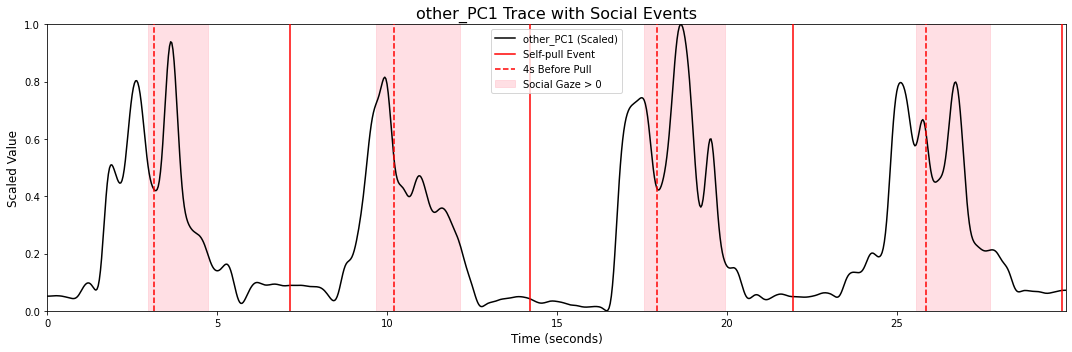

In [96]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

ind_selfpull_prob = np.isin(con_vars_plot, 'selfpull_prob')
ind_socialgaze_prob = np.isin(con_vars_plot, 'socialgaze_prob')
ind_otherPC1 = np.isin(con_vars_plot, 'other_PC1')

twin_ind_min = 440*30
twin_ind_max = 470*30


# --- Pull out the 1D data ---
trace_selfpull_prob = data_summary[np.where(ind_selfpull_prob)[0][0]][twin_ind_min:twin_ind_max]
trace_socialgaze_prob = data_summary[np.where(ind_socialgaze_prob)[0][0]][twin_ind_min:twin_ind_max]
trace_otherPC1 = data_summary[np.where(ind_otherPC1)[0][0]][twin_ind_min:twin_ind_max]

# --- Fix: Reshape each 1D array to 2D before scaling ---
trace_selfpull_prob = scaler.fit_transform(trace_selfpull_prob.reshape(-1, 1))
trace_socialgaze_prob = scaler.fit_transform(trace_socialgaze_prob.reshape(-1, 1))
trace_otherPC1 = scaler.fit_transform(trace_otherPC1.reshape(-1, 1))

#
# Create a time axis for a proper x-axis in seconds
n_samples_window = len(trace_otherPC1)
time_axis = np.arange(n_samples_window) / 30

### plot ###
# 1. Setup the figure and axis
fig, ax = plt.subplots(figsize=(15, 5))

# 2. (TASK 1) Plot the main other_PC1 trace
# We plot the new scaled variable
ax.plot(time_axis, trace_otherPC1, label='other_PC1 (Scaled)', color='black', zorder=2)

# 3. (TASK 3) Draw shaded pink area
# We use the *original* trace_socialgaze_prob for the 'where' condition
ax.fill_between(
    time_axis, 
    0,  # Fill from y=0
    1,  # Fill to y=1
    where=(trace_socialgaze_prob.flatten() > 0), # Condition uses original data
    color='pink', 
    alpha=0.5, 
    label='Social Gaze > 0',
    zorder=1 # Plot it behind the black line
)

# 4. (TASK 2) Draw vertical lines for self-pull
# We use the *original* trace_selfpull_prob to find the 1s
pull_indices = np.where(trace_selfpull_prob == 1)[0]
samples_4s = 4 * 30 # Calculate 4 seconds in samples

# Handle labels so they don't repeat in the legend
label_pull = 'Self-pull Event'
label_pre_pull = '4s Before Pull'

for idx in pull_indices:
    # Get the time (in seconds) of the event
    time_at_pull = time_axis[idx]
    
    # Draw the solid line at the event
    ax.axvline(
        x=time_at_pull, 
        color='red', 
        linestyle='-', 
        linewidth=1.5,
        label=label_pull,
        zorder=3 # Plot on top
    )
    
    # Calculate and draw the 4s-before dashed line
    pre_pull_idx = idx - samples_4s
    if pre_pull_idx >= 0: # Only plot if it's within the window
        time_pre_pull = time_axis[pre_pull_idx]
        ax.axvline(
            x=time_pre_pull, 
            color='red', 
            linestyle='--', 
            linewidth=1.5,
            label=label_pre_pull,
            zorder=3
        )
    
    # Set labels to None after the first loop to avoid duplicates
    label_pull = None
    label_pre_pull = None

# 5. Finalize plot
ax.set_title('other_PC1 Trace with Social Events', fontsize=16)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Scaled Value', fontsize=12)
ax.set_ylim(0, 1) # Force y-axis to be 0-1
ax.set_xlim(time_axis[0], time_axis[-1]) # Fit x-axis to data
ax.legend()
plt.tight_layout()

savefig = 1
if savefig:
    figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/" + \
                    cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/partnerPC1_example_fig/"

    if not os.path.exists(figsavefolder):
        os.makedirs(figsavefolder)

    plt.savefig(figsavefolder+animal1+animal2+'_'+date_tgt+'_partnerPC1_example_trace.pdf')

## Organize the data
### put all the target data together for further analysis
### also organize and save the data for the hddm analysis

In [ ]:

# choose one pull_trig_events type to work with
# options: ['gaze_other_angle','gaze_tube_angle','gaze_lever_angle','animal_animal_dist',
#           'animal_tube_dist','animal_lever_dist','othergaze_self_angle',
#           'mass_move_speed','gaze_angle_speed','otherani_otherlever_dist',
#           'socialgaze_prob','othergaze_prob']
#
# pull_trig_events_tgtname = 'otherani_otherlever_dist' 
pull_trig_events_tgtname = 'socialgaze_prob' # for testing if individual trial different was from gaze start time
# pull_trig_events_tgtname = 'othergaze_prob' # if to test things aligned to partner's pull (in that case, the subject's gaze becomes othergaze) 


# Keep these as additional controls
pull_trig_otherpull_name = 'otherpull_prob'
pull_trig_selfpull_name = 'selfpull_prob'
pull_trig_selfspeed_name = 'mass_move_speed'
pull_trig_otherspeed_name = 'other_mass_move_speed'
pull_trig_otherleverspeed_name = 'other_lever_speed'
pull_trig_selfPC1_name = 'self_PC1'
pull_trig_otherPC1_name = 'other_PC1'
pull_time_pre_reward_name = 'time_from_last_reward'
prefail_pull_num_name = 'num_preceding_failpull'
pull_rt_name = 'pull_rt'

#
animal_to_ana = 'dodson'
# animal_to_ana = 'kanga'

#
# conditions_to_ana = np.unique(task_conditions)
# conditions_to_ana = ['MC',]
# conditions_to_ana = ['SR']
# conditions_to_ana = ['MC_DannonAuto']
#
# for Kanga only
# conditions_to_ana = ['MC', 'MC_withDodson','MC_withGinger', 'MC_withKoala', 'MC_withVermelho',]
# conditions_to_ana = ['MC', 'MC_DannonAuto', 'MC_KangaAuto', 'MC_withDodson','MC_withGinger', 
#                      'MC_withKoala', 'MC_withVermelho', 'NV', ]
# conditions_to_ana = ['SR', 'SR_withDodson' ]
# conditions_to_ana = ['MC', 'MC_withDodson','MC_withGinger', 
#                      'MC_withKoala', 'MC_withVermelho', 'SR', 'SR_withDodson' ]
# 
# for dodson only
conditions_to_ana = ['MC', 'MC_withGingerNew', 'MC_withKanga', 'MC_withKoala',  ]
# conditions_to_ana = ['MC', 'MC_DodsonAuto_withKoala', 'MC_KoalaAuto_withKoala',
#                      'MC_withGingerNew', 'MC_withKanga', 'MC_withKoala',  ]
# conditions_to_ana = ['MC', 'MC_DodsonAuto_withKoala', 'MC_KoalaAuto_withKoala',
#                       'MC_withGingerNew', 'MC_withKanga', 'MC_withKoala',  ]
# conditions_to_ana = ['SR', 'SR_withGingerNew', 'SR_withKanga', 'SR_withKoala',  ]
# conditions_to_ana = ['MC', 
#               'MC_withGingerNew', 'MC_withKanga', 'MC_withKoala', 'SR', 'SR_withGingerNew', 'SR_withKanga',
#              'SR_withKoala',  ]

condition_name = 'allMC'
# condition_name = 'allSR'

bhvevents_aligned_FR_allevents_all_dates_df = pd.DataFrame(columns=['dates','condition','act_animal','bhv_name',
                                                                    'succrate','clusterID',
                                                                    'channelID','FR_ievent'])

try:

    # dummy 
    
    data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody_neural_and_hddm'+savefile_sufix+\
        '/'+cameraID+'/'+animal_to_ana+'/hddm_model_fitted_combinedsession_withNeurons/'

    if condition_name == 'allMC':
        with open(data_saved_subfolder+'/hddm_RawFullDatas_flexibleTW_newRTdefinition_'+doOnsetAfterMin_suffix+\
                  'withFRs_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
            bhvevents_aligned_FR_allevents_all_dates_df = pickle.load(f)
    else:
        with open(data_saved_subfolder+'/hddm_RawFullDatas_flexibleTW_newRTdefinition_'+doOnsetAfterMin_suffix+\
                  'withFRs_all_dates_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'_'+condition_name+'.pkl', 'rb') as f:
            bhvevents_aligned_FR_allevents_all_dates_df = pickle.load(f)

except:
    for idate in np.arange(0,ndates,1):
        date_tgt = dates_list[idate]
        task_condition = task_conditions[idate]
        
        # only analyze the targeted conditions
        if not np.isin(task_condition,conditions_to_ana):
            continue
    
        succrate = succ_rate_all_dates[idate]
        
        bhv_types = list(bhvevents_pullstartTopull_aligned_FR_allevents_all_dates[date_tgt].keys())
    
        for ibhv_type in bhv_types:
    
            clusterIDs = list(bhvevents_pullstartTopull_aligned_FR_allevents_all_dates[date_tgt][ibhv_type].keys())
    
            ibhv_type_split = ibhv_type.split()
            if np.shape(ibhv_type_split)[0]==3:
                ibhv_type_split[1] = ibhv_type_split[1]+'_'+ibhv_type_split[2]
    
            # only analyze targeted action animal
            if not np.isin(ibhv_type_split[0], animal_to_ana):
                continue
            
            
            # load the pull_trig_continuous_events
            try:
                pull_trig_events_tgt = pullstartTopull_trig_events_all_dates[date_tgt][(ibhv_type_split[0],pull_trig_events_tgtname)]
                pull_trig_otherpull = pullstartTopull_trig_events_all_dates[date_tgt][(ibhv_type_split[0],pull_trig_otherpull_name)]
                pull_trig_selfpull = pullstartTopull_trig_events_all_dates[date_tgt][(ibhv_type_split[0],pull_trig_selfpull_name)]
                pull_trig_selfspeed = pullstartTopull_trig_events_all_dates[date_tgt][(ibhv_type_split[0],pull_trig_selfspeed_name)]
                pull_trig_otherspeed = pullstartTopull_trig_events_all_dates[date_tgt][(ibhv_type_split[0],pull_trig_otherspeed_name)]
                pull_trig_selfPC1 = pullstartTopull_trig_events_all_dates[date_tgt][(ibhv_type_split[0],pull_trig_selfPC1_name)]
                pull_trig_otherPC1 = pullstartTopull_trig_events_all_dates[date_tgt][(ibhv_type_split[0],pull_trig_otherPC1_name)]
                
                #
                pull_trig_prerewardtime = np.array(list(pull_infos_all_dates[date_tgt][(ibhv_type_split[0],pull_time_pre_reward_name)]))
                prefail_pull_num = np.array(list(pull_infos_all_dates[date_tgt][(ibhv_type_split[0],prefail_pull_num_name)]))
                #
                pull_rt = np.array(list(pull_rts_all_dates[date_tgt][ibhv_type_split[0]]))
                #
                pull_outcome = np.hstack([1-(prefail_pull_num[1:]>0).astype(int),np.nan])
                
                # get the other animal's speed related to their lever
                pull_trig_otherleverdist = pullstartTopull_trig_events_all_dates[date_tgt][(ibhv_type_split[0],'otherani_otherlever_dist')]
                pull_trig_otherleverspeed = [(np.diff(trace)) for trace in pull_trig_otherleverdist]

                
            except:
                pull_trig_events_tgt = np.nan
                pull_trig_otherpull = np.nan
                pull_trig_selfpull = np.nan
                pull_trig_selfspeed = np.nan
                pull_trig_otherspeed = np.nan
                pull_trig_selfPC1 = np.nan
                pull_trig_otherPC1 = np.nan
                #
                pull_trig_prerewardtime = np.nan
                prefail_pull_num = np.nan
                pull_rt = np.nan
            
                
            for iclusterID in clusterIDs:   
    
                ichannelID = bhvevents_pullstartTopull_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['ch']
                iFR_allevents = bhvevents_pullstartTopull_aligned_FR_allevents_all_dates[date_tgt][ibhv_type][iclusterID]['FR_allevents']
    
                #
                nevents = np.shape([len(x) for x in pull_trig_events_tgt])[0]
                
                for ievent in np.arange(0,nevents,1):
                
                    bhvevents_aligned_FR_allevents_all_dates_df = bhvevents_aligned_FR_allevents_all_dates_df.append({'dates': date_tgt, 
                                                                                        'condition':task_condition,
                                                                                        'act_animal':ibhv_type_split[0],
                                                                                        'bhv_name': ibhv_type_split[1],
                                                                                        'bhv_id':ievent,
                                                                                        'succrate':succrate[0],
                                                                                        'clusterID':iclusterID,
                                                                                        'channelID':ichannelID,
                                                                                        'FR_ievent':iFR_allevents[ievent],
                                                                                         pull_trig_events_tgtname:pull_trig_events_tgt[ievent],                          
                                                                                         pull_trig_otherpull_name:pull_trig_otherpull[ievent],                          
                                                                                         pull_trig_selfpull_name:pull_trig_selfpull[ievent],
                                                                                         pull_trig_otherspeed_name:pull_trig_otherspeed[ievent],                          
                                                                                         pull_trig_selfspeed_name:pull_trig_selfspeed[ievent],
                                                                                         pull_trig_otherPC1_name:pull_trig_otherPC1[ievent],                          
                                                                                         pull_trig_selfPC1_name:pull_trig_selfPC1[ievent],
                                                                                                                      
                                                                                         pull_time_pre_reward_name:pull_trig_prerewardtime[ievent],
                                                                                         prefail_pull_num_name:prefail_pull_num[ievent],
                                                                                         pull_rt_name:pull_rt[ievent],
                                                                                             
                                                                                         pull_trig_otherleverspeed_name: pull_trig_otherleverspeed[ievent],                            
                                                                                         
                                                                                         'pull_outcome': pull_outcome[ievent],
                                                                                        }, ignore_index=True)
    
    
    # save the data with other HDDM dataframes for the modeling
    savedata = 1
    
    if savedata:
        data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody_neural_and_hddm'+savefile_sufix+\
            '/'+cameraID+'/'+animal_to_ana+'/hddm_model_fitted_combinedsession_withNeurons/'
        if not os.path.exists(data_saved_subfolder):
                os.makedirs(data_saved_subfolder)
        
        if condition_name == 'allMC':
            with open(data_saved_subfolder+'/hddm_RawFullDatas_flexibleTW_newRTdefinition_'+doOnsetAfterMin_suffix+'withFRs_all_dates_'+\
                      animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
                pickle.dump(bhvevents_aligned_FR_allevents_all_dates_df, f) 
        else:
            with open(data_saved_subfolder+'/hddm_RawFullDatas_flexibleTW_newRTdefinition_'+doOnsetAfterMin_suffix+'withFRs_all_dates_'+\
                      animal1_fixedorders[0]+animal2_fixedorders[0]+'_'+condition_name+'.pkl', 'wb') as f:
                pickle.dump(bhvevents_aligned_FR_allevents_all_dates_df, f) 

           
                

In [ ]:
# add a plot of the distribution of the reaction time

In [ ]:
# --- Your initial data preparation ---
from scipy.stats import mannwhitneyu

unique_columns = ['dates', 'condition', 'bhv_id']
unique_events_df = bhvevents_aligned_FR_allevents_all_dates_df.drop_duplicates(
    subset=unique_columns,
    keep='first'
)

pull_rt = np.array(unique_events_df['pull_rt'])
ind_succ = unique_events_df['pull_outcome'] > 0
ind_fail = unique_events_df['pull_outcome'] == 0
pull_rt_succ = np.array(unique_events_df[ind_succ]['pull_rt'])
pull_rt_fail = np.array(unique_events_df[ind_fail]['pull_rt'])



# --- 1a. Create a plotting function for a single distribution ---
def plot_single_distribution(ax, data, title, color):
    """
    Takes data and a matplotlib axis, removes outliers, plots a KDE distribution,
    and adds mean/std annotations.
    """
    if len(data) == 0:
        ax.set_title(f'{title}\n(No Data)', fontsize=16)
        return

    df = pd.DataFrame({'rt': data})

    # Outlier Removal using IQR
    Q1, Q3 = df['rt'].quantile(0.25), df['rt'].quantile(0.75)
    IQR = Q3 - Q1
    df_filtered = df[(df['rt'] >= Q1 - 1.5 * IQR) & (df['rt'] <= Q3 + 1.5 * IQR)]

    # Plotting the KDE
    seaborn.kdeplot(data=df_filtered, x='rt', fill=True, color=color, ax=ax)

    # Adding Mean and STD annotations
    mean_rt = df_filtered['rt'].mean()
    std_rt = df_filtered['rt'].std()
    stats_text = f"Mean: {mean_rt:.2f}\nStd Dev: {std_rt:.2f}"
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

    ax.set_title(title, fontsize=16)
    ax.set_xlabel('pull response time', fontsize=12)


# --- 1b. Create the consolidated plotting and testing function for comparison ---
def plot_and_compare_distributions(ax, data_succ, data_fail, title):
    """
    Plots two KDE distributions on the same axis, removes outliers from each,
    and performs a Mann-Whitney U test to compare them.
    """
    # Data Preparation and Outlier Removal
    if len(data_succ) == 0 or len(data_fail) == 0:
        ax.set_title(f'{title}\n(Not enough data for comparison)', fontsize=16)
        return

    df_succ = pd.DataFrame({'rt': data_succ})
    df_fail = pd.DataFrame({'rt': data_fail})

    Q1_succ, Q3_succ = df_succ['rt'].quantile(0.25), df_succ['rt'].quantile(0.75)
    IQR_succ = Q3_succ - Q1_succ
    succ_filtered = df_succ[(df_succ['rt'] >= Q1_succ - 1.5 * IQR_succ) & (df_succ['rt'] <= Q3_succ + 1.5 * IQR_succ)]['rt']

    Q1_fail, Q3_fail = df_fail['rt'].quantile(0.25), df_fail['rt'].quantile(0.75)
    IQR_fail = Q3_fail - Q1_fail
    fail_filtered = df_fail[(df_fail['rt'] >= Q1_fail - 1.5 * IQR_fail) & (df_fail['rt'] <= Q3_fail + 1.5 * IQR_fail)]['rt']

    # Plotting the two KDEs
    seaborn.kdeplot(data=succ_filtered, fill=True, color='mediumseagreen', label=f'Successful (n={len(succ_filtered)})', ax=ax)
    seaborn.kdeplot(data=fail_filtered, fill=True, color='lightcoral', label=f'Failed (n={len(fail_filtered)})', ax=ax)

    # Perform Mann-Whitney U Test
    u_statistic, p_value = mannwhitneyu(succ_filtered, fail_filtered, alternative='two-sided')

    # Add Statistical Annotations
    stats_text = (
        f"Mann-Whitney U Test:\n"
        f"U-statistic = {u_statistic:.1f}\n"
        f"p-value = {p_value:.2e}\n\n"
        f"{'Distributions are significantly different' if p_value < 0.05 else 'No significant difference'}"
    )
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))

    # Formatting
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('pull response time (s)', fontsize=12)
    ax.legend(loc='upper left')


# --- 2. Create the Figure with Two Subplots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True) # Changed to 2 plots
fig.suptitle('Distribution of pull response time (s)', fontsize=20, fontweight='bold')

# --- Panel 1: All Pulls ---
plot_single_distribution(axes[0], pull_rt, 'All Pulls', 'skyblue')
axes[0].set_ylabel('Density', fontsize=12)

# --- Panel 2: Successful vs. Failed Pulls ---
plot_and_compare_distributions(axes[1], pull_rt_succ, pull_rt_fail, 'Comparison of Pull Outcomes')


plt.tight_layout(rect=[0, 0, 1, 0.94]) # Adjust layout for suptitle


savefig = 1
if savefig:
    figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/" + \
                    cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/bhvvariables_summary_fig/"

    if not os.path.exists(figsavefolder):
        os.makedirs(figsavefolder)

    plt.savefig(figsavefolder + animal_to_ana + '_in_' + condition_name +
                '_pull_responseTime_distribution.pdf')
    
    

In [ ]:
np.min(pull_rt)

In [ ]:
# save the original dataframe for reference 
bhvevents_aligned_FR_allevents_all_dates_df_origin = bhvevents_aligned_FR_allevents_all_dates_df.copy()


In [ ]:
bhvevents_aligned_FR_allevents_all_dates_df.keys()

In [ ]:
# bhvevents_aligned_FR_allevents_all_dates_df = bhvevents_aligned_FR_allevents_all_dates_df_origin


In [ ]:
# add some new columns
bhvevents_aligned_FR_allevents_all_dates_df['previous_pull_outcome'] = (
        bhvevents_aligned_FR_allevents_all_dates_df['num_preceding_failpull'] == 0
    ).astype(int)

# Compute AUC for social gaze probability
# bhvevents_aligned_FR_allevents_all_dates_df['socialgaze_auc'] = bhvevents_aligned_FR_allevents_all_dates_df['socialgaze_prob'].apply(
#     lambda x: np.trapz(x) if isinstance(x, (list, np.ndarray)) else np.nan
# )
bhvevents_aligned_FR_allevents_all_dates_df['socialgaze_auc'] = bhvevents_aligned_FR_allevents_all_dates_df['socialgaze_prob'].apply(
    lambda x: np.nansum(x) if isinstance(x, (list, np.ndarray)) else np.nan
)
bhvevents_aligned_FR_allevents_all_dates_df['socialgaze_auc'] = \
bhvevents_aligned_FR_allevents_all_dates_df['socialgaze_auc']/bhvevents_aligned_FR_allevents_all_dates_df['pull_rt']

# Mean and STD for mass_move_speed
bhvevents_aligned_FR_allevents_all_dates_df['mass_move_speed_mean'] = bhvevents_aligned_FR_allevents_all_dates_df['mass_move_speed'].apply(
    lambda x: np.nanmean(x) if isinstance(x, (list, np.ndarray)) else np.nan
)
bhvevents_aligned_FR_allevents_all_dates_df['mass_move_speed_std'] = bhvevents_aligned_FR_allevents_all_dates_df['mass_move_speed'].apply(
    lambda x: np.nanstd(x) if isinstance(x, (list, np.ndarray)) else np.nan
)

# Mean and STD for self_PC1
bhvevents_aligned_FR_allevents_all_dates_df['self_PC1_mean'] = bhvevents_aligned_FR_allevents_all_dates_df['self_PC1'].apply(
    lambda x: np.nanmean(x) if isinstance(x, (list, np.ndarray)) else np.nan
)
bhvevents_aligned_FR_allevents_all_dates_df['self_PC1_std'] = bhvevents_aligned_FR_allevents_all_dates_df['self_PC1'].apply(
    lambda x: np.nanstd(x) if isinstance(x, (list, np.ndarray)) else np.nan
)

# Mean and STD for other_mass_move_speed
bhvevents_aligned_FR_allevents_all_dates_df['other_mass_move_speed_mean'] = bhvevents_aligned_FR_allevents_all_dates_df['other_mass_move_speed'].apply(
    lambda x: np.nanmean(x) if isinstance(x, (list, np.ndarray)) else np.nan
)
bhvevents_aligned_FR_allevents_all_dates_df['other_mass_move_speed_std'] = bhvevents_aligned_FR_allevents_all_dates_df['other_mass_move_speed'].apply(
    lambda x: np.nanstd(x) if isinstance(x, (list, np.ndarray)) else np.nan
)

# Mean and STD for other_lever_speed
bhvevents_aligned_FR_allevents_all_dates_df['other_lever_speed_mean'] = bhvevents_aligned_FR_allevents_all_dates_df['other_lever_speed'].apply(
    lambda x: np.nanmean(x) if isinstance(x, (list, np.ndarray)) else np.nan
)
bhvevents_aligned_FR_allevents_all_dates_df['other_lever_speed_std'] = bhvevents_aligned_FR_allevents_all_dates_df['other_lever_speed'].apply(
    lambda x: np.nanstd(x) if isinstance(x, (list, np.ndarray)) else np.nan
)

# Mean and STD for other_PC1
if 1:
# if not animal_to_ana == 'kanga_no':
    bhvevents_aligned_FR_allevents_all_dates_df['other_PC1_mean'] = bhvevents_aligned_FR_allevents_all_dates_df['other_PC1'].apply(
        lambda x: np.nanmean(x) if isinstance(x, (list, np.ndarray)) else np.nan
    )
    bhvevents_aligned_FR_allevents_all_dates_df['other_PC1_std'] = bhvevents_aligned_FR_allevents_all_dates_df['other_PC1'].apply(
        lambda x: np.nanstd(x) if isinstance(x, (list, np.ndarray)) else np.nan
    )
else: # use social gaze to filter the period 
    # Assuming 'bhvevents_aligned_FR_allevents_all_dates_df' is your DataFrame
    df = bhvevents_aligned_FR_allevents_all_dates_df

    # Define a function to calculate stats based on the condition
    def calculate_gated_stats(row):
        """
        Calculates mean and std of 'other_PC1' where 'socialgaze_prob' > 0.
        """
        pc1_trace = row['other_PC1']
        gaze_prob = row['socialgaze_prob']

        # Ensure both columns have valid list-like data
        if not isinstance(pc1_trace, (list, np.ndarray)) or not isinstance(gaze_prob, (list, np.ndarray)):
            return pd.Series([np.nan, np.nan])

        # Convert to numpy arrays for efficient filtering
        pc1_array = np.array(pc1_trace)
        gaze_array = np.array(gaze_prob)

        # Create a boolean mask for the condition
        gaze_mask = gaze_array > 0

        # If no time points meet the condition, return NaNs
        if not np.any(gaze_mask):
            return pd.Series([np.nan, np.nan])

        # Filter the PC1 data and calculate stats
        pc1_gated = pc1_array[gaze_mask]

        mean_val = np.nanmean(pc1_gated)
        std_val = np.nanstd(pc1_gated)

        return pd.Series([mean_val, std_val])
    
    # Apply the function across the rows (axis=1)
    # This creates two new columns with the results
    df[['other_PC1_mean', 'other_PC1_std']] = df.apply(calculate_gated_stats, axis=1)

# #  flip the other pc1 std as the way to define social evidence
# #  bhvevents_aligned_FR_allevents_all_dates_df['other_PC1_std'] = 1/bhvevents_aligned_FR_allevents_all_dates_df['other_PC1_std']
    
    
# firing rate mean and slope before pull (0.85s before)
from scipy.stats import linregress
from tqdm import tqdm

#
# Compute mean firing rate
bhvevents_aligned_FR_allevents_all_dates_df['fr_mean'] = bhvevents_aligned_FR_allevents_all_dates_df['FR_ievent'].apply(
    lambda x: np.nanmean(x) if isinstance(x, (list, np.ndarray)) else np.nan
)

# 
# Compute the slope, in two ways
#
# Make a clean copy to avoid SettingWithCopyWarning
df = bhvevents_aligned_FR_allevents_all_dates_df.copy()

# === Fixed slope before 0.85s from pull ===
pull_margin_frames = int(0.85 * fps)
# === Fixed slope after the minimal response time ===
min_rt_margin_frames = int(4.85 * fps)


def compute_fr_slope(fr_trace):
    if isinstance(fr_trace, (list, np.ndarray)) and len(fr_trace) > pull_margin_frames:
        y = fr_trace[:len(fr_trace) - pull_margin_frames]
        # y = fr_trace[len(fr_trace) - min_rt_margin_frames:len(fr_trace) - pull_margin_frames]
        x = np.arange(len(y))
        try:
            slope, *_ = linregress(x, y)
            return abs(slope)
        except:
            return np.nan
    return np.nan

df.loc[:, 'fr_slope'] = df['FR_ievent'].apply(compute_fr_slope)

# === Peak-based slope calculation: use shortest trial ===

# Prepare new columns for slopes and peak times
df['fr_slope_peakbased'] = np.nan
df['fr_peak_time'] = np.nan

# Group by neuron
grouped = df.groupby(['dates', 'clusterID'])

for (date, cluster_id), group in tqdm(grouped, desc="Processing neurons"):

    traces = group['FR_ievent'].dropna().tolist()
    if len(traces) < 2:
        continue

    # Align traces by pull (end), pad shorter trials with nan at the front
    min_len = min(len(trace) for trace in traces)
    aligned = [trace[-min_len:] if len(trace) >= min_len else
               np.pad(trace, (min_len - len(trace), 0), constant_values=np.nan)
               for trace in traces]

    stacked = np.stack(aligned)  # shape: (n_trials, min_len)
    mean_trace = np.nanmean(stacked, axis=0)

    # Compute slope of mean trace (full)
    x_full = np.arange(min_len)
    slope_full = linregress(x_full, mean_trace).slope

    # Find peak index based on slope sign
    if slope_full >= 0:
        peak_idx = np.nanargmax(mean_trace)
    else:
        peak_idx = np.nanargmin(mean_trace)

    # Convert peak index to peak time relative to pull (end-aligned)
    peak_time = (peak_idx - (min_len - 1)) / fps

    # Save peak_time for all trials of this neuron
    df.loc[(df['dates'] == date) & (df['clusterID'] == cluster_id), 'fr_peak_time'] = peak_time

    # For each trial, calculate slope from trial start to the peak index (if peak_idx within trial length)
    for idx, row in group.iterrows():
        fr_trace = row['FR_ievent']
        trial_len = len(fr_trace)
        
        # Align trial trace to end, pad front if needed
        if trial_len < min_len:
            padded_trace = np.pad(fr_trace, (min_len - trial_len, 0), constant_values=np.nan)
        else:
            padded_trace = fr_trace[-min_len:]

        # Make sure peak_idx is within trial length
        if peak_idx < len(padded_trace):
            y = padded_trace[:peak_idx+1]
            x = np.arange(len(y))
            if np.isnan(y).all() or len(y) < 2:
                slope = np.nan
            else:
                slope = linregress(x, y).slope
            # Optional: store absolute slope if you want
            slope = abs(slope) if not np.isnan(slope) else np.nan

            df.loc[idx, 'fr_slope_peakbased'] = slope
        else:
            df.loc[idx, 'fr_slope_peakbased'] = np.nan

# Save back to original dataframe
bhvevents_aligned_FR_allevents_all_dates_df['fr_slope_peakbased'] = df['fr_slope_peakbased']
bhvevents_aligned_FR_allevents_all_dates_df['fr_peak_time'] = df['fr_peak_time']
bhvevents_aligned_FR_allevents_all_dates_df['fr_slope'] = df['fr_slope']

In [ ]:
from scipy.stats import mannwhitneyu # Import the Mann-Whitney U test

# --- Your initial data preparation ---

unique_columns = ['dates', 'condition', 'bhv_id']
unique_events_df = bhvevents_aligned_FR_allevents_all_dates_df.drop_duplicates(
    subset=unique_columns,
    keep='first'
)

pull_rt = np.array(unique_events_df['socialgaze_auc'])
ind_succ = unique_events_df['pull_outcome'] > 0
ind_fail = unique_events_df['pull_outcome'] == 0
pull_rt_succ = np.array(unique_events_df[ind_succ]['socialgaze_auc'])
pull_rt_fail = np.array(unique_events_df[ind_fail]['socialgaze_auc'])


# --- 1a. Create a plotting function for a single distribution ---
def plot_single_distribution(ax, data, title, color):
    """
    Takes data and a matplotlib axis, removes outliers, plots a KDE distribution,
    and adds mean/std annotations.
    """
    if len(data) == 0:
        ax.set_title(f'{title}\n(No Data)', fontsize=16)
        return

    df = pd.DataFrame({'rt': data})

    # Outlier Removal using IQR
    Q1, Q3 = df['rt'].quantile(0.25), df['rt'].quantile(0.75)
    IQR = Q3 - Q1
    df_filtered = df[(df['rt'] >= Q1 - 1.5 * IQR) & (df['rt'] <= Q3 + 1.5 * IQR)]

    # Plotting the KDE
    seaborn.kdeplot(data=df_filtered, x='rt', fill=True, color=color, ax=ax)

    # Adding Mean and STD annotations
    mean_rt = df_filtered['rt'].mean()
    std_rt = df_filtered['rt'].std()
    stats_text = f"Mean: {mean_rt:.2f}\nStd Dev: {std_rt:.2f}"
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

    ax.set_title(title, fontsize=16)
    ax.set_xlabel('socialgaze_auc', fontsize=12)


# --- 1b. Create the consolidated plotting and testing function for comparison ---
def plot_and_compare_distributions(ax, data_succ, data_fail, title):
    """
    Plots two KDE distributions on the same axis, removes outliers from each,
    and performs a Mann-Whitney U test to compare them.
    """
    # Data Preparation and Outlier Removal
    if len(data_succ) == 0 or len(data_fail) == 0:
        ax.set_title(f'{title}\n(Not enough data for comparison)', fontsize=16)
        return

    df_succ = pd.DataFrame({'rt': data_succ})
    df_fail = pd.DataFrame({'rt': data_fail})

    Q1_succ, Q3_succ = df_succ['rt'].quantile(0.25), df_succ['rt'].quantile(0.75)
    IQR_succ = Q3_succ - Q1_succ
    succ_filtered = df_succ[(df_succ['rt'] >= Q1_succ - 1.5 * IQR_succ) & (df_succ['rt'] <= Q3_succ + 1.5 * IQR_succ)]['rt']

    Q1_fail, Q3_fail = df_fail['rt'].quantile(0.25), df_fail['rt'].quantile(0.75)
    IQR_fail = Q3_fail - Q1_fail
    fail_filtered = df_fail[(df_fail['rt'] >= Q1_fail - 1.5 * IQR_fail) & (df_fail['rt'] <= Q3_fail + 1.5 * IQR_fail)]['rt']

    # Plotting the two KDEs
    seaborn.kdeplot(data=succ_filtered, fill=True, color='mediumseagreen', label=f'Successful (n={len(succ_filtered)})', ax=ax)
    seaborn.kdeplot(data=fail_filtered, fill=True, color='lightcoral', label=f'Failed (n={len(fail_filtered)})', ax=ax)

    # Perform Mann-Whitney U Test
    u_statistic, p_value = mannwhitneyu(succ_filtered, fail_filtered, alternative='two-sided')

    # Add Statistical Annotations
    stats_text = (
        f"Mann-Whitney U Test:\n"
        f"U-statistic = {u_statistic:.1f}\n"
        f"p-value = {p_value:.2e}\n\n"
        f"{'Distributions are significantly different' if p_value < 0.05 else 'No significant difference'}"
    )
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))

    # Formatting
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('socialgaze_auc', fontsize=12)
    ax.legend(loc='upper left')


# --- 2. Create the Figure with Two Subplots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True) # Changed to 2 plots
fig.suptitle('Distribution of Social Gaze AUC', fontsize=20, fontweight='bold')

# --- Panel 1: All Pulls ---
plot_single_distribution(axes[0], pull_rt, 'All Pulls', 'skyblue')
axes[0].set_ylabel('Density', fontsize=12)

# --- Panel 2: Successful vs. Failed Pulls ---
plot_and_compare_distributions(axes[1], pull_rt_succ, pull_rt_fail, 'Comparison of Pull Outcomes')


plt.tight_layout(rect=[0, 0, 1, 0.94]) # Adjust layout for suptitle


savefig = 0
if savefig:
    figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/" + \
                    cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/bhvvariables_summary_fig/"

    if not os.path.exists(figsavefolder):
        os.makedirs(figsavefolder)

    plt.savefig(figsavefolder + animal_to_ana + '_in_' + condition_name +
                '_socialgaze_auc_distribution.pdf')
    
    

In [ ]:
from scipy.stats import mannwhitneyu # Import the Mann-Whitney U test

# --- Your initial data preparation ---

unique_columns = ['dates', 'condition', 'bhv_id']
unique_events_df = bhvevents_aligned_FR_allevents_all_dates_df.drop_duplicates(
    subset=unique_columns,
    keep='first'
)

pull_rt = np.array(unique_events_df['other_PC1_std'])
ind_succ = unique_events_df['pull_outcome'] > 0
ind_fail = unique_events_df['pull_outcome'] == 0
pull_rt_succ = np.array(unique_events_df[ind_succ]['other_PC1_std'])
pull_rt_fail = np.array(unique_events_df[ind_fail]['other_PC1_std'])


# --- 1a. Create a plotting function for a single distribution ---
def plot_single_distribution(ax, data, title, color):
    """
    Takes data and a matplotlib axis, removes outliers, plots a KDE distribution,
    and adds mean/std annotations.
    """
    if len(data) == 0:
        ax.set_title(f'{title}\n(No Data)', fontsize=16)
        return

    df = pd.DataFrame({'rt': data})

    # Outlier Removal using IQR
    Q1, Q3 = df['rt'].quantile(0.25), df['rt'].quantile(0.75)
    IQR = Q3 - Q1
    df_filtered = df[(df['rt'] >= Q1 - 1.5 * IQR) & (df['rt'] <= Q3 + 1.5 * IQR)]

    # Plotting the KDE
    seaborn.kdeplot(data=df_filtered, x='rt', fill=True, color=color, ax=ax)

    # Adding Mean and STD annotations
    mean_rt = df_filtered['rt'].mean()
    std_rt = df_filtered['rt'].std()
    stats_text = f"Mean: {mean_rt:.2f}\nStd Dev: {std_rt:.2f}"
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

    ax.set_title(title, fontsize=16)
    ax.set_xlabel('other_PC1_std', fontsize=12)


# --- 1b. Create the consolidated plotting and testing function for comparison ---
def plot_and_compare_distributions(ax, data_succ, data_fail, title):
    """
    Plots two KDE distributions on the same axis, removes outliers from each,
    and performs a Mann-Whitney U test to compare them.
    """
    # Data Preparation and Outlier Removal
    if len(data_succ) == 0 or len(data_fail) == 0:
        ax.set_title(f'{title}\n(Not enough data for comparison)', fontsize=16)
        return

    df_succ = pd.DataFrame({'rt': data_succ})
    df_fail = pd.DataFrame({'rt': data_fail})

    Q1_succ, Q3_succ = df_succ['rt'].quantile(0.25), df_succ['rt'].quantile(0.75)
    IQR_succ = Q3_succ - Q1_succ
    succ_filtered = df_succ[(df_succ['rt'] >= Q1_succ - 1.5 * IQR_succ) & (df_succ['rt'] <= Q3_succ + 1.5 * IQR_succ)]['rt']

    Q1_fail, Q3_fail = df_fail['rt'].quantile(0.25), df_fail['rt'].quantile(0.75)
    IQR_fail = Q3_fail - Q1_fail
    fail_filtered = df_fail[(df_fail['rt'] >= Q1_fail - 1.5 * IQR_fail) & (df_fail['rt'] <= Q3_fail + 1.5 * IQR_fail)]['rt']

    # Plotting the two KDEs
    seaborn.kdeplot(data=succ_filtered, fill=True, color='mediumseagreen', label=f'Successful (n={len(succ_filtered)})', ax=ax)
    seaborn.kdeplot(data=fail_filtered, fill=True, color='lightcoral', label=f'Failed (n={len(fail_filtered)})', ax=ax)

    # Perform Mann-Whitney U Test
    u_statistic, p_value = mannwhitneyu(succ_filtered, fail_filtered, alternative='two-sided')

    # Add Statistical Annotations
    stats_text = (
        f"Mann-Whitney U Test:\n"
        f"U-statistic = {u_statistic:.1f}\n"
        f"p-value = {p_value:.2e}\n\n"
        f"{'Distributions are significantly different' if p_value < 0.05 else 'No significant difference'}"
    )
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))

    # Formatting
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('other_PC1_std', fontsize=12)
    ax.legend(loc='upper left')


# --- 2. Create the Figure with Two Subplots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True) # Changed to 2 plots
fig.suptitle('Distribution of other_PC1_std', fontsize=20, fontweight='bold')

# --- Panel 1: All Pulls ---
plot_single_distribution(axes[0], pull_rt, 'All Pulls', 'skyblue')
axes[0].set_ylabel('Density', fontsize=12)

# --- Panel 2: Successful vs. Failed Pulls ---
plot_and_compare_distributions(axes[1], pull_rt_succ, pull_rt_fail, 'Comparison of Pull Outcomes')


plt.tight_layout(rect=[0, 0, 1, 0.94]) # Adjust layout for suptitle


savefig = 0
if savefig:
    figsavefolder = data_saved_folder + "fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/" + \
                    cameraID + "/" + animal1_filenames[0] + "_" + animal2_filenames[0] + "/bhvvariables_summary_fig/"

    if not os.path.exists(figsavefolder):
        os.makedirs(figsavefolder)

    plt.savefig(figsavefolder + animal_to_ana + '_in_' + condition_name +
                '_partner_PC1_std_distribution.pdf')
    
    

In [ ]:
xxx = bhvevents_aligned_FR_allevents_all_dates_df['fr_slope']
yyy = bhvevents_aligned_FR_allevents_all_dates_df['fr_slope_peakbased']
# plt.plot(xxx,yyy,'.')

In [ ]:
##########
# organize the data in order to do HDDM - average across neurons for the unique trial
##########

# Step 1: Group by unique trial (date, bhv_id) and average the FR_ievent across neurons
averaged_df = bhvevents_aligned_FR_allevents_all_dates_df.groupby(['dates', 'bhv_id'])['FR_ievent'].apply(
    lambda traces: np.mean(np.stack(traces.to_numpy()), axis=0)
).reset_index()

# Step 2: Rename the averaged firing rate column
averaged_df = averaged_df.rename(columns={'FR_ievent': 'FR_ievent_avg'})

# Step 3: Select representative behavioral columns to merge back (drop duplicates so one per trial)
representative_cols = [
    'dates', 'condition', 'act_animal', 'bhv_name', 'succrate', 'bhv_id', 'mass_move_speed',
       'num_preceding_failpull', 'other_mass_move_speed', 'otherpull_prob',
       'pull_rt', 'selfpull_prob', 'socialgaze_prob', 'time_from_last_reward',
       'previous_pull_outcome', 'pull_outcome', 'socialgaze_auc', 'mass_move_speed_mean',
       'mass_move_speed_std', 'other_mass_move_speed_mean',
       'other_mass_move_speed_std','self_PC1_mean','self_PC1_std',
       'other_PC1_mean', 'other_PC1_std', 'other_PC1','self_PC1',
       'other_lever_speed_mean',
       'other_lever_speed_std',
       'other_lever_speed',
]

# Get one row per (dates, bhv_id) combination
behavior_df = bhvevents_aligned_FR_allevents_all_dates_df.drop_duplicates(subset=['dates', 'bhv_id'])[representative_cols]

# Step 4: Merge firing rate and behavioral data
bhvevents_aligned_FR_allevents_alldates_mergedneurons_df = pd.merge(averaged_df, behavior_df, 
                                                                    on=['dates', 'bhv_id'], how='left')

# Step 5
# Compute mean firing rate
bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['fr_mean'] = \
      bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['FR_ievent_avg'].apply(
    lambda x: np.mean(x) if isinstance(x, (list, np.ndarray)) else np.nan
)

# === Fixed slope before 0.85s from pull ===
pull_margin_frames = int(0.85 * fps)
# === Fixed slope after the minimal response time ===
min_rt_margin_frames = int(4.85 * fps)

# Compute slope of firing rate before 0.85s prior to pull
def compute_fr_slope(fr_trace):
    if isinstance(fr_trace, (list, np.ndarray)) and len(fr_trace) > pull_margin_frames:
        y = fr_trace[:len(fr_trace) - pull_margin_frames]
        # y = fr_trace[len(fr_trace) - min_rt_margin_frames:len(fr_trace) - pull_margin_frames]
        x = np.arange(len(y))
        try:
            slope, *_ = linregress(x, y)
            return abs(slope)
        except:
            return np.nan
    return np.nan

bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['fr_slope'] = \
     bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['FR_ievent_avg'].apply(compute_fr_slope)


# save the data with other HDDM dataframes for the modeling
savedata = 0

if savedata:
    data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody_neural_and_hddm'+savefile_sufix+\
        '/'+cameraID+'/'+animal_to_ana+'/hddm_model_fitted_combinedsession_withNeurons/'
    if not os.path.exists(data_saved_subfolder):
            os.makedirs(data_saved_subfolder)
    
    if condition_name == 'allMC':
        with open(data_saved_subfolder+'/hddm_datas_flexibleTW_newRTdefinition_'+doOnsetAfterMin_suffix+'withFRs_all_dates_'+
                  animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'wb') as f:
            pickle.dump(bhvevents_aligned_FR_allevents_alldates_mergedneurons_df, f) 
    else:
        with open(data_saved_subfolder+'/hddm_datas_flexibleTW_newRTdefinition_'+doOnsetAfterMin_suffix+'withFRs_all_dates_'+
                  animal1_fixedorders[0]+animal2_fixedorders[0]+'_'+condition_name+'.pkl', 'wb') as f:
            pickle.dump(bhvevents_aligned_FR_allevents_alldates_mergedneurons_df, f) 


In [ ]:
##########
# load the HDDM data to get the drift diffusion v for further correlation
##########

if 0:
    
    data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody_neural_and_hddm'+savefile_sufix+\
        '/'+cameraID+'/'+animal_to_ana+'/hddm_model_fitted_combinedsession_withNeurons/'

    with open(data_saved_subfolder+'/hddm_model_fitted_traces_'+condition_name+doOnsetAfterMin_suffix+'.pkl', 'rb') as f:
        hddm_model_fitted_traces = pickle.load(f)
    with open(data_saved_subfolder+'/hddm_model_fitted_stats_'+condition_name+doOnsetAfterMin_suffix+'.pkl', 'rb') as f:
        hddm_model_fitted_stats = pickle.load(f)
    with open(data_saved_subfolder+'/hddm_model_fitted_nogaze_traces_'+condition_name+doOnsetAfterMin_suffix+'.pkl', 'rb') as f:
        hddm_model_fitted_nogaze_traces = pickle.load(f)
    with open(data_saved_subfolder+'/hddm_model_fitted_nogaze_stats_'+condition_name+doOnsetAfterMin_suffix+'.pkl', 'rb') as f:
        hddm_model_fitted_nogaze_stats = pickle.load(f)
    
    v_inter = hddm_model_fitted_stats['mean']['v_Intercept']
    v_self_gaze_auc = hddm_model_fitted_stats['mean']['v_self_gaze_auc']
    v_partner_mean_speed = hddm_model_fitted_stats['mean']['v_partner_mean_speed']
    v_self_mean_speed = hddm_model_fitted_stats['mean']['v_self_mean_speed']
    v_partner_speed_std = hddm_model_fitted_stats['mean']['v_partner_speed_std']
    v_self_speed_std = hddm_model_fitted_stats['mean']['v_self_speed_std']

    #
    bhvevents_aligned_FR_allevents_all_dates_df['predicted_v'] = v_inter + \
            bhvevents_aligned_FR_allevents_all_dates_df['socialgaze_auc'] * v_self_gaze_auc + \
            bhvevents_aligned_FR_allevents_all_dates_df['other_mass_move_speed_mean'] * v_partner_mean_speed + \
            bhvevents_aligned_FR_allevents_all_dates_df['other_mass_move_speed_std'] * v_partner_speed_std + \
            bhvevents_aligned_FR_allevents_all_dates_df['mass_move_speed_mean'] * v_self_mean_speed + \
            bhvevents_aligned_FR_allevents_all_dates_df['mass_move_speed_std'] * v_self_speed_std 

    #
    bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['predicted_v'] = v_inter + \
            bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['socialgaze_auc'] * v_self_gaze_auc + \
            bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['other_mass_move_speed_mean'] * v_partner_mean_speed + \
            bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['other_mass_move_speed_std'] * v_partner_speed_std + \
            bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['mass_move_speed_mean'] * v_self_mean_speed + \
            bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['mass_move_speed_std'] * v_self_speed_std 




In [ ]:
# add some criteria to remove trials
# bhvevents_aligned_FR_allevents_all_dates_df = bhvevents_aligned_FR_allevents_all_dates_df[\
#                                 bhvevents_aligned_FR_allevents_all_dates_df['previous_pull_outcome']==1]

# bhvevents_aligned_FR_allevents_all_dates_df = bhvevents_aligned_FR_allevents_all_dates_df[\
#                                 bhvevents_aligned_FR_allevents_all_dates_df['pull_rt']>3]
# bhvevents_aligned_FR_allevents_all_dates_df = bhvevents_aligned_FR_allevents_all_dates_df[\
#                                 bhvevents_aligned_FR_allevents_all_dates_df['pull_rt']<20]

# Remove outlier pull_rt values
# method 1
if 0:
    # Compute IQR bounds
    bhv_unique_df = bhvevents_aligned_FR_allevents_all_dates_df.drop_duplicates(subset=['dates', 'bhv_id'])
    #
    q1 = bhv_unique_df['pull_rt'].quantile(0.25)
    q3 = bhv_unique_df['pull_rt'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    #
    # Filter out outliers
    bhvevents_aligned_FR_allevents_all_dates_df = bhvevents_aligned_FR_allevents_all_dates_df[
        (bhvevents_aligned_FR_allevents_all_dates_df['pull_rt'] >= lower_bound) &
        (bhvevents_aligned_FR_allevents_all_dates_df['pull_rt'] <= upper_bound)
    ]
# method 2    
if 1:
    # Symmetrical trimming: keep central 90% of pull_rt
    bhv_unique_df = bhvevents_aligned_FR_allevents_all_dates_df.drop_duplicates(subset=['dates', 'bhv_id'])
    #
    lower_bound = bhv_unique_df['pull_rt'].quantile(0.05)
    # lower_bound = 4
    upper_bound = bhv_unique_df['pull_rt'].quantile(0.95)

    # Filter the dataframe
    bhvevents_aligned_FR_allevents_all_dates_df = bhvevents_aligned_FR_allevents_all_dates_df[
        (bhvevents_aligned_FR_allevents_all_dates_df['pull_rt'] >= lower_bound) &
        (bhvevents_aligned_FR_allevents_all_dates_df['pull_rt'] <= upper_bound)
    ]
    
print(lower_bound)
print(upper_bound)

In [ ]:
# only look at the successful pull
if 0:
    ind_ = bhvevents_aligned_FR_allevents_all_dates_df['pull_outcome']==1
    bhvevents_aligned_FR_allevents_all_dates_df = bhvevents_aligned_FR_allevents_all_dates_df[ind_]

In [ ]:
xxx = bhvevents_aligned_FR_allevents_all_dates_df['pull_rt']
yyy = bhvevents_aligned_FR_allevents_all_dates_df['socialgaze_auc']
plt.plot(xxx,yyy,'.')
st.pearsonr(xxx,yyy)

In [ ]:
bhvevents_aligned_FR_allevents_all_dates_df.keys()

In [ ]:
# bhvevents_aligned_FR_allevents_all_dates_df
print(np.sum(bhvevents_aligned_FR_allevents_all_dates_df['pull_outcome']))
print(np.shape(bhvevents_aligned_FR_allevents_all_dates_df['pull_outcome'])[0])

In [ ]:
# do the same clearup for the merged dataframe
# Remove outlier pull_rt values
# method 1
if 0:
    # Compute IQR bounds
    bhv_unique_df = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df.drop_duplicates(subset=['dates', 'bhv_id'])
    #
    q1 = bhv_unique_df['pull_rt'].quantile(0.25)
    q3 = bhv_unique_df['pull_rt'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    #
    # Filter out outliers
    bhvevents_aligned_FR_allevents_alldates_mergedneurons_df = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df[
        (bhvevents_aligned_FR_allevents_all_dates_df['pull_rt'] >= lower_bound) &
        (bhvevents_aligned_FR_allevents_all_dates_df['pull_rt'] <= upper_bound)
    ]
# method 2    
if 1:
    # Symmetrical trimming: keep central 90% of pull_rt
    bhv_unique_df = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df.drop_duplicates(subset=['dates', 'bhv_id'])
    #
    lower_bound = bhv_unique_df['pull_rt'].quantile(0.05)
    # lower_bound = 4
    upper_bound = bhv_unique_df['pull_rt'].quantile(0.95)

    # Filter the dataframe
    bhvevents_aligned_FR_allevents_alldates_mergedneurons_df = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df[
        (bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['pull_rt'] >= lower_bound) &
        (bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['pull_rt'] <= upper_bound)
    ]
    
print(lower_bound)
print(upper_bound)

In [ ]:
# only look at the successful pull
if 0:
    ind_ = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['pull_outcome']==1
    bhvevents_aligned_FR_allevents_alldates_mergedneurons_df = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df[ind_]

In [ ]:
ind_ = 1749
if 0:
    plt.plot(bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['FR_ievent_avg'].loc[ind_])
    plt.plot(bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['mass_move_speed'].loc[ind_]/800)
    plt.plot(bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['other_mass_move_speed'].loc[ind_]/800)
    plt.plot(bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['socialgaze_prob'].loc[ind_]*5)
if 0:
    plt.plot(bhvevents_aligned_FR_allevents_all_dates_df['FR_ievent'].loc[ind_])
    plt.plot(bhvevents_aligned_FR_allevents_all_dates_df['mass_move_speed'].loc[ind_]/800)
    plt.plot(bhvevents_aligned_FR_allevents_all_dates_df['other_mass_move_speed'].loc[ind_]/800)
    plt.plot(bhvevents_aligned_FR_allevents_all_dates_df['socialgaze_prob'].loc[ind_]*5)


In [ ]:
# count neuron number of each session
dates_list = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['dates'])
for date_ in dates_list:
    
    ind_ = bhvevents_aligned_FR_allevents_all_dates_df['dates'] == date_
    neurons_ = np.unique(bhvevents_aligned_FR_allevents_all_dates_df[ind_]['clusterID'])
    conditions = np.unique(bhvevents_aligned_FR_allevents_all_dates_df[ind_]['condition'])
    succrates = np.unique(bhvevents_aligned_FR_allevents_all_dates_df[ind_]['succrate'])[0]
    
    nneurons = np.shape(neurons_)[0]
    
    print(date_ + ' ' +conditions+' '+str(nneurons)+' succrate:'+str(succrates))
    
    

In [ ]:
bhvevents_aligned_FR_allevents_all_dates_df

#### trial wise correlation between FR trace and other continuous variables

In [ ]:
if 0:
    from sklearn.linear_model import LinearRegression
    from sklearn.preprocessing import StandardScaler
    from scipy.stats import f_oneway, ttest_rel
    import itertools
    
    nentries = len(bhvevents_aligned_FR_allevents_alldates_mergedneurons_df)
    df = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df.copy()
    
    # ---------- Step 2: Regression calculations ----------
    r2_uni = {var: [] for var in ['mass', 'partner', 'selfpull', 'socialgaze']}
    r2_full = []
    delta_r2 = {var: [] for var in ['mass', 'partner', 'selfpull', 'socialgaze']}
    betas = {var: [] for var in ['mass', 'partner', 'selfpull', 'socialgaze']}
    
    for i in range(len(df)):
        y = df.iloc[i]['FR_ievent_avg']
        X_vars = {
            'mass': df.iloc[i]['mass_move_speed'],
            'partner': df.iloc[i]['other_mass_move_speed'],
            'selfpull': df.iloc[i]['selfpull_prob'],
            'socialgaze': df.iloc[i]['socialgaze_prob']
        }
    
        if any(len(y) != len(x) for x in X_vars.values()):
            continue
    
        try:
            # Univariate regressions
            for varname, x in X_vars.items():
                model_uni = LinearRegression().fit(np.array(x).reshape(-1, 1), y)
                r2_uni[varname].append(model_uni.score(np.array(x).reshape(-1, 1), y))
            
            # Full multivariate regression
            X_full = np.vstack([X_vars[v] for v in ['mass', 'partner', 'selfpull', 'socialgaze']]).T
            X_std = StandardScaler().fit_transform(X_full)
            y_std = (y - np.mean(y)) / np.std(y)
            model_full = LinearRegression().fit(X_std, y_std)
            r2_full_val = model_full.score(X_std, y_std)
            r2_full.append(r2_full_val)
    
            for idx, var in enumerate(['mass', 'partner', 'selfpull', 'socialgaze']):
                betas[var].append(model_full.coef_[idx])
    
            # Leave-one-out regressions
            for idx, var in enumerate(['mass', 'partner', 'selfpull', 'socialgaze']):
                X_reduced = np.delete(X_full, idx, axis=1)
                X_reduced_std = StandardScaler().fit_transform(X_reduced)
                model_reduced = LinearRegression().fit(X_reduced_std, y_std)
                r2_reduced = model_reduced.score(X_reduced_std, y_std)
                delta_r2[var].append(r2_full_val - r2_reduced)
    
        except:
            continue
    
    # ---------- Step 3: Format for plotting ----------
    df_r2_uni = pd.DataFrame([
        {'Variable': var, 'R2': r2} for var, values in r2_uni.items() for r2 in values
    ])
    
    df_delta_r2 = pd.DataFrame([
        {'Variable': var, 'Delta_R2': delta} for var, values in delta_r2.items() for delta in values
    ])
    
    df_betas = pd.DataFrame([
        {'Variable': var, 'Beta': beta} for var, values in betas.items() for beta in values
    ])
    
    # ---------- Step 4: Statistical tests ----------
    anova_r2 = f_oneway(*[df_r2_uni[df_r2_uni['Variable'] == v]['R2'] for v in df_r2_uni['Variable'].unique()])
    anova_delta = f_oneway(*[df_delta_r2[df_delta_r2['Variable'] == v]['Delta_R2'] for v in df_delta_r2['Variable'].unique()])
    anova_beta = f_oneway(*[df_betas[df_betas['Variable'] == v]['Beta'] for v in df_betas['Variable'].unique()])
    
    pairwise_results = []
    variables = ['mass', 'partner', 'selfpull', 'socialgaze']
    for v1, v2 in itertools.combinations(variables, 2):
        x = df_delta_r2[df_delta_r2['Variable'] == v1]['Delta_R2'].dropna()
        y = df_delta_r2[df_delta_r2['Variable'] == v2]['Delta_R2'].dropna()
        min_len = min(len(x), len(y))
        t_stat, p_val = ttest_rel(x[:min_len], y[:min_len])
        pairwise_results.append({'Var1': v1, 'Var2': v2, 'T-stat': t_stat, 'P-value': p_val})
    pairwise_df = pd.DataFrame(pairwise_results)
    
    # ---------- Step 5: Plotting ----------
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    sns.violinplot(data=df_r2_uni, x='Variable', y='R2', inner='box', ax=axes[0])
    axes[0].set_title('Univariate R² per Variable')
    
    sns.violinplot(data=df_delta_r2, x='Variable', y='Delta_R2',  inner='box', ax=axes[1])
    axes[1].set_title('ΔR² (Unique Contribution) per Variable')
    
    sns.violinplot(data=df_betas, x='Variable', y='Beta', inner='box', ax=axes[2])
    axes[2].set_title('Standardized Beta Coefficients')
    
    plt.tight_layout()
    # plt.savefig("regression_violin_plots.png")
    plt.show()
    
    # ---------- Optional: Print stats ----------
    print("ANOVA R²:", anova_r2)
    print("ANOVA ΔR²:", anova_delta)
    print("ANOVA Betas:", anova_beta)
    print("Pairwise ΔR² comparisons:\n", pairwise_df)

In [ ]:
if 0:
    # test if the mean FR across neurons in each trial is just tracking the self movement, 
    # or after considering the confound of self movement, it still encode social gaze
    
    # nentries = len(bhvevents_aligned_FR_allevents_alldates_mergedneurons_df)
    # df = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df.copy()
    
    nentries = len(bhvevents_aligned_FR_allevents_all_dates_df)
    df = bhvevents_aligned_FR_allevents_all_dates_df.copy()
    
    # ---------- Step 2: Regression calculations ----------
    r2_uni = {var: [] for var in ['mass', 'socialgaze']}
    r2_full = []
    delta_r2 = {var: [] for var in ['mass', 'socialgaze']}
    betas = {var: [] for var in ['mass',  'socialgaze']}
    
    for i in range(len(df)):
        # y = df.iloc[i]['FR_ievent_avg']
        y = df.iloc[i]['FR_ievent']
        X_vars = {
            'mass': df.iloc[i]['mass_move_speed'],
            'socialgaze': df.iloc[i]['socialgaze_prob']
        }
        
        try:
            # Full multivariate regression
            X_full = np.vstack([X_vars[v] for v in ['mass', 'socialgaze']]).T
            X_std = StandardScaler().fit_transform(X_full)
            y_std = (y - np.mean(y)) / np.std(y)
            model_full = LinearRegression().fit(X_std, y_std)
            r2_full_val = model_full.score(X_std, y_std)
            r2_full.append(r2_full_val)
        
            for idx, var in enumerate(['mass', 'socialgaze']):
                betas[var].append(model_full.coef_[idx])
    
        except:
            continue
        

In [ ]:
if 0:
    # test if the social gaze prob in each trial is just tracking the self movement, 
    # or after considering the confound of self movement, it still encode parnter movement
    
    nentries = len(bhvevents_aligned_FR_allevents_alldates_mergedneurons_df)
    df = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df.copy()
    

    # ---------- Step 2: Regression calculations ----------
    r2_uni = {var: [] for var in ['mass', 'partner']}
    r2_full = []
    delta_r2 = {var: [] for var in ['mass', 'partner']}
    betas = {var: [] for var in ['mass',  'partner']}
    
    for i in range(len(df)):
        y = df.iloc[i]['socialgaze_prob']
        X_vars = {
            'mass': df.iloc[i]['mass_move_speed'],
            'partner': df.iloc[i]['other_mass_move_speed']
        }
        
        try:
            # Full multivariate regression
            X_full = np.vstack([X_vars[v] for v in ['mass', 'partner']]).T
            X_std = StandardScaler().fit_transform(X_full)
            y_std = (y - np.mean(y)) / np.std(y)
            model_full = LinearRegression().fit(X_std, y_std)
            r2_full_val = model_full.score(X_std, y_std)
            r2_full.append(r2_full_val)
        
            for idx, var in enumerate(['mass', 'partner']):
                betas[var].append(model_full.coef_[idx])
    
        except:
            continue
        

### Use multi-variable regression to define and label neurons that encode socialgaze, even after control the self movement

In [ ]:
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway, ttest_rel
import itertools
import statsmodels.api as sm


warnings.filterwarnings("ignore", category=FutureWarning)

#
dates_toana = np.unique(bhvevents_aligned_FR_allevents_all_dates_df['dates'])
ndates_toana = np.shape(dates_toana)[0]

neuronEncodeSocialGaze_summary_df = pd.DataFrame(columns=['date','clusterID','neuronEncodeSocialGaze'])

for idate in np.arange(0, ndates_toana,1):
    date_toana = dates_toana[idate]

    ind_idate = np.isin(bhvevents_aligned_FR_allevents_all_dates_df['dates'],date_toana)

    df_allneurons_tgt = bhvevents_aligned_FR_allevents_all_dates_df[ind_idate]

    neurons_toana = np.unique(df_allneurons_tgt['clusterID'])
    nneurons_toana = np.shape(neurons_toana)[0]

    for ineuron in np.arange(0,nneurons_toana,1):
        neuron_toana = neurons_toana[ineuron]

        ind_ineuron = np.isin(df_allneurons_tgt['clusterID'],neuron_toana)

        df_ineuron_tgt = df_allneurons_tgt[ind_ineuron]

        # get the FR traces
        FR_allevents = np.array(df_ineuron_tgt['FR_ievent'])
        nFR_allevents = np.shape(FR_allevents)[0]

        # get the socialgaze and self movement traces
        selfspeed_allevents = np.array(df_ineuron_tgt['mass_move_speed'])
        socialgaze_allevents = np.array(df_ineuron_tgt['socialgaze_prob'])
        nbhv_allevents = np.shape(selfspeed_allevents)[0]

        # make sure the fr and bhv traces has the same size
        if nFR_allevents < nbhv_allevents:
            selfspeed_allevents = selfspeed_allevents[0:nFR_allevents]
            socialgaze_allevents = socialgaze_allevents[0:nFR_allevents]
            nevents = nFR_allevents
        elif nFR_allevents > nbhv_allevents:
            FR_allevents = FR_allevents[0:nbhv_allevents]
            nevents = nbhv_allevents
        else:
            nevents = nFR_allevents

        # remove trial that does not match
        for ievent in np.arange(0,nevents,1):
            ntimepoint_FR = np.shape(FR_allevents[ievent])[0]
            ntimepoint_speed = np.shape(selfspeed_allevents[ievent])[0]
            ntimepoint_gaze = np.shape(socialgaze_allevents[ievent])[0]
            
            if (ntimepoint_speed != ntimepoint_FR) |\
               (ntimepoint_gaze != ntimepoint_FR) |\
               (ntimepoint_gaze != ntimepoint_speed):
                FR_allevents[ievent] = []
                selfspeed_allevents[ievent] = []
                socialgaze_allevents[ievent] = []
        
        # conbine all trials
        FR_allevents_flat = np.concatenate(FR_allevents)
        selfspeed_allevents_flat = np.concatenate(selfspeed_allevents)
        socialgaze_allevents_flat = np.concatenate(socialgaze_allevents)
        #
        min_len = np.min([len(FR_allevents_flat),
                          len(selfspeed_allevents_flat),
                          len(socialgaze_allevents_flat)])
        FR_allevents_flat = FR_allevents_flat[0:min_len]
        selfspeed_allevents_flat = selfspeed_allevents_flat[0:min_len]
        socialgaze_allevents_flat = socialgaze_allevents_flat[0:min_len]
        
        # multi variable regression
        y = FR_allevents_flat
        X_vars = {
            'mass': selfspeed_allevents_flat,
            'socialgaze': socialgaze_allevents_flat
        }

        # Full multivariate regression
        try:
            X_full = np.vstack([X_vars[v] for v in ['mass', 'socialgaze']]).T
            X_std = StandardScaler().fit_transform(X_full)
            y_std = (y - np.mean(y)) / np.std(y)
            # Create a clean DataFrame for statsmodels
            df = pd.DataFrame(X_std, columns=['mass', 'gaze'])
            df['fr'] = y_std # Use the standardized firing rate 
            # Add a constant (intercept) to the predictors
            df = sm.add_constant(df)
            # Fit the Ordinary Least Squares (OLS) model
            model_sm = sm.OLS(df['fr'], df[['const', 'mass', 'gaze']])
            results = model_sm.fit()
    
            if results.pvalues['gaze'] < 0.01:
                neuronEncodeSocialGaze = True
            else:
                neuronEncodeSocialGaze = False
    
            neuronEncodeSocialGaze_summary_df = neuronEncodeSocialGaze_summary_df.append({'date':date_toana,
                                                                                          'clusterID':neuron_toana,
                                                                                          'neuronEncodeSocialGaze':neuronEncodeSocialGaze,
                                                                               }, ignore_index=True)

        except:
            continue

In [ ]:
SocialGazeEncodeNeuronRatio = np.sum(neuronEncodeSocialGaze_summary_df['neuronEncodeSocialGaze'])/\
                              len(neuronEncodeSocialGaze_summary_df['neuronEncodeSocialGaze'])

print('SocialGazeEncodeNeuronRatio: '+str(SocialGazeEncodeNeuronRatio))

In [ ]:
# neuronEncodeSocialGaze_summary_df

### correlation among variables - across all trial, without carefully consider mixed effect, for general trend

In [ ]:
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

# Select behavioral and neural variables
columns_of_interest = [
    'pull_rt',
    'num_preceding_failpull',
    'time_from_last_reward',
    'previous_pull_outcome',
    'socialgaze_auc',
    'mass_move_speed_mean',
    'mass_move_speed_std',
    'other_mass_move_speed_mean',
    'other_mass_move_speed_std',
    'other_lever_speed_mean',
    'other_lever_speed_std',
    'self_PC1_mean',
    'self_PC1_std',
    'other_PC1_mean',
    'other_PC1_std',
    # 'predicted_v',
    'fr_mean',
    'fr_slope',
    'fr_slope_peakbased',
    # 'fr_peak_time',
]

doSocialGazeEncodeNeuron = 1
#
if doSocialGazeEncodeNeuron:
    goodneuron_df = neuronEncodeSocialGaze_summary_df[neuronEncodeSocialGaze_summary_df['neuronEncodeSocialGaze']]
    #
    df1 = bhvevents_aligned_FR_allevents_all_dates_df.copy()
    df2 = goodneuron_df
    #
    # 1. Rename the 'date' column in the second DataFrame to match the first
    df2_renamed = df2.rename(columns={'date': 'dates'})
    # 2. Perform the inner merge
    # This keeps only the rows from df1 that have a matching ('dates', 'clusterID') pair in df2_renamed
    filtered_df = pd.merge(df1, df2_renamed[['dates', 'clusterID']], on=['dates', 'clusterID'], how='inner')
    #
    # Drop rows with NaN values
    df_clean = filtered_df[columns_of_interest].dropna()

else:
    # Drop rows with NaN values
    df_clean = bhvevents_aligned_FR_allevents_all_dates_df[columns_of_interest].dropna()
    # df_clean = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df[columns_of_interest].dropna()


# Compute correlation and p-values
n = len(columns_of_interest)
corr_matrix = np.zeros((n, n))
pval_matrix = np.ones((n, n))

for i in range(n):
    for j in range(n):
        if i <= j:
            r, p = pearsonr(df_clean[columns_of_interest[i]], df_clean[columns_of_interest[j]])
            corr_matrix[i, j] = corr_matrix[j, i] = r
            pval_matrix[i, j] = pval_matrix[j, i] = p

# FDR correction
pvals_flat = pval_matrix[np.triu_indices(n, k=1)]
_, pvals_corrected, _, _ = multipletests(pvals_flat, method='bonferroni')

# Map corrected p-values back into full matrix
pval_corrected_matrix = np.ones_like(pval_matrix)
pval_corrected_matrix[np.triu_indices(n, k=1)] = pvals_corrected
i_lower = np.tril_indices_from(pval_corrected_matrix, -1)
pval_corrected_matrix[i_lower] = pval_corrected_matrix.T[i_lower]

# Create annotation matrix with stars
annot_matrix = np.empty((n, n), dtype=object)
for i in range(n):
    for j in range(n):
        r = corr_matrix[i, j]
        p = pval_corrected_matrix[i, j]
        annot_matrix[i, j] = f"{r:.2f}{'*' if i != j and p < 0.01 else ''}"

# Plot
plt.figure(figsize=(12, 10))
seaborn.heatmap(corr_matrix, xticklabels=columns_of_interest, yticklabels=columns_of_interest,
            annot=annot_matrix, fmt='', cmap='coolwarm', center=0, square=True,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})

plt.title('Correlation Matrix with FDR-corrected Significance (p < 0.01)')
plt.tight_layout()
plt.show()

In [ ]:
np.shape(df_clean[columns_of_interest[i]])

### correlation among variables - run each session each neuron separately, the number plotted is the mean correlation coeffient

In [ ]:
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

# Select behavioral and neural variables
columns_of_interest = [
    'pull_rt',
    'num_preceding_failpull',
    'time_from_last_reward',
    'previous_pull_outcome',
    'socialgaze_auc',
    'mass_move_speed_mean',
    'mass_move_speed_std',
    'other_mass_move_speed_mean',
    'other_mass_move_speed_std',
    'self_PC1_mean',
    'self_PC1_std',
    'other_PC1_mean',
    'other_PC1_std',
    # 'predicted_v',
    'fr_mean',
    'fr_slope',
    'fr_slope_peakbased',
    # 'fr_peak_time',
]

doSocialGazeEncodeNeuron = 0
#
if doSocialGazeEncodeNeuron:
    goodneuron_df = neuronEncodeSocialGaze_summary_df[neuronEncodeSocialGaze_summary_df['neuronEncodeSocialGaze']]
    #
    df1 = bhvevents_aligned_FR_allevents_all_dates_df.copy()
    df2 = goodneuron_df
    #
    # 1. Rename the 'date' column in the second DataFrame to match the first
    df2_renamed = df2.rename(columns={'date': 'dates'})
    # 2. Perform the inner merge
    # This keeps only the rows from df1 that have a matching ('dates', 'clusterID') pair in df2_renamed
    filtered_df = pd.merge(df1, df2_renamed[['dates', 'clusterID']], on=['dates', 'clusterID'], how='inner')
    #
    # Drop rows with NaN values
    df_clean = filtered_df[columns_of_interest+['dates','clusterID']].dropna()

else:
    # Drop rows with NaN values
    df_clean = bhvevents_aligned_FR_allevents_all_dates_df[columns_of_interest+['dates','clusterID']].dropna()
    # df_clean = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df[columns_of_interest].dropna()


# Compute correlation and p-values
n = len(columns_of_interest)
corr_matrix = np.zeros((n, n))
pval_matrix = np.ones((n, n))

dates_toana = np.unique(df_clean['dates'])
ndates_toana = np.shape(dates_toana)[0]

for i in range(n):
    for j in range(n):
        if i <= j:

            corrs_temp = []
            pvals_temp = []
            
            for idate in np.arange(0,ndates_toana,1):
                
                date_toana = dates_toana[idate]
                
                df_clean_idate = df_clean[np.isin(df_clean['dates'],date_toana)]
            
                neurons_toana = np.unique(df_clean_idate['clusterID'])
                nneurons_toana = np.shape(neurons_toana)[0]
            
                for ineuron in np.arange(0,nneurons_toana,1):
                    neuron_toana = neurons_toana[ineuron]

                    try:
                        df_clean_ineuron = df_clean_idate[np.isin(df_clean_idate['clusterID'],neuron_toana)]
            
                        r, p = pearsonr(df_clean_ineuron[columns_of_interest[i]], df_clean_ineuron[columns_of_interest[j]])
                    
                    except:
                        r = np.nan
                        p = np.nan
                    
                    corrs_temp.append(r)
                    pvals_temp.append(p)

            corr_matrix[i, j] = corr_matrix[j, i] = np.nanmean(np.unique(corrs_temp))
            
            corrs_temp = np.array(corrs_temp)
            corrs_temp = corrs_temp[~np.isnan(corrs_temp)]
            _,pttest = st.ttest_1samp(np.unique(corrs_temp),0)
            pval_matrix[i, j] = pval_matrix[j, i] = pttest


# Create annotation matrix with stars
annot_matrix = np.empty((n, n), dtype=object)
for i in range(n):
    for j in range(n):
        r = corr_matrix[i, j]
        p = pval_matrix[i, j]
        annot_matrix[i, j] = f"{r:.2f}{'*' if i != j and p < 0.01 else ''}"

# Plot
plt.figure(figsize=(12, 10))
seaborn.heatmap(corr_matrix, xticklabels=columns_of_interest, yticklabels=columns_of_interest,
            annot=annot_matrix, fmt='', cmap='coolwarm', center=0, square=True,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})

plt.title('Correlation Matrix across individual neurons (p < 0.01 means ttest)')
plt.tight_layout()
plt.show()

In [ ]:
# based one the previous calculation, organized a table that show for each neuron the corr coeff and p value for selected bhv varuables
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

# Select behavioral and neural variables
neuron_columns = [
    'fr_slope',
]
nneuronCols = np.shape(neuron_columns)[0]

bhv_columns = [
    'pull_rt',
    'other_PC1_std',
]
nbhvCols = np.shape(bhv_columns)[0]

# Add 'pull_outcome' to the list of columns
columns_of_interest = neuron_columns + bhv_columns + ['pull_outcome']


doSocialGazeEncodeNeuron = 0
#
if doSocialGazeEncodeNeuron:
    # (Your code for this conditional case remains unchanged)
    goodneuron_df = neuronEncodeSocialGaze_summary_df[neuronEncodeSocialGaze_summary_df['neuronEncodeSocialGaze']]
    df1 = bhvevents_aligned_FR_allevents_all_dates_df.copy()
    df2 = goodneuron_df
    df2_renamed = df2.rename(columns={'date': 'dates'})
    filtered_df = pd.merge(df1, df2_renamed[['dates', 'clusterID']], on=['dates', 'clusterID'], how='inner')
    df_clean = filtered_df[columns_of_interest+['dates','clusterID']].dropna()
else:
    # Drop rows with NaN values
    df_clean = bhvevents_aligned_FR_allevents_all_dates_df[columns_of_interest+['dates','clusterID']].dropna()


# Initialize an empty list to store the results.
results_list = []

dates_toana = np.unique(df_clean['dates'])
ndates_toana = np.shape(dates_toana)[0]

for idate in np.arange(0,ndates_toana,1):
    date_toana = dates_toana[idate]
    df_clean_idate = df_clean[np.isin(df_clean['dates'],date_toana)]

    neurons_toana = np.unique(df_clean_idate['clusterID'])
    nneurons_toana = np.shape(neurons_toana)[0]

    for ineuron in np.arange(0,nneurons_toana,1):
        neuron_toana = neurons_toana[ineuron]
        df_clean_ineuron = df_clean_idate[np.isin(df_clean_idate['clusterID'],neuron_toana)]

        for i in range(nneuronCols):
            for j in range(nbhvCols):
                neuronCol = neuron_columns[i]
                bhvCol = bhv_columns[j]

                # 1. Correlation on All trials (original calculation)
                try:
                    r_all, p_all = pearsonr(df_clean_ineuron[neuronCol], df_clean_ineuron[bhvCol])
                except:
                    r_all, p_all = np.nan, np.nan

                # --- MODIFICATION: Subsample trials to match counts ---
                # Create initial subsets for successful and failed trials
                df_succ = df_clean_ineuron[df_clean_ineuron['pull_outcome'] > 0]
                df_fail = df_clean_ineuron[df_clean_ineuron['pull_outcome'] == 0]

                n_succ, n_fail = len(df_succ), len(df_fail)

                # Only perform subsampling if both groups have enough data for correlation
                if n_succ >= 5 and n_fail >= 5:
                    if n_succ > n_fail:
                        # If more successful trials, downsample them to match the number of failed trials
                        df_succ = df_succ.sample(n=n_fail, random_state=42) # random_state for reproducibility
                    elif n_fail > n_succ:
                        # If more failed trials, downsample them to match the number of successful trials
                        df_fail = df_fail.sample(n=n_succ, random_state=42)
                # --- End of MODIFICATION ---
                

                # 2. Correlation on Successful trials (now potentially subsampled)
                try:
                    if len(df_succ) > 5:
                        r_succ, p_succ = pearsonr(df_succ[neuronCol], df_succ[bhvCol])
                    else:
                        r_succ, p_succ = np.nan, np.nan
                except:
                    r_succ, p_succ = np.nan, np.nan

                # 3. Correlation on Failed trials (now potentially subsampled)
                try:
                    if len(df_fail) > 5:
                        r_fail, p_fail = pearsonr(df_fail[neuronCol], df_fail[bhvCol])
                    else:
                        r_fail, p_fail = np.nan, np.nan
                except:
                    r_fail, p_fail = np.nan, np.nan

                # Append a result row for each condition
                base_result = {
                    'date': date_toana,
                    'clusterID': neuron_toana,
                    'neuron_variable': neuronCol,
                    'behavior_variable': bhvCol,
                }
                
                results_list.append({**base_result, 'condition': 'all', 'r': r_all, 'p': p_all})
                results_list.append({**base_result, 'condition': 'succ', 'r': r_succ, 'p': p_succ})
                results_list.append({**base_result, 'condition': 'fail', 'r': r_fail, 'p': p_fail})


# After all loops, convert the list into a "long-format" DataFrame.
long_format_summary = pd.DataFrame(results_list)

# Pivot the table to create a "wide-format" DataFrame.
neuron_encoding_summary = long_format_summary.pivot_table(
    index=['date', 'clusterID'],
    columns=['neuron_variable', 'behavior_variable', 'condition'], 
    values=['r', 'p']
)

# Flatten the multi-level column index.
# This will now create names like 'r_fr_slope_pull_rt_successful_balanced', etc.
neuron_encoding_summary.columns = ['_'.join(col) for col in neuron_encoding_summary.columns.values]
neuron_encoding_summary = neuron_encoding_summary.reset_index()
neuron_encoding_summary = neuron_encoding_summary.rename(columns={'date': 'dates'})



#
#
# load the pull or gaze encoding information
# this is from the code: basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv.ipynb

# load saved data
data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody_neuralGLM_new'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'

with open(data_saved_subfolder+'/spike_trig_trace_summary_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
    spike_trig_trace_summary = pickle.load(f)

spike_trig_trace_tgt = spike_trig_trace_summary[np.isin(spike_trig_trace_summary['condition'],conditions_to_ana)]
    
# 1. Pivot the table
neuron_gazepull_encoding_summary = spike_trig_trace_tgt.pivot_table(
    index=['dates', 'neuronID'], 
    columns='bhv_name', 
    values='signiTemporalType',
    aggfunc='first'
)
# 2. Rename the columns
neuron_gazepull_encoding_summary = neuron_gazepull_encoding_summary.rename(columns={
    'pull': 'pull_encoding_type',
    'gaze': 'gaze_encoding_type'
})
# 3. Reset the index
neuron_gazepull_encoding_summary = neuron_gazepull_encoding_summary.reset_index()
# 4. Rename the 'neuronID' column to 'clusterID'
neuron_gazepull_encoding_summary = neuron_gazepull_encoding_summary.rename(
    columns={'neuronID': 'clusterID'}
)
# 
neuron_gazepull_encoding_summary['dates'] = neuron_gazepull_encoding_summary['dates'].astype(str)
neuron_gazepull_encoding_summary['clusterID'] = neuron_gazepull_encoding_summary['clusterID'].astype(int).astype(str)


# Now, merge the two DataFrames on their common columns.
# We use an 'outer' merge to make sure we keep all neurons, 
# even if one is missing from either DataFrame.
merged_summary_df = pd.merge(
    neuron_gazepull_encoding_summary,
    neuron_encoding_summary,
    on=['dates', 'clusterID'],
    how='outer'
)



In [ ]:
# ------
# based on the merged_summary_df do some plotting
# ------
from matplotlib_venn import venn2, venn3
from scipy.stats import ttest_1samp
from statsmodels.stats.contingency_tables import mcnemar


# ==============================================================================
# PLOT 1: Swarm Plots of Correlation Coefficients
# ==============================================================================
print("Generating swarm plots...")

# Explicitly define the 'r' and 'p' columns to plot for robustness
r_columns = [
    'r_fr_slope_pull_rt_all',
    'r_fr_slope_other_PC1_std_all',
    'r_fr_slope_pull_rt_succ',
    'r_fr_slope_other_PC1_std_succ',
    'r_fr_slope_pull_rt_fail',
    'r_fr_slope_other_PC1_std_fail',
    # 'r_fr_mean_pull_rt',
    # 'r_fr_mean_other_PC1_std',
]
p_columns = [
    'p_fr_slope_pull_rt_all',
    'p_fr_slope_other_PC1_std_all',
    'p_fr_slope_pull_rt_succ',
    'p_fr_slope_other_PC1_std_succ',
    'p_fr_slope_pull_rt_fail',
    'p_fr_slope_other_PC1_std_fail',
    # 'p_fr_mean_pull_rt',
    # 'p_fr_mean_other_PC1_std',
]
num_r_cols = len(r_columns)

# Create a figure with a 2-row subplot for each 'r' value
# The first row is for swarm plots, the second for pie charts.
fig1, axes = plt.subplots(2, num_r_cols, figsize=(5 * num_r_cols, 8), constrained_layout=True)
fig1.suptitle('Correlation Coefficients (r) and Significance Proportions', fontsize=16, weight='bold')

# If there's only one column, axes is a 1D array, we need to make it 2D
if num_r_cols == 1:
    axes = axes.reshape(2, 1)

# Loop through the r and p columns together
for i, (r_col, p_col) in enumerate(zip(r_columns, p_columns)):
    # Assign top axis for swarm plot and bottom axis for pie chart
    ax_swarm = axes[0, i]
    ax_pie = axes[1, i]
    
    # Create a temporary column for coloring based on significance (p < 0.05)
    merged_summary_df['significant'] = np.where(merged_summary_df[p_col] < 0.05, 'p < 0.05', 'p >= 0.05')
    
    # --- Swarm Plot (Top Row) ---
    sns.swarmplot(
        ax=ax_swarm,
        y=merged_summary_df[r_col],
        hue=merged_summary_df['significant'],
        palette={'p < 0.05': 'red', 'p >= 0.05': 'gray'},
        dodge=False, # ensures points are in a single cloud
        s=4 # smaller dots
    )
    
    # --- Calculate Counts ---
    n_red = (merged_summary_df['significant'] == 'p < 0.05').sum()
    n_gray = (merged_summary_df['significant'] == 'p >= 0.05').sum()
    
    # --- Add Text Box with Stats to Swarm Plot ---
    t_stat, p_val_ttest = ttest_1samp(merged_summary_df[r_col].dropna(), 0)
    text_str = (
        f"t-test vs 0: p={p_val_ttest:.2e}\n"
        f"Significant (red): {n_red}\n"
        f"Not Significant (gray): {n_gray}"
    )
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax_swarm.text(0.05, 0.95, text_str, transform=ax_swarm.transAxes, fontsize=9,
                  verticalalignment='top', bbox=props)
                  
    # --- Pie Chart (Bottom Row) ---
    counts = [n_red, n_gray]
    labels = [f'Significant\n({n_red})', f'Not Significant\n({n_gray})']
    colors = ['red', 'gray']
    
    # Only plot the pie chart if there are data points to show
    if sum(counts) > 0:
        ax_pie.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
                   startangle=90, textprops={'color':"w", 'weight':'bold'})
    ax_pie.set_title(f'Proportions for {r_col}', fontsize=12)
    
    # --- Swarm Plot Formatting ---
    ax_swarm.set_title(f'Distribution for {r_col}', fontsize=12)
    ax_swarm.set_ylabel('Correlation (r)')
    ax_swarm.set_xlabel('') # Remove x-axis label as it's not needed
    ax_swarm.set_xticks([]) # Remove x-axis ticks
    ax_swarm.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax_swarm.set_ylim(-1, 1)
    if ax_swarm.get_legend() is not None:
        ax_swarm.get_legend().remove()

        
# ==============================================================================
# McNemar's Test for Paired Proportions (NEW SECTION)
# This test compares the number of significant neurons between paired conditions
# (e.g., 'successful' vs 'failed' pulls).
# ==============================================================================

print("\n" + "="*80)
print("PERFORMING MCNEMAR'S TEST FOR PAIRED CONDITIONS")
print("="*80)

# Use a set to keep track of base names we've already tested
tested_prefixes = set()

for p_col_succ in p_columns:
    # We only want to start with the 'succ' columns
    if '_succ' in p_col_succ:
        # Construct the corresponding 'fail' column name
        base_name = p_col_succ.replace('_succ', '')
        p_col_fail = base_name + '_fail'

        # Check if we've already processed this pair and if the fail column exists
        if base_name in tested_prefixes or p_col_fail not in merged_summary_df.columns:
            continue
        
        print(f"\n--- Comparing: '{p_col_succ}' vs. '{p_col_fail}' ---")

        # Determine significance for each neuron in both conditions
        is_sig_succ = merged_summary_df[p_col_succ] < 0.05
        is_sig_fail = merged_summary_df[p_col_fail] < 0.05

        # Build the 2x2 contingency table for McNemar's test
        #      | Fail: Sig | Fail: Not Sig
        # -----|-----------|--------------
        # Succ:|           |
        #  Sig |    a      |      b
        # -----|-----------|--------------
        # Succ:|           |
        #  Not |    c      |      d
        
        # a: significant in BOTH success and fail
        sig_both = (is_sig_succ & is_sig_fail).sum()
        # b: significant in success ONLY
        sig_succ_only = (is_sig_succ & ~is_sig_fail).sum()
        # c: significant in fail ONLY
        sig_fail_only = (~is_sig_succ & is_sig_fail).sum()
        # d: significant in NEITHER
        sig_neither = (~is_sig_succ & ~is_sig_fail).sum()

        table = [[sig_both, sig_succ_only],
                 [sig_fail_only, sig_neither]]
        
        # Create a formatted table for printing using pandas
        table_df = pd.DataFrame(table, 
                                columns=['Fail: Significant', 'Fail: Not Significant'],
                                index=['Succ: Significant', 'Succ: Not Significant'])
        
        print("Contingency Table:")
        print(table_df)

        # Perform McNemar's test
        # We use exact=True for better accuracy with small cell counts
        result = mcnemar(table, exact=True)

        # Print the results
        print(f"\nMcNemar's Test Result:")
        print(f"  Statistic (Chi^2) = {result.statistic:.4f}")
        print(f"  p-value = {result.pvalue:.4e}")

        # Interpret the result
        if result.pvalue < 0.05:
            print("  Conclusion: The difference in the proportion of significant neurons is STATISTICALLY SIGNIFICANT (p < 0.05).")
        else:
            print("  Conclusion: The difference is NOT statistically significant (p >= 0.05).")

        # Add the base name to our set to avoid re-testing
        tested_prefixes.add(base_name)
        
        
# ==============================================================================
# PLOT 2 & 3: Venn Diagrams for Neuron Overlaps
# ==============================================================================
print("\nGenerating Venn diagrams...")

# --- Create a unique identifier for each neuron on each date ---
merged_summary_df['unique_neuron_id'] = merged_summary_df['dates'].astype(str) + '_' + merged_summary_df['clusterID'].astype(str)


# --- Venn Diagram 1: Overlap of significant neurons ---
fig2, axes = plt.subplots(1, 3, figsize=(18, 6))
fig2.suptitle('Analysis of Significantly Modulated Neurons', fontsize=16, weight='bold')

# Get the sets of significant neurons for each condition using the unique ID
sig_pull_rt = set(merged_summary_df[merged_summary_df['p_fr_slope_pull_rt_all'] < 0.05]['unique_neuron_id'])
sig_pc1_std = set(merged_summary_df[merged_summary_df['p_fr_slope_other_PC1_std_all'] < 0.05]['unique_neuron_id'])
# sig_pull_rt = set(merged_summary_df[merged_summary_df['p_fr_mean_pull_rt_all'] < 0.05]['unique_neuron_id'])
# sig_pc1_std = set(merged_summary_df[merged_summary_df['p_fr_mean_other_PC1_std_all'] < 0.05]['unique_neuron_id'])

venn2(
    [sig_pull_rt, sig_pc1_std],
    set_labels=('Sig. by Pull RT', 'Sig. by PC1_std'),
    ax=axes[0]
)
axes[0].set_title('Overlap of Significant Neurons', fontsize=12)


# --- Venn Diagram 2 & 3: Encoding types of overlapping neurons ---

# First, find the neurons that are in the intersection (significant for BOTH)
intersecting_neurons = sig_pull_rt.intersection(sig_pc1_std)
df_intersect = merged_summary_df[merged_summary_df['unique_neuron_id'].isin(intersecting_neurons)]

# --- Venn Diagram 2: Pull Encoding Types (Corrected Logic) ---
# A neuron is 'Reactive' if its type is 'Reactive' OR 'Both'.
# A neuron is 'Predictive' if its type is 'Predictive' OR 'Both'.
pull_is_reactive = set(df_intersect[df_intersect['pull_encoding_type'].isin(['Reactive', 'Both'])]['unique_neuron_id'])
pull_is_predictive = set(df_intersect[df_intersect['pull_encoding_type'].isin(['Predictive', 'Both'])]['unique_neuron_id'])

if not df_intersect.empty:
    venn2( # Use venn2 for two overlapping sets
        [pull_is_reactive, pull_is_predictive],
        set_labels=('Reactive', 'Predictive'),
        ax=axes[1]
    )
    # Add text for the count of 'None'
    pull_none_count = (df_intersect['pull_encoding_type'] == 'None').sum()
    axes[1].text(0.5, -0.1, f"None: {pull_none_count}", ha='center', transform=axes[1].transAxes, fontsize=10)

axes[1].set_title('Pull Encoding Types of Doubly-Sig. Neurons', fontsize=12)


# --- Venn Diagram 3: Gaze Encoding Types (Corrected Logic) ---
# Apply the same logic for gaze encoding
gaze_is_reactive = set(df_intersect[df_intersect['gaze_encoding_type'].isin(['Reactive', 'Both'])]['unique_neuron_id'])
gaze_is_predictive = set(df_intersect[df_intersect['gaze_encoding_type'].isin(['Predictive', 'Both'])]['unique_neuron_id'])

if not df_intersect.empty:
    venn2( # Use venn2 for two overlapping sets
        [gaze_is_reactive, gaze_is_predictive],
        set_labels=('Reactive', 'Predictive'),
        ax=axes[2]
    )
    # Add text for the count of 'None'
    gaze_none_count = (df_intersect['gaze_encoding_type'] == 'None').sum()
    axes[2].text(0.5, -0.1, f"None: {gaze_none_count}", ha='center', transform=axes[2].transAxes, fontsize=10)
    
axes[2].set_title('Gaze Encoding Types of Doubly-Sig. Neurons', fontsize=12)


plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle

#
savefig = 0

if savefig:
    figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/"+\
                    cameraID+"/"+recordedanimals[0]+"_neuralGLM/"

    if not os.path.exists(figsavefolder):
        os.makedirs(figsavefolder)

    fig1.savefig(figsavefolder+recordedanimals[0]+'NeuronFRslope_Corr_bhv_'+savefile_sufix+'_'+condition_name+'.pdf')
    fig2.savefig(figsavefolder+recordedanimals[0]+'NeuronFRslope_Corr_NeuronEncoding_PullOrGaze_VennGram_'+savefile_sufix+'_'+condition_name+'.pdf')

    



In [ ]:
# test if the slope tuning related to the pull encoding type
#
from scipy.stats import chi2_contingency
import pandas as pd

# Assume 'merged_summary_df' is your final DataFrame

# --- Step 1: Define Your Categories in New Columns ---

# Define 'has_slope_tuning' (True if significant for EITHER slope correlation)
# You can adjust this definition if needed.
p_threshold = 0.05 
df = merged_summary_df
df['has_slope_tuning'] = (df['p_fr_slope_pull_rt_all'] < p_threshold) & \
                         (df['p_fr_slope_other_PC1_std_all'] < p_threshold)
# df['has_slope_tuning'] = (df['p_fr_slope_other_PC1_std_all'] < p_threshold)
# df['has_slope_tuning'] = (df['p_fr_mean_pull_rt_all'] < p_threshold) & (df['p_fr_mean_other_PC1_std_all'] < p_threshold)
# df['has_slope_tuning'] = (df['p_fr_slope_other_PC1_std_all'] < p_threshold)                    
    
# Define 'is_pull_predictive_or_both'
df['is_pull_predictive_or_both'] = df['pull_encoding_type'].isin(['Predictive', 'Both', 'Reactive'])

# --- Step 2: Create a Contingency Table ---
# This table counts how many neurons fall into each combination of categories.
contingency_table_pull = pd.crosstab(df['has_slope_tuning'], df['is_pull_predictive_or_both'])

print("Contingency Table for Pull Encoding:")
print(contingency_table_pull)
print("-" * 30)


# --- Step 3: Perform the Chi-Squared Test ---
chi2, p, dof, expected = chi2_contingency(contingency_table_pull)

print(f"Chi-Squared Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")


# --- Step 4: Interpret the Results & Calculate Effect Size ---
if p < 0.05:
    print("\nResult: Significant association found! (p < 0.05)")
    print("Slope-tuned neurons ARE more or less likely to be pull predictive/both.")
    
    # Calculate Odds Ratio for effect size
    # OR > 1 means the odds are higher for the slope-tuned group.
    # OR < 1 means the odds are lower.
    table = contingency_table_pull
    # table[True][True] is 'a', table[True][False] is 'b', etc.
    odds_ratio = (table[True][True] * table[False][False]) / (table[True][False] * table[False][True])
    print(f"Odds Ratio: {odds_ratio:.2f}")

else:
    print("\nResult: No significant association found. (p >= 0.05)")
    print("Slope tuning is likely independent of this pull encoding type.")

In [ ]:
# test if the slope tuning related to the gaze encoding type
#
from scipy.stats import chi2_contingency
import pandas as pd

# Assume 'merged_summary_df' is your final DataFrame

# --- Step 1: Define Your Categories in New Columns ---

# Define 'has_slope_tuning' (True if significant for EITHER slope correlation)
# You can adjust this definition if needed.
p_threshold = 0.05 
df = merged_summary_df
df['has_slope_tuning'] = (df['p_fr_slope_pull_rt_all'] < p_threshold) & (df['p_fr_slope_other_PC1_std_all'] < p_threshold)
# df['has_slope_tuning'] = (df['p_fr_slope_other_PC1_std_all'] < p_threshold)
# df['has_slope_tuning'] = (df['p_fr_mean_pull_rt_all'] < p_threshold) & (df['p_fr_mean_other_PC1_std_all'] < p_threshold)

                        
# Define 'is_gaze_related'
df['is_gaze_related'] = df['gaze_encoding_type'].isin(['Reactive', 'Predictive', 'Both'])

# --- Step 2: Create a Contingency Table ---
# This table counts how many neurons fall into each combination of categories.
contingency_table_gaze = pd.crosstab(df['has_slope_tuning'], df['is_gaze_related'])

print("Contingency Table for Pull Encoding:")
print(contingency_table_pull)
print("-" * 30)


# --- Step 3: Perform the Chi-Squared Test ---
chi2, p, dof, expected = chi2_contingency(contingency_table_gaze)

print(f"Chi-Squared Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")


# --- Step 4: Interpret the Results & Calculate Effect Size ---
if p < 0.05:
    print("\nResult: Significant association found! (p < 0.05)")
    print("Slope-tuned neurons ARE more or less likely to be gaze encoding.")
    
    # Calculate Odds Ratio for effect size
    # OR > 1 means the odds are higher for the slope-tuned group.
    # OR < 1 means the odds are lower.
    table = contingency_table_pull
    # table[True][True] is 'a', table[True][False] is 'b', etc.
    odds_ratio = (table[True][True] * table[False][False]) / (table[True][False] * table[False][True])
    print(f"Odds Ratio: {odds_ratio:.2f}")

else:
    print("\nResult: No significant association found. (p >= 0.05)")
    print("Slope tuning is likely independent of this gaze encoding type.")

### venn diagram show the overlap of glm tuning properties and slope tuning properties, defined with loo mrethods

In [ ]:
# load saved data
data_saved_subfolder = data_saved_folder+'data_saved_singlecam_wholebody_neuralGLM_new'+savefile_sufix+'/'+cameraID+'/'+animal1_fixedorders[0]+animal2_fixedorders[0]+'/'


with open(data_saved_subfolder+'/neuralGLM_mainAxes_partnerPC1_LOOmethod_kernels_tempFilter_summary_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
    neuralGLM_mainAxes_partnerPC1_LOOmethod_kernels_tempFilter_summary= pickle.load(f)         
with open(data_saved_subfolder+'/neuralGLM_mainAxes_partnerPC1_LOOmethod_kernels_pvalues_summary_'+animal1_fixedorders[0]+animal2_fixedorders[0]+'.pkl', 'rb') as f:
    neuralGLM_mainAxes_partnerPC1_LOOmethod_kernels_pvalues_summary = pickle.load(f) 
    
# from p value, defining significant encoding type considering correction
indices = np.where(np.isin(task_conditions, conditions_to_ana))[0]
dates_to_ana = np.array(dates_list)[indices]

# load targeted pvalues
ind_con_tgt = np.isin(neuralGLM_mainAxes_partnerPC1_LOOmethod_kernels_pvalues_summary['date'],dates_to_ana)
pvalue_tgt = neuralGLM_mainAxes_partnerPC1_LOOmethod_kernels_pvalues_summary[ind_con_tgt]

# load targeted filters
tempFilter_tgt = {
    date: neuralGLM_mainAxes_partnerPC1_LOOmethod_kernels_tempFilter_summary[date]
    for date in dates_to_ana
    if date in neuralGLM_mainAxes_partnerPC1_LOOmethod_kernels_tempFilter_summary}


# Create a unique identifier for each neuron to handle data from different date
pvalue_tgt['unique_neuron_id'] = pvalue_tgt['date'].astype(str) + '_' + pvalue_tgt['neuronID'].astype(str)

# --- Step 1: Isolate the p-value columns for correction ---
p_value_cols = [
    'var_pull_past', 'var_pull_future', 'var_gaze_past', 'var_gaze_future',
    'var_juice_past', 'var_juice_future', 'partner_PC1_past', 'partner_PC1_future'
]
raw_p_values_df = pvalue_tgt[p_value_cols]


# --- Step 2: Perform the Global FDR Correction ---

# Flatten the DataFrame into a single 1D array.
original_shape = raw_p_values_df.shape
all_p_values = raw_p_values_df.values.flatten()

# The correction function cannot handle NaNs, so we create a mask to track them.
nan_mask = np.isnan(all_p_values)
p_values_for_correction = all_p_values[~nan_mask]

# Apply the Benjamini-Hochberg FDR correction.
is_significant_flat, q_values_flat, _, _ = multipletests(
    p_values_for_correction, 
    alpha=0.05,  # Standard significance level for FDR
    # method='fdr_bh'
    method='bonferroni'
)

# Reshape the corrected q-values back into the original DataFrame shape.
q_values_full = np.full(all_p_values.shape, np.nan)
q_values_full[~nan_mask] = q_values_flat
q_values_reshaped = q_values_full.reshape(original_shape)

# Create a final DataFrame for the q-values with the original index and columns.
q_values_df = pd.DataFrame(q_values_reshaped, index=raw_p_values_df.index, columns=raw_p_values_df.columns)

# This is the fully corrected boolean DataFrame indicating significance (q < 0.05).
significant_results_df = q_values_df < 0.05


# --- Step 3: Classify Encoding Type for ALL Variables ---

# Define a GENERALIZED function to classify based on corrected significance
def classify_encoding(row, base_variable_name):
    """
    Classifies encoding type for a given base variable name.
    Example: base_variable_name = 'var_pull'
    """
    sig_past = row[f'{base_variable_name}_past']
    sig_future = row[f'{base_variable_name}_future']
    
    if sig_past and sig_future:
        return 'Both'
    elif sig_past:
        return 'Reactive'
    elif sig_future:
        return 'Predictive'
    else:
        return 'None'

# Apply the function for each of the four behavioral variables
pull_encoding_type = significant_results_df.apply(lambda row: classify_encoding(row, 'var_pull'), axis=1)
gaze_encoding_type = significant_results_df.apply(lambda row: classify_encoding(row, 'var_gaze'), axis=1)
juice_encoding_type = significant_results_df.apply(lambda row: classify_encoding(row, 'var_juice'), axis=1)
partner_encoding_type = significant_results_df.apply(lambda row: classify_encoding(row, 'partner_PC1'), axis=1)


# --- Step 4: Create the Final, Expanded Summary DataFrame ---

summary_df = pd.DataFrame({
    'unique_neuron_id': pvalue_tgt['unique_neuron_id'],
    'pull_encoding': pull_encoding_type,
    'gaze_encoding': gaze_encoding_type,
    'juice_encoding': juice_encoding_type,
    'partner_PC1_encoding': partner_encoding_type
})   
    
       
#
# add a threshold, remove neurons that are not tune to anything
if 0:
    ind_bad = (summary_df['pull_encoding'] == 'None') &\
          (summary_df['gaze_encoding'] == 'None') &\
          (summary_df['juice_encoding'] == 'None') &\
          (summary_df['partner_PC1_encoding'] == 'None')

    summary_df = summary_df[~ind_bad]
        

In [ ]:
# ------
# based on the merged_summary_df do some plotting
# ------
from matplotlib_venn import venn2, venn3
from scipy.stats import ttest_1samp
from scipy.stats import chi2_contingency

# ==============================================================================
# PLOT 1: Swarm Plots of Correlation Coefficients
# ==============================================================================
print("Generating swarm plots...")

# Explicitly define the 'r' and 'p' columns to plot for robustness
r_columns = [
    'r_fr_slope_pull_rt_all',
    'r_fr_slope_other_PC1_std_all',
    # 'r_fr_mean_pull_rt',
    # 'r_fr_mean_other_PC1_std',
]
p_columns = [
    'p_fr_slope_pull_rt_all',
    'p_fr_slope_other_PC1_std_all',
    # 'p_fr_mean_pull_rt',
    # 'p_fr_mean_other_PC1_std',
]
num_r_cols = len(r_columns)

# Create a figure with a subplot for each 'r' value
fig1, axes = plt.subplots(1, num_r_cols, figsize=(5 * num_r_cols, 6), constrained_layout=True)
fig1.suptitle('Correlation Coefficients (r)', fontsize=16, weight='bold')

# If there's only one plot, axes is not a list, so we make it one
if num_r_cols == 1:
    axes = [axes]

# Loop through the r and p columns together
for i, (r_col, p_col) in enumerate(zip(r_columns, p_columns)):
    ax = axes[i]
    
    # Create a temporary column for coloring based on significance (p < 0.01)
    merged_summary_df['significant'] = np.where(merged_summary_df[p_col] < 0.05, 'p < 0.05', 'p >= 0.05')
    
    # Create the swarm plot as a single cloud, colored by significance
    sns.swarmplot(
        ax=ax,
        y=merged_summary_df[r_col],
        hue=merged_summary_df['significant'],
        palette={'p < 0.05': 'red', 'p >= 0.05': 'gray'},
        dodge=False, # ensures points are in a single cloud
        s=4 # smaller dots
    )
    
    # --- Add Text Box with Stats ---
    # 1. Calculate counts
    n_red = (merged_summary_df['significant'] == 'p < 0.05').sum()
    n_gray = (merged_summary_df['significant'] == 'p >= 0.05').sum()
    
    # 2. Perform t-test against 0
    # .dropna() is used to handle any potential missing r-values
    t_stat, p_val_ttest = ttest_1samp(merged_summary_df[r_col].dropna(), 0)
    
    # 3. Create the text string with p-value in scientific notation
    text_str = (
        f"t-test vs 0: p={p_val_ttest:.2e}\n"
        f"Significant (red): {n_red}\n"
        f"Not Significant (gray): {n_gray}"
    )
    
    # 4. Add text to the plot
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props)
            
    # Formatting
    ax.set_title(r_col, fontsize=12)
    ax.set_ylabel('Correlation (r)')
    ax.set_xlabel('') # Remove x-axis label as it's not needed
    ax.set_xticks([]) # Remove x-axis ticks
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_ylim(-1, 1)
    # Remove the legend as it's now redundant with the text box
    if ax.get_legend() is not None:
        ax.get_legend().remove()

        
# ==============================================================================
# PLOT 2 & 3: Venn Diagrams for Neuron Overlaps
# ==============================================================================

# --- 1. Merge the two DataFrames ---
# This combines all the necessary columns into a single DataFrame.
analysis_df = pd.merge(merged_summary_df, summary_df, on='unique_neuron_id')


# --- 2. Define the Sets for Each Venn Diagram ---

# Define the two common sets based on p-value thresholds
slope_pull_rt_set = set(analysis_df[analysis_df['p_fr_slope_pull_rt_all'] < 0.05]['unique_neuron_id'])
slope_pc1_std_set = set(analysis_df[analysis_df['p_fr_slope_other_PC1_std_all'] < 0.05]['unique_neuron_id'])

# Define the three different sets based on encoding type
pull_encoding_set = set(analysis_df[analysis_df['pull_encoding'] != 'None']['unique_neuron_id'])
gaze_encoding_set = set(analysis_df[analysis_df['gaze_encoding'] != 'None']['unique_neuron_id'])
partner_pc1_encoding_set = set(analysis_df[analysis_df['partner_PC1_encoding'] != 'None']['unique_neuron_id'])


# --- 3. Create the Plots ---
fig2, axes = plt.subplots(1, 3, figsize=(24, 8))
fig2.suptitle('Overlap of Slope and Encoding Properties', fontsize=20, fontweight='bold')

# --- Venn Diagram 1: Pull Focus ---
venn3(
    [slope_pull_rt_set, slope_pc1_std_set, pull_encoding_set],
    set_labels=('Slope (Pull RT)', 'Slope (Partner PC1)', 'Pull Encoding'),
    ax=axes[0]
)
axes[0].set_title('Overlap with Pull Encoding', fontsize=16)

# --- Venn Diagram 2: Gaze Focus ---
venn3(
    [slope_pull_rt_set, slope_pc1_std_set, gaze_encoding_set],
    set_labels=('Slope (Pull RT)', 'Slope (Partner PC1)', 'Gaze Encoding'),
    ax=axes[1]
)
axes[1].set_title('Overlap with Gaze Encoding', fontsize=16)

# --- Venn Diagram 3: Partner PC1 Focus ---
venn3(
    [slope_pull_rt_set, slope_pc1_std_set, partner_pc1_encoding_set],
    set_labels=('Slope (Pull RT)', 'Slope (Partner PC1)', 'Partner PC1 Encoding'),
    ax=axes[2]
)
axes[2].set_title('Overlap with Partner PC1 Encoding', fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95])


# ==============================================================================
# PLOT 4: contingency table of slope encoding neurons and glm encoding neurons
# ==============================================================================

# --- 1. Merge the two DataFrames ---
analysis_df = pd.merge(merged_summary_df, summary_df, on='unique_neuron_id')

# --- 2. Define the Encoding Groups ---

# Define "Slope Encoding" neurons using the OR condition
analysis_df['is_slope_encoding'] = (analysis_df['p_fr_slope_pull_rt_all'] < 0.05) & \
                                   (analysis_df['p_fr_slope_other_PC1_std_all'] < 0.05)

# Define boolean columns for each GLM variable
analysis_df['is_pull_encoding'] = analysis_df['pull_encoding'] != 'None'
analysis_df['is_gaze_encoding'] = analysis_df['gaze_encoding'] != 'None'
analysis_df['is_partner_PC1_encoding'] = analysis_df['partner_PC1_encoding'] != 'None'

analysis_df['is_pull_predictive'] = analysis_df['pull_encoding'].isin(['Predictive', 'Both'])
analysis_df['is_gaze_predictive'] = analysis_df['gaze_encoding'].isin(['Predictive', 'Both'])
analysis_df['is_partner_PC1_predictive'] = analysis_df['partner_PC1_encoding'].isin(['Predictive', 'Both'])
#
# analysis_df['is_pull_predictive'] = analysis_df['pull_encoding'].isin(['Predictive', ])
# analysis_df['is_gaze_predictive'] = analysis_df['gaze_encoding'].isin(['Predictive', ])
# analysis_df['is_partner_PC1_predictive'] = analysis_df['partner_PC1_encoding'].isin(['Predictive', ])


# --- 3. Create the Three 2x2 Plots ---
fig4, axes = plt.subplots(1, 3, figsize=(24, 7))
fig4.suptitle('Association Between Slope Encoding and GLM Variable Encoding', fontsize=20, fontweight='bold')

# List of GLM variables to plot against
glm_variables_to_test = ['is_pull_encoding', 'is_gaze_encoding', 'is_partner_PC1_encoding']
plot_titles = ['Pull Encoding', 'Gaze Encoding', 'Partner PC1 Encoding']

for i, glm_var in enumerate(glm_variables_to_test):
    
    # a. Create the 2x2 contingency table
    contingency_table = pd.crosstab(
        analysis_df['is_slope_encoding'],
        analysis_df[glm_var]
    )
    
    # b. Perform the Chi-squared test
    chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)
    
    # c. Plot the heatmap
    ax = axes[i]
    sns.heatmap(contingency_table, 
                annot=True, 
                fmt='d', 
                cmap='Blues', 
                ax=ax,
                annot_kws={"size": 16})
    
    # d. Set labels and title (including the p-value)
    ax.set_title(f'{plot_titles[i]}\n(Chi-squared p = {p_value:.3f})', fontsize=16)
    ax.set_ylabel('Slope Encoding', fontsize=12)
    ax.set_xlabel(plot_titles[i], fontsize=12)
    ax.set_xticklabels(['Not Encoding', 'Encoding'])
    ax.set_yticklabels(['Not Encoding', 'Encoding'], rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.95])


# --- 3. Create the Three 2x2 Plots ---
# --- 2. Create the Figure and Define Analysis Groups ---
fig7, axes = plt.subplots(1, 3, figsize=(24, 8))
fig7.suptitle('Association Between Slope Encoding and Predictive Tuning (Within Subpopulations)', fontsize=20, fontweight='bold')

# Define the subpopulations and the variables to test within them
analysis_groups = [
    {'subpopulation_filter': 'is_pull_encoding', 'predictive_col': 'is_pull_predictive', 'title': 'Pull Encoding Neurons'},
    {'subpopulation_filter': 'is_gaze_encoding', 'predictive_col': 'is_gaze_predictive', 'title': 'Gaze Encoding Neurons'},
    {'subpopulation_filter': 'is_partner_PC1_encoding', 'predictive_col': 'is_partner_PC1_predictive', 'title': 'Partner PC1 Encoding Neurons'}
]

# --- 3. Loop Through Subpopulations and Plot ---
for i, group in enumerate(analysis_groups):
    ax = axes[i]
    
    # a. Create the subpopulation DataFrame
    sub_df = analysis_df[analysis_df[group['subpopulation_filter']]].copy()
    
    # b. Create the 2x2 contingency table on the SUBPOPULATION
    contingency_table = pd.crosstab(
        sub_df['is_slope_encoding'],
        sub_df[group['predictive_col']]
    )
    
    # c. Perform the Chi-squared test
    # Check if the table has rows/columns to avoid errors if a category is empty
    if contingency_table.shape == (2, 2):
        chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)
        p_text = f"p = {p_value:.3f}"
    else:
        p_text = "p = N/A (not 2x2)"
        # Fill in missing cells with 0 for plotting
        if True not in contingency_table.index: contingency_table.loc[True] = 0
        if False not in contingency_table.index: contingency_table.loc[False] = 0
        if True not in contingency_table.columns: contingency_table[True] = 0
        if False not in contingency_table.columns: contingency_table[False] = 0
        contingency_table = contingency_table.loc[[False, True], [False, True]]


    # d. Plot the heatmap
    sns.heatmap(contingency_table,
                annot=True,
                fmt='d',
                cmap='viridis',
                ax=ax,
                annot_kws={"size": 16})
    
    # e. Set labels and title
    ax.set_title(f"Within {group['title']}\n(Chi-squared {p_text})", fontsize=16)
    ax.set_ylabel('Is Slope Encoding', fontsize=12)
    ax.set_xlabel('Is Predictive', fontsize=12)
    ax.set_xticklabels(['Not Predictive', 'Predictive'])
    ax.set_yticklabels(['Not Encoding', 'Encoding'], rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.95])


# ================================================================================================
# PLOT 5: Proportion of Predictive Neurons in Slope vs. Non-Slope Encoding Groups
# ================================================================================================
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Prepare Data ---
# This step ensures the necessary boolean columns are in your analysis_df.
# analysis_df['is_slope_encoding'] = (analysis_df['p_fr_slope_pull_rt_all'] < 0.05)  & \
#                                    (analysis_df['p_fr_slope_other_PC1_std_all'] < 0.05)
analysis_df['is_slope_encoding'] = (analysis_df['p_fr_slope_other_PC1_std_all'] < 0.05)

analysis_df['is_pull_predictive'] = analysis_df['pull_encoding'].isin(['Predictive', 'Both'])
analysis_df['is_gaze_predictive'] = analysis_df['gaze_encoding'].isin(['Predictive', 'Both'])


# --- 2. Define Helper Functions ---
def format_p_value(p):
    """Formats a p-value into a string for plotting."""
    if p < 0.001: return "p < 0.001"
    elif p < 0.01: return "p < 0.01"
    elif p < 0.05: return "p < 0.05"
    else: return f"p = {p:.2f}"

def add_significance_annotation(ax, x1, x2, y, h, text):
    """Adds a significance annotation line and text to a plot."""
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.5, c='black')
    ax.text((x1 + x2) * 0.5, y + h, text, ha='center', va='bottom', color='black', fontsize=14)


# --- 3. Create the Figure and Run Analysis ---
fig5, axes5 = plt.subplots(1, 2, figsize=(12, 6))
fig5.suptitle('Predictive Neurons are Enriched in the Slope-Encoding Population', fontsize=16, fontweight='bold')

behaviors = ['pull', 'gaze']
plot_titles = ['Pull Encoding', 'Gaze Encoding']

print("--- Statistical Results: Slope vs. Non-Slope Groups ---")

for i, bhv in enumerate(behaviors):
    ax = axes5[i]
    predictive_col = f'is_{bhv}_predictive'
    
    # a. Perform Chi-squared test
    contingency_table = pd.crosstab(analysis_df['is_slope_encoding'], analysis_df[predictive_col])
    chi2, p_val, _, _ = stats.chi2_contingency(contingency_table)
    
    # *** MODIFIED PART: Perform Fisher's Exact Test ***
    odds_ratio, p_val = stats.fisher_exact(contingency_table)
    
    print(f"\n## Analysis for: {plot_titles[i]} ##")
    print(f"Chi-squared test p-value: {p_val:.4f}")
    print("Contingency Table:\n", contingency_table, "\n")
    
    # b. Calculate percentages for the bar plot
    plot_data = analysis_df.groupby('is_slope_encoding')[predictive_col].mean() * 100
    
    # c. Create the bar plot
    sns.barplot(x=plot_data.index, y=plot_data.values, ax=ax, palette=['gray', 'lightcoral'])
    
    ax.set_title(plot_titles[i], fontsize=14)
    ax.set_ylabel('Predictive Neurons (%)', fontsize=12)
    ax.set_xlabel('')
    ax.set_xticklabels(['Non-Slope Encoding', 'Slope Encoding'])
    ax.set_ylim(0, max(plot_data.values) * 1.25) # Dynamic y-limit
    
    # d. Add significance annotation
    y_pos = max(plot_data.values)
    add_significance_annotation(ax, 0, 1, y_pos + 3, 2, format_p_value(p_val))

plt.tight_layout(rect=[0, 0, 1, 0.95])


#
savefig = 0

if savefig:
    figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/"+\
                    cameraID+"/"+recordedanimals[0]+"_neuralGLM/"

    if not os.path.exists(figsavefolder):
        os.makedirs(figsavefolder)

    # fig1.savefig(figsavefolder+recordedanimals[0]+'NeuronFRslope_Corr_bhv_'+savefile_sufix+'_'+condition_name+'.pdf')
    fig2.savefig(figsavefolder+recordedanimals[0]+'NeuronFRslope_Corr_NeuronEncoding_PullOrGaze_LOOmethods_VennGram_'+savefile_sufix+'_'+condition_name+'.pdf')
    fig4.savefig(figsavefolder+recordedanimals[0]+'slopeEncodingNeuron_vs_glmEncodingNeuron_LOOmethods_contigencyTable_'+savefile_sufix+'_'+condition_name+'.pdf')
    fig5.savefig(figsavefolder+recordedanimals[0]+'slopeEncodingNeuron_vs_glmEncodingNeuron_PredictReactive_LOOmethods_barplot_'+savefile_sufix+'_'+condition_name+'.pdf')

    

### examine the percent of neurons that significantly encode each variables, looking at the FR slope and FR mean separately

In [ ]:
import seaborn as sns
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

# Variables to correlate with fr_mean and fr_slope
behavior_vars = [
    'pull_rt',
    'num_preceding_failpull',
    'time_from_last_reward',
    'previous_pull_outcome',
    'socialgaze_auc',
    'mass_move_speed_mean',
    'mass_move_speed_std',
    'other_mass_move_speed_mean',
    'other_mass_move_speed_std',
    'other_PC1_mean',
    'other_PC1_std',
    # 'predicted_v',
]

neural_metrics = ['fr_mean', 'fr_slope']
# neural_metrics = ['fr_mean', 'fr_slope','fr_slope_peakbased']

# Store percent significance for heatmap
results = []

grouped = bhvevents_aligned_FR_allevents_all_dates_df.groupby(['dates', 'clusterID', 'condition'])

for (date, cluster_id, condition), group in grouped:
    for fr_type in neural_metrics:
        df = group[behavior_vars + [fr_type]].dropna()
        if len(df) >= len(behavior_vars) + 2:  # need more trials than predictors
            X = sm.add_constant(df[behavior_vars])
            y = df[fr_type]
            model = sm.OLS(y, X).fit()
            for var in behavior_vars:
                results.append({
                    'date': date,
                    'clusterID': cluster_id,
                    'condition': condition,
                    'fr_metric': fr_type,
                    'predictor': var,
                    'beta': model.params.get(var, np.nan),
                    'pval': model.pvalues.get(var, np.nan),
                    'significant': model.pvalues.get(var, np.nan) < 0.05
                })

regression_results_df = pd.DataFrame(results)

# do the heatmap plotting
# --- Step 1: Compute % of significant neurons per predictor ---
summary = (
    regression_results_df.groupby(['fr_metric', 'predictor'])['significant']
    .mean()
    .unstack(0) * 100  # convert to percentage
)

# --- Step 2: Compute % with any significant beta ---
any_sig_summary = (
    regression_results_df
    .groupby(['fr_metric', 'date', 'clusterID'])['significant']
    .any()
    .groupby(['fr_metric'])
    .mean()
    .to_frame()
    .T * 100  # convert to percentage
)
any_sig_summary.index = ['any_predictor']

# --- Step 3: Combine ---
summary_with_total = pd.concat([summary, any_sig_summary])

# --- Step 4: Round for annotation ---
annot_vals = summary_with_total.round(1).astype(str) + '%'

# --- Step 5: Plot ---
plt.figure(figsize=(10, 7))
sns.heatmap(summary_with_total, annot=annot_vals, fmt='', cmap='YlOrRd',
            cbar_kws={'label': '% of Neurons (p < 0.05)'}, linewidths=0.5)

plt.title('Percent of Neurons Significantly Encoding Each Variable')
plt.ylabel('Behavioral Predictor')
plt.xlabel('Neural Feature')
plt.tight_layout()
plt.show()

### correlation among behavioral and neural variables, and this time only consider significant variables

In [ ]:
#
neural_features = ['fr_slope']  # 'fr_mean', 'fr_slope', 'fr_slope_peakbased'
# neural_features = ['fr_mean']
# predictors_to_check = [ 'predicted_v', ] # define which behavioral predictors to check significance for
predictors_to_check =  np.unique(regression_results_df['predictor'])

regression_results_df_totest = regression_results_df.copy()

ind_good = (np.isin(regression_results_df_totest['fr_metric'],neural_features)) &\
           (np.isin(regression_results_df_totest['predictor'],predictors_to_check))
regression_results_df_totest = regression_results_df_totest[ind_good]

sig_neurons = (
    regression_results_df_totest[regression_results_df_totest['significant']]
    .groupby(['date', 'clusterID'])
    .size()
    .reset_index()[['date', 'clusterID']]
)

sig_neuron_keys = set(tuple(x) for x in sig_neurons.to_numpy())

# -----------------------------
# STEP 4: Filter the original DataFrames
# -----------------------------
bhvevents_filtered_df = bhvevents_aligned_FR_allevents_all_dates_df[
    bhvevents_aligned_FR_allevents_all_dates_df[['dates', 'clusterID']].apply(tuple, axis=1).isin(sig_neuron_keys)
].copy()

##########
# organize the data in order to do HDDM - average across neurons for the unique trial
##########

# Step 1: Group by unique trial (date, bhv_id) and average the FR_ievent across neurons
averaged_df = bhvevents_filtered_df.groupby(['dates', 'bhv_id'])['FR_ievent'].apply(
    lambda traces: np.mean(np.stack(traces.to_numpy()), axis=0)
).reset_index()

# Step 2: Rename the averaged firing rate column
averaged_df = averaged_df.rename(columns={'FR_ievent': 'FR_ievent_avg'})

# Step 3: Select representative behavioral columns to merge back (drop duplicates so one per trial)
representative_cols = [
    'dates', 'condition', 'act_animal', 'bhv_name', 'succrate', 'bhv_id', 'mass_move_speed',
       'num_preceding_failpull', 'other_mass_move_speed', 'otherpull_prob',
       'pull_rt', 'pull_outcome', 'selfpull_prob', 'socialgaze_prob', 'time_from_last_reward',
       'previous_pull_outcome', 'socialgaze_auc', 'mass_move_speed_mean',
       'mass_move_speed_std', 'other_mass_move_speed_mean',
       'other_mass_move_speed_std', 'other_PC1_mean', 'other_PC1_std',
       # 'predicted_v',
]

# Get one row per (dates, bhv_id) combination
behavior_df = bhvevents_filtered_df.drop_duplicates(subset=['dates', 'bhv_id'])[representative_cols]

# Step 4: Merge firing rate and behavioral data
bhvevents_filtered_mergedneurons_df = pd.merge(averaged_df, behavior_df, 
                                                on=['dates', 'bhv_id'], how='left')

# Step 5
# Compute mean firing rate
bhvevents_filtered_mergedneurons_df['fr_mean'] = \
      bhvevents_filtered_mergedneurons_df['FR_ievent_avg'].apply(
    lambda x: np.mean(x) if isinstance(x, (list, np.ndarray)) else np.nan
)

# Compute slope of firing rate before 0.85s prior to pull
def compute_fr_slope(fr_trace):
    if isinstance(fr_trace, (list, np.ndarray)) and len(fr_trace) > pull_margin_frames:
        y = fr_trace[:len(fr_trace) - pull_margin_frames]
        x = np.arange(len(y))
        slope, _, _, _, _ = linregress(x, y)
        #
        if slope<0:
            slope = -slope
        
        return slope
    return np.nan

bhvevents_filtered_mergedneurons_df['fr_slope'] = \
     bhvevents_filtered_mergedneurons_df['FR_ievent_avg'].apply(compute_fr_slope)



In [ ]:
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

# Select behavioral and neural variables
columns_of_interest = [
    'pull_rt',
    'num_preceding_failpull',
    'time_from_last_reward',
    'previous_pull_outcome',
    'socialgaze_auc',
    'mass_move_speed_mean',
    'mass_move_speed_std',
    'other_mass_move_speed_mean',
    'other_mass_move_speed_std',
    # 'predicted_v',
    'fr_mean',
    'fr_slope',
    # 'fr_slope_peakbased',
    # 'fr_peak_time',
]

# Drop rows with NaN values
df_clean = bhvevents_filtered_df[columns_of_interest].dropna()
# df_clean = bhvevents_filtered_mergedneurons_df[columns_of_interest].dropna()


# Compute correlation and p-values
n = len(columns_of_interest)
corr_matrix = np.zeros((n, n))
pval_matrix = np.ones((n, n))

for i in range(n):
    for j in range(n):
        if i <= j:
            r, p = pearsonr(df_clean[columns_of_interest[i]], df_clean[columns_of_interest[j]])
            corr_matrix[i, j] = corr_matrix[j, i] = r
            pval_matrix[i, j] = pval_matrix[j, i] = p

# FDR correction
pvals_flat = pval_matrix[np.triu_indices(n, k=1)]
_, pvals_corrected, _, _ = multipletests(pvals_flat, method='bonferroni')

# Map corrected p-values back into full matrix
pval_corrected_matrix = np.ones_like(pval_matrix)
pval_corrected_matrix[np.triu_indices(n, k=1)] = pvals_corrected
i_lower = np.tril_indices_from(pval_corrected_matrix, -1)
pval_corrected_matrix[i_lower] = pval_corrected_matrix.T[i_lower]

# Create annotation matrix with stars
annot_matrix = np.empty((n, n), dtype=object)
for i in range(n):
    for j in range(n):
        r = corr_matrix[i, j]
        p = pval_corrected_matrix[i, j]
        annot_matrix[i, j] = f"{r:.2f}{'*' if i != j and p < 0.01 else ''}"

# Plot
plt.figure(figsize=(12, 10))
seaborn.heatmap(corr_matrix, xticklabels=columns_of_interest, yticklabels=columns_of_interest,
            annot=annot_matrix, fmt='', cmap='coolwarm', center=0, square=True,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})

plt.title('Correlation Matrix with FDR-corrected Significance (p < 0.01) \n only significant neurons')
plt.tight_layout()
plt.show()

In [ ]:
# bhvevents_filtered_mergedneurons_df

### do PCA on the fr across neurons for each session

In [ ]:
# --- Helper Function for Trajectory Metrics ---
def calculate_trajectory_metrics(row):
    """
    Calculates the total length, tortuosity, and smoothness of a 3D trajectory.
    - row: A pandas Series containing 'PC1', 'PC2', 'PC3' as lists.
    """
    # Combine PC traces into a single array of shape (n_points, 3)
    points = np.array([row['PC1'], row['PC2'], row['PC3']]).T
    
    # --- Length and Tortuosity Calculation ---
    # If there are fewer than 2 points, a path cannot be formed.
    if len(points) < 2:
        return 0, 1.0, 0.0 # Length, Tortuosity, Smoothness

    # Calculate total path length
    diffs = np.diff(points, axis=0)
    step_lengths = np.linalg.norm(diffs, axis=1)
    total_length = np.sum(step_lengths)

    # Calculate displacement (straight-line distance from start to end)
    displacement = np.linalg.norm(points[-1] - points[0])

    # Calculate tortuosity
    if displacement == 0:
        tortuosity = 1.0 if total_length == 0 else np.inf
    else:
        tortuosity = total_length / displacement
        
    # --- Smoothness (Mean Turning Angle) Calculation ---
    # If there are fewer than 3 points, we can't form an angle.
    if len(points) < 3:
        return total_length, tortuosity, 0.0 # Return 0 for smoothness
        
    # Get the vectors for each step (already calculated as 'diffs')
    # Normalize these vectors to get unit vectors (directions)
    # Add a small epsilon to avoid division by zero for zero-length steps
    unit_vectors = diffs / (step_lengths[:, np.newaxis] + 1e-9)
    
    # Calculate the dot product between consecutive direction vectors
    # The dot product of unit vectors is the cosine of the angle between them
    dot_products = np.sum(unit_vectors[:-1] * unit_vectors[1:], axis=1)
    
    # Clip values to the [-1, 1] range to avoid floating point errors with arccos
    dot_products = np.clip(dot_products, -1.0, 1.0)
    
    # Calculate the angles in radians
    angles = np.arccos(dot_products)
    
    # The smoothness is the mean of these turning angles. A smaller value is smoother.
    smoothness = np.mean(angles)
        
    return total_length, tortuosity, smoothness

In [ ]:
# --- NEW: Advanced Trajectory Analysis Functions based on Monsalve-Mercado et al bioRxiv 2025 ---

# helper function for smoothing, adding padding 
def smooth_with_reflection(data_series, window, std):
    """
    Applies a Gaussian rolling mean with reflection padding to reduce edge effects.
    It uses the same parameters as the original rolling window.
    """
    # Don't pad if the series is too short
    if len(data_series) < window:
        return data_series.values
        
    # Create the reflection padding on both ends
    pad_width = window * 2
    front_padding = data_series.iloc[1:pad_width+1].iloc[::-1]
    end_padding = data_series.iloc[-pad_width-1:-1].iloc[::-1]
    
    # Concatenate padded data
    series_padded = pd.concat([front_padding, data_series, end_padding], ignore_index=True)
    
    # Apply the original rolling window on the padded series
    series_smoothed_padded = series_padded.rolling(
        window=window, win_type='gaussian', center=True, min_periods=1
    ).mean(std=std)
    
    # Trim the padding off to return a numpy array of the original length
    return series_smoothed_padded.iloc[pad_width:-pad_width].values

# helper function for block permutation
def block_permutation_shuffle(trace, block_size):
    """
    Shuffles a time series by dividing it into blocks and permuting the blocks.
    
    Args:
        trace (np.array): The 1D time series to shuffle.
        block_size (int): The number of time points in each block.
        
    Returns:
        np.array: The block-shuffled time series.
    """
    # Make sure the trace is a numpy array
    trace = np.asarray(trace)
    
    # Calculate the number of full blocks that fit in the trace
    n_blocks = len(trace) // block_size
    
    if n_blocks < 2:
        # If there's less than 2 blocks, just return a simple permutation
        return np.random.permutation(trace)

    # Trim the trace to be an even multiple of the block size
    trimmed_len = n_blocks * block_size
    trimmed_trace = trace[:trimmed_len]
    
    # Reshape the trace into a 2D array of (n_blocks, block_size)
    blocks = trimmed_trace.reshape(n_blocks, block_size)
    
    # Permute the blocks (shuffle the rows of the 2D array)
    shuffled_blocks = np.random.permutation(blocks)
    
    # Flatten the shuffled blocks back into a 1D time series
    return shuffled_blocks.flatten()
#
#
def reparameterize_by_arc_length(points, num_points=101):
    """
    Resamples a 3D trajectory to have a fixed number of points evenly spaced
    by arc length.
    """
    if len(points) < 2:
        # If not enough points, return a repeated start point and zero length
        empty_points = np.empty((num_points, 3))
        if len(points) > 0:
            empty_points[:] = points[0]
        return empty_points, 0.0

    # Calculate the distance between each consecutive point
    step_lengths = np.linalg.norm(np.diff(points, axis=0), axis=1)
    # Calculate the cumulative distance along the path
    cumulative_length = np.insert(np.cumsum(step_lengths), 0, 0)
    total_length = cumulative_length[-1]

    # If the path has no length, return the start point repeated
    if total_length < 1e-9:
        reparam_points = np.array([points[0]] * num_points)
        return reparam_points, total_length

    # Create a new axis of evenly spaced points from 0 to total_length
    new_arc_positions = np.linspace(0, total_length, num_points)
    
    # Interpolate the original PC coordinates onto the new evenly spaced axis
    reparam_points = np.zeros((num_points, 3))
    for i in range(3): # For PC1, PC2, PC3
        reparam_points[:, i] = np.interp(new_arc_positions, cumulative_length, points[:, i])
        
    return reparam_points, total_length

# 
#
def calculate_paper_metrics(row, window_size=4):
    """
    Calculates trajectory metrics based on the provided papers.
    Returns metrics and the reparameterized traces.
    """
    points = np.array([row['PC1'], row['PC2'], row['PC3']]).T
    
    if len(points) < window_size:
        # Return default values and empty traces if not enough data
        empty_trace = [0.0] * 101
        return 0, 0, 0, empty_trace, empty_trace, empty_trace, [], []

    # 1. Reparameterize the trajectory to normalize for time/speed
    reparam_points, total_arc_length = reparameterize_by_arc_length(points)
    
    # print(len(reparam_points))

    # **NEW**: Apply a strong smoothing to the reparameterized traces using a Gaussian kernel
    # This ensures we only capture large-scale shape and ignore minor jitters.
    if len(reparam_points) > 0:
        reparam_df = pd.DataFrame(reparam_points)
        reparam_points = reparam_df.rolling(window=10, win_type='gaussian', center=True, min_periods=1).mean(std=3).to_numpy()
        # reparam_points = reparam_df.rolling(window=8, win_type='gaussian', center=True, min_periods=1).mean(std=2).to_numpy()
        #
        # # >>> MODIFIED BLOCK START <<<
        # smoothed_cols = []
        # for col_idx in range(reparam_points.shape[1]):
        #     col_series = pd.Series(reparam_points[:, col_idx])
        #     # Use the helper function with your parameters
        #     smoothed_col = smooth_with_reflection(col_series, window=10, std=3)
        #     smoothed_cols.append(smoothed_col)
        # reparam_points = np.array(smoothed_cols).T
        # # >>> MODIFIED BLOCK END <<<
        
    # 2. Calculate Curvature at each point of the reparameterized path
    curvatures = []
    for i in range(len(reparam_points) - window_size):
        segment = reparam_points[i:i+window_size]
        
        arc_length_segment = np.sum(np.linalg.norm(np.diff(segment, axis=0), axis=1))
        chord_length_segment = np.linalg.norm(segment[-1] - segment[0])
        
        if arc_length_segment < 1e-9:
            curvatures.append(0)
            continue
            
        numerator = 24 * (arc_length_segment - chord_length_segment)
        denominator = arc_length_segment**3
        
        if numerator < 0:
            curvatures.append(0)
        else:
            kappa = np.sqrt(numerator / denominator) if denominator > 0 else 0
            curvatures.append(kappa)
        
    mean_curvature = np.mean(curvatures) if curvatures else 0
    
    
    # 3. Calculate Tortuosity based on the change in curvature
    tortuosity_points = []
    if len(curvatures) < 2:
        mean_tortuosity = 0
    else:
        # **CRITICAL FIX**: Introduce a threshold to avoid division by near-zero curvature
        curvature_threshold = 1e-5
        
        d_kappa_ds = np.gradient(curvatures)
        
        # Calculate tortuosity only where curvature is meaningful
        tortuosity_points = np.zeros_like(d_kappa_ds)
        valid_indices = np.where(np.array(curvatures) > curvature_threshold)[0]
        
        # Ensure we don't go out of bounds with gradient calculation
        valid_indices = valid_indices[valid_indices < len(d_kappa_ds)]

        if len(valid_indices) > 0:
            kappa_sq_valid = np.square(np.array(curvatures)[valid_indices])
            tortuosity_points[valid_indices] = np.square(d_kappa_ds[valid_indices]) / kappa_sq_valid
        
        mean_tortuosity = np.mean(tortuosity_points)
        
    
    # **NEW**: Smooth the final curvature trace with a Gaussian kernel
    if curvatures:
        curvatures = pd.Series(curvatures).rolling(window=10, win_type='gaussian', min_periods=1, center=True).mean(std=3).tolist()
    #     # curvatures = pd.Series(curvatures).rolling(window=8, win_type='gaussian', min_periods=1, center=True).mean(std=2).tolist()

    # **NEW**: Smooth the final tortuosity trace with a Gaussian kernel
    if len(tortuosity_points) > 0:
        tortuosity_points = pd.Series(tortuosity_points).rolling(window=10, win_type='gaussian', min_periods=1, center=True).mean(std=3).tolist()
        # tortuosity_points = pd.Series(tortuosity_points).rolling(window=8, win_type='gaussian', min_periods=1, center=True).mean(std=2).tolist()

    # Smooth the final curvature trace with reflection padding
    # if curvatures:
    #     # >>> MODIFIED LINE <<<
    #     curvatures = smooth_with_reflection(pd.Series(curvatures), window=10, std=3).tolist()

    # # Smooth the final tortuosity trace with reflection padding
    # if len(tortuosity_points) > 0:
    #     # >>> MODIFIED LINE <<<
     #    tortuosity_points = smooth_with_reflection(pd.Series(tortuosity_points), window=10, std=3).tolist()

        

    # Return metrics and the reparameterized traces as lists
    return (total_arc_length, mean_curvature, mean_tortuosity, 
            list(reparam_points[:, 0]), list(reparam_points[:, 1]), list(reparam_points[:, 2]),
            curvatures, list(tortuosity_points))

In [ ]:
from sklearn.decomposition import PCA

doPCA_succpull = 0
doPCA_failpull = 0

# shuffle neural activity of each neuron in each trial, break the temporal structure
do_temp_shuffle = 0

ind_succ = bhvevents_aligned_FR_allevents_all_dates_df['pull_outcome']>0
ind_fail = bhvevents_aligned_FR_allevents_all_dates_df['pull_outcome']==0
#
if doPCA_failpull:
    df_clean = bhvevents_aligned_FR_allevents_all_dates_df[ind_fail].dropna()
    doPCA_typename = '_fail'
elif doPCA_succpull:
    df_clean = bhvevents_aligned_FR_allevents_all_dates_df[ind_succ].dropna()
    doPCA_typename = '_succ'
else:
    df_clean = bhvevents_aligned_FR_allevents_all_dates_df.dropna()
    doPCA_typename = ''


#
ind_succ = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['pull_outcome']>0
ind_fail = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['pull_outcome']==0
#
if doPCA_failpull:
    df_clean_mergeneuron = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df[ind_fail].dropna()
elif doPCA_succpull:
    df_clean_mergeneuron = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df[ind_succ].dropna()
else:
    df_clean_mergeneuron = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df.dropna()

#    
# This is the main loop that processes each date individually.
dates_toana = np.unique(df_clean['dates'])
ndates_toana = np.shape(dates_toana)[0]

#
# A list to store the results from each date's analysis
all_dates_pcs = []

print(f"\nFound {ndates_toana} unique dates to analyze.")

# Loop over each date
for idate in np.arange(0, ndates_toana, 1):
    date_toana = dates_toana[idate]
    # print(f"\n--- Processing Date: {date_toana} ---")

    # Filter the master DataFrame for the current date
    df_clean_idate = df_clean[df_clean['dates'] == date_toana].copy()

    # >>> START: MODIFIED SHUFFLE BLOCK <<<
    if do_temp_shuffle:
        # For each trace, roll it by a random amount. This preserves
        # the internal smoothness (autocorrelation) of the signal.
        def random_circular_shift(trace):
            shift = np.random.randint(0, len(trace))
            return np.roll(trace, shift)
        df_clean_idate['FR_ievent'] = df_clean_idate['FR_ievent'].apply(random_circular_shift)
    # >>> END: MODIFIED SHUFFLE BLOCK <<<
    
    
    # --- Reshaping the Data for PCA ---
    # Explode the DataFrame to get one row per time point
    df_long = df_clean_idate.explode('FR_ievent').copy()
    df_long['time'] = df_long.groupby(['bhv_id', 'clusterID']).cumcount()
    df_long['FR_ievent'] = df_long['FR_ievent'].astype(float)

    # Pivot to create the (time x neurons) matrix
    neural_activity = df_long.pivot_table(index=['bhv_id', 'time'], columns='clusterID', values='FR_ievent')

    # Drop any time points with missing data for any neuron
    neural_activity.dropna(inplace=True)
    # print(f"Reshaped matrix dimensions for this date: {neural_activity.shape}")

    # --- Performing PCA ---
    if neural_activity.empty:
        print("Skipping PCA for this date as there is no data after cleaning.")
        continue
    
    if np.shape(neural_activity)[1]<=5:
        print("no enough neurons for 3D PCA")
        continue
        
        
    pca = PCA(n_components=3)
    pc_scores = pca.fit_transform(neural_activity)

    # Create a DataFrame for the PC scores
    pc_df = pd.DataFrame(pc_scores, columns=['PC1', 'PC2', 'PC3'], index=neural_activity.index)
    
    
    # **NEW**: Smooth the PC traces using a Gaussian kernel
    # # print("Smoothing PC traces with a Gaussian kernel...")
    smoothing_window = 10 # A slightly larger window can be better for Gaussian
    gaussian_std = 3 # or 1.5   # The standard deviation for the Gaussian kernel
    # smoothing_window = 8 # A slightly larger window can be better for Gaussian
    # gaussian_std = 2 # or 1.5   # The standard deviation for the Gaussian kernel
    # 
    # Group by trial, then apply a rolling Gaussian window
    pc_df_smoothed = pc_df.groupby('bhv_id').rolling(window=smoothing_window, win_type='gaussian', center=True, min_periods=1).mean(std=gaussian_std)
    pc_df = pc_df_smoothed.droplevel(0).sort_index()
    

    # --- Reconstructing and Reshaping the PC Traces ---
    # Reshape the data so each row is one trial and each cell is a trace (list).
    pc_traces_by_trial = pc_df.reset_index().groupby('bhv_id')[['PC1', 'PC2', 'PC3']].agg(list)
    pc_traces_by_trial['dates'] = date_toana # Add the date column
    pc_traces_by_trial.set_index('dates', append=True, inplace=True)
    pc_traces_by_trial = pc_traces_by_trial.reorder_levels(['dates', 'bhv_id'])
    
    # Append the results for this date to our master list
    all_dates_pcs.append(pc_traces_by_trial)
    
    final_pc_df = pd.concat(all_dates_pcs)
    final_pc_df.reset_index(inplace=True)
    
    # **NEW**: Calculate trajectory metrics for each trial
    # the more traditional measures of the pc properties
    # print("Calculating trajectory length, tortuosity, and smoothness for each trial...")
    metrics = final_pc_df.apply(calculate_trajectory_metrics, axis=1, result_type='expand')
    final_pc_df[['trajectory_length', 'tortuosity', 'smoothness']] = metrics
    
    # the more complex measures of the pc properties, based on the paper: Monsalve-Mercado et al bioRxiv 2025
    # Apply the function and expand the results into separate columns
    metrics = final_pc_df.apply(calculate_paper_metrics, axis=1, result_type='expand')
    # Assign the new columns
    final_pc_df[['arc_length', 'arc_curvature', 'arc_tortuosity', 
                 'PC1_normalized', 'PC2_normalized', 'PC3_normalized',
                 'curvature_trace', 'tortuosity_trace']] = metrics
    
    # combine dataframes together for all the quantification
    df_clean_mergeneuron_withneuronPCA = pd.merge(
    df_clean_mergeneuron,
    final_pc_df,
    on=['dates', 'bhv_id'],
    how='outer')
    

if not do_temp_shuffle:
    df_clean_mergeneuron_withneuronPCA_noshuffle = df_clean_mergeneuron_withneuronPCA.copy()


In [ ]:
# plt.plot(neural_activity['236'][2])

In [ ]:
from sklearn.decomposition import PCA

doPCA_succpull = 0
doPCA_failpull = 0

# shuffle neural activity of each neuron in each trial, break the temporal structure
do_temp_shuffle = 1

ind_succ = bhvevents_aligned_FR_allevents_all_dates_df['pull_outcome']>0
ind_fail = bhvevents_aligned_FR_allevents_all_dates_df['pull_outcome']==0
#
if doPCA_failpull:
    df_clean = bhvevents_aligned_FR_allevents_all_dates_df[ind_fail].dropna()
    doPCA_typename = '_fail'
elif doPCA_succpull:
    df_clean = bhvevents_aligned_FR_allevents_all_dates_df[ind_succ].dropna()
    doPCA_typename = '_succ'
else:
    df_clean = bhvevents_aligned_FR_allevents_all_dates_df.dropna()
    doPCA_typename = ''


#
ind_succ = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['pull_outcome']>0
ind_fail = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df['pull_outcome']==0
#
if doPCA_failpull:
    df_clean_mergeneuron = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df[ind_fail].dropna()
elif doPCA_succpull:
    df_clean_mergeneuron = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df[ind_succ].dropna()
else:
    df_clean_mergeneuron = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df.dropna()

#    
# This is the main loop that processes each date individually.
dates_toana = np.unique(df_clean['dates'])
ndates_toana = np.shape(dates_toana)[0]

#
# A list to store the results from each date's analysis
all_dates_pcs = []

print(f"\nFound {ndates_toana} unique dates to analyze.")

# Loop over each date
for idate in np.arange(0, ndates_toana, 1):
    date_toana = dates_toana[idate]
    # print(f"\n--- Processing Date: {date_toana} ---")

    # Filter the master DataFrame for the current date
    df_clean_idate = df_clean[df_clean['dates'] == date_toana].copy()

    # >>> START: MODIFIED SHUFFLE BLOCK <<<
    if do_temp_shuffle:
        # # For each trace, roll it by a random amount. This preserves
        # # the internal smoothness (autocorrelation) of the signal.
        def random_circular_shift(trace):
            # shift = np.random.randint(len(trace)/5, len(trace)/3)
            shift = np.random.randint(0, len(trace))
            return np.roll(trace, shift)
        df_clean_idate['FR_ievent'] = df_clean_idate['FR_ievent'].apply(random_circular_shift)
        #
        # # Apply the block permutation to each neuron's activity trace
        # block_size =  10 # A smaller number makes the shuffle MORE dramatic
        # #
        # df_clean_idate['FR_ievent'] = df_clean_idate['FR_ievent'].apply(
        #     lambda trace: block_permutation_shuffle(trace, block_size=block_size)
        # )
    # >>> END: MODIFIED SHUFFLE BLOCK <<<
    
    
    # --- Reshaping the Data for PCA ---
    # Explode the DataFrame to get one row per time point
    df_long = df_clean_idate.explode('FR_ievent').copy()
    df_long['time'] = df_long.groupby(['bhv_id', 'clusterID']).cumcount()
    df_long['FR_ievent'] = df_long['FR_ievent'].astype(float)

    # Pivot to create the (time x neurons) matrix
    neural_activity = df_long.pivot_table(index=['bhv_id', 'time'], columns='clusterID', values='FR_ievent')

    # Drop any time points with missing data for any neuron
    neural_activity.dropna(inplace=True)
    # print(f"Reshaped matrix dimensions for this date: {neural_activity.shape}")

    # --- Performing PCA ---
    if neural_activity.empty:
        print("Skipping PCA for this date as there is no data after cleaning.")
        continue
    
    if np.shape(neural_activity)[1]<=5:
        print("no enough neurons for 3D PCA")
        continue
        
        
    pca = PCA(n_components=3)
    pc_scores = pca.fit_transform(neural_activity)

    # Create a DataFrame for the PC scores
    pc_df = pd.DataFrame(pc_scores, columns=['PC1', 'PC2', 'PC3'], index=neural_activity.index)
    
    
    # **NEW**: Smooth the PC traces using a Gaussian kernel
    # # print("Smoothing PC traces with a Gaussian kernel...")
    smoothing_window = 10 # A slightly larger window can be better for Gaussian
    gaussian_std = 3 # or 1.5   # The standard deviation for the Gaussian kernel
    # smoothing_window = 8 # A slightly larger window can be better for Gaussian
    # gaussian_std = 2 # or 1.5   # The standard deviation for the Gaussian kernel
    # 
    # Group by trial, then apply a rolling Gaussian window
    pc_df_smoothed = pc_df.groupby('bhv_id').rolling(window=smoothing_window, win_type='gaussian', center=True, min_periods=1).mean(std=gaussian_std)
    pc_df = pc_df_smoothed.droplevel(0).sort_index()
    

    # --- Reconstructing and Reshaping the PC Traces ---
    # Reshape the data so each row is one trial and each cell is a trace (list).
    pc_traces_by_trial = pc_df.reset_index().groupby('bhv_id')[['PC1', 'PC2', 'PC3']].agg(list)
    pc_traces_by_trial['dates'] = date_toana # Add the date column
    pc_traces_by_trial.set_index('dates', append=True, inplace=True)
    pc_traces_by_trial = pc_traces_by_trial.reorder_levels(['dates', 'bhv_id'])
    
    # Append the results for this date to our master list
    all_dates_pcs.append(pc_traces_by_trial)
    
    final_pc_df = pd.concat(all_dates_pcs)
    final_pc_df.reset_index(inplace=True)
    
    # **NEW**: Calculate trajectory metrics for each trial
    # the more traditional measures of the pc properties
    # print("Calculating trajectory length, tortuosity, and smoothness for each trial...")
    metrics = final_pc_df.apply(calculate_trajectory_metrics, axis=1, result_type='expand')
    final_pc_df[['trajectory_length', 'tortuosity', 'smoothness']] = metrics
    
    # the more complex measures of the pc properties, based on the paper: Monsalve-Mercado et al bioRxiv 2025
    # Apply the function and expand the results into separate columns
    metrics = final_pc_df.apply(calculate_paper_metrics, axis=1, result_type='expand')
    # Assign the new columns
    final_pc_df[['arc_length', 'arc_curvature', 'arc_tortuosity', 
                 'PC1_normalized', 'PC2_normalized', 'PC3_normalized',
                 'curvature_trace', 'tortuosity_trace']] = metrics
    
    # combine dataframes together for all the quantification
    df_clean_mergeneuron_withneuronPCA = pd.merge(
    df_clean_mergeneuron,
    final_pc_df,
    on=['dates', 'bhv_id'],
    how='outer')
    

if not do_temp_shuffle:
    df_clean_mergeneuron_withneuronPCA_noshuffle = df_clean_mergeneuron_withneuronPCA.copy()


In [ ]:
# plt.plot(neural_activity['236'][2])

In [ ]:
do_bhvid_shuffle = 1
    
if do_bhvid_shuffle:
    
    # 1. Define the list of neural columns to be shuffled
    neural_cols = [
        'FR_ievent_avg', 'fr_mean', 'fr_slope', 'PC1', 'PC2', 'PC3',
        'trajectory_length', 'tortuosity', 'smoothness', 'arc_length',
        'arc_curvature', 'arc_tortuosity', 'PC1_normalized', 'PC2_normalized',
        'PC3_normalized', 'curvature_trace', 'tortuosity_trace'
    ]

    # 2. Create a copy to store the shuffled data
    df_shuffled_neural = df_clean_mergeneuron_withneuronPCA.copy()

    # 3. Group by 'dates' and shuffle the neural columns within each group
    for date in df_shuffled_neural['dates'].unique():
        # Get the indices for the rows corresponding to the current date
        date_indices = df_shuffled_neural[df_shuffled_neural['dates'] == date].index

        # Create a shuffled version of these indices
        shuffled_indices = np.random.permutation(date_indices)

        # Use the shuffled indices to pull the neural data in a random order
        # and assign it back to the original index locations.
        # .values is crucial to prevent pandas from trying to realign the data by index.
        df_shuffled_neural.loc[date_indices, neural_cols] = \
            df_shuffled_neural.loc[shuffled_indices, neural_cols].values
        
        
    

In [ ]:
# from the df_clean_mergeneuron_withneuronPCA, 
# do some plotting between neuron PCA quantification, and BHV quantification

if not do_bhvid_shuffle:
    df_analysis = df_clean_mergeneuron_withneuronPCA.copy()
elif do_bhvid_shuffle:
    df_analysis = df_shuffled_neural.copy()
    
df_analysis = df_clean_mergeneuron_withneuronPCA_noshuffle.copy()

print("\nStep 2: Calculating correlations for each session...")

# Define the two sets of metrics for correlation
# trajectory_metrics = ['trajectory_length', 'tortuosity', 'smoothness']
trajectory_metrics = ['arc_length', 
                      'arc_curvature', 
                      'arc_tortuosity',
                      
                      # 'trajectory_length', 
                      # 'tortuosity', 
                      # 'smoothness',
                      # 'pull_rt'
                     ]
behavioral_metrics = [# 'pull_rt', 
                      'other_PC1_std',
                      # 'other_mass_move_speed_mean',
                      'socialgaze_auc',
                      # 'arc_length',
                     ]

# Get a list of all unique sessions (dates)
sessions = df_analysis['dates'].unique()

# A list to store the results from each session
correlation_results = []

# Loop through each session to perform the analysis
for session in sessions:
    # Filter the DataFrame for the current session
    session_df = df_analysis[df_analysis['dates'] == session]
    
    session_df = session_df.dropna()
    
    # Check if there's enough data to calculate correlation
    if session_df.shape[0] < 2:
        print(f"Skipping session {session} due to insufficient data.")
        continue
    
    # Calculate the correlation matrix for the relevant columns
    corr_matrix = session_df[trajectory_metrics + behavioral_metrics].corr()
    
    # Extract the specific correlations between the two sets of metrics
    for traj_metric in trajectory_metrics:
        for beh_metric in behavioral_metrics:
            # Get the correlation value from the matrix
            corr_value = corr_matrix.loc[traj_metric, beh_metric]
            
            # Store the result in our list
            correlation_results.append({
                'session': session,
                'metric_pair': f'{traj_metric}_vs_{beh_metric}',
                'correlation': corr_value
            })

# Convert the list of results into a long-format DataFrame suitable for plotting
corr_df = pd.DataFrame(correlation_results)
print("Correlation calculation complete.")

# --- NEW: Step 2.5: Remove Outliers ---
print("\nStep 2.5: Removing outliers from correlation data...")
# We will remove outliers from each group based on the IQR method.
q1 = corr_df.groupby('metric_pair')['correlation'].transform('quantile', 0.25)
q3 = corr_df.groupby('metric_pair')['correlation'].transform('quantile', 0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Filter the DataFrame to keep only the non-outlier values
corr_df = corr_df[(corr_df['correlation'] >= lower_bound) & (corr_df['correlation'] <= upper_bound)]


# --- Step 3: Create Violin Plot of Correlation Coefficients ---
print("\nStep 3: Generating violin plot...")

# Set up the plot aesthetics
fig, ax = plt.subplots(figsize=(14, 8))

# Create the violin plot using seaborn
sns.violinplot(data=corr_df, x='metric_pair', y='correlation')#, inner='quartile')

# --- NEW: Add significance stars ---
# Get the unique metric pairs in the order they are plotted
metric_pairs = corr_df['metric_pair'].unique()

for i, metric in enumerate(metric_pairs):
    # Get the correlation values for the current group
    correlations = corr_df[corr_df['metric_pair'] == metric]['correlation'].dropna()
    
    # Perform a one-sample t-test against 0
    if len(correlations) > 1:
        stat, p_value = ttest_1samp(correlations, 0)
        
        # Determine the significance level
        if p_value < 0.001:
            sig_text = '***'
        elif p_value < 0.01:
            sig_text = '**'
        elif p_value < 0.05:
            sig_text = '*'
        else:
            sig_text = '' # Not significant
            
        # Add the text annotation above the violin
        y_max = correlations.max()
        ax.text(i, y_max + 0.05, sig_text, ha='center', va='bottom', color='black', fontsize=14)

# Add a horizontal line at y=0 for reference
ax.axhline(0, color='black', linestyle='--', linewidth=1)

# Set plot title and labels
ax.set_title('Distribution of Correlation Coefficients Across Sessions', fontsize=16, pad=20)
ax.set_xlabel('Metric Pair', fontsize=12)
ax.set_ylabel('Pearson Correlation Coefficient', fontsize=12)

# Improve layout and readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

savefig = 0

if savefig:
    figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/"+\
                    cameraID+"/"+recordedanimals[0]+"_neuralGLM/"

    if not os.path.exists(figsavefolder):
        os.makedirs(figsavefolder)
    
    if (not do_bhvid_shuffle) & (not do_temp_shuffle):
        fig.savefig(figsavefolder+recordedanimals[0]+'_neuronPCtrajectoryFeature_vs_bhvFeatures_'+\
                    savefile_sufix+'_'+condition_name+doPCA_typename+'.pdf')
    #
    elif do_temp_shuffle:
        fig.savefig(figsavefolder+recordedanimals[0]+'_neuronPCtrajectoryFeature_vs_bhvFeatures_'+\
                    savefile_sufix+'_'+condition_name+doPCA_typename+'_tempshuffled.pdf')
    #
    elif do_bhvid_shuffle:
        fig.savefig(figsavefolder+recordedanimals[0]+'_neuronPCtrajectoryFeature_vs_bhvFeatures_'+\
                    savefile_sufix+'_'+condition_name+doPCA_typename+'_trialIDshuffled.pdf')
    
    
    

In [ ]:
# single session example to show some of the pc features over 'time'
# heat of separating based on pull_rt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

# 1. Define the colormap you want to use
cmap = 'coolwarm' 

# 2. Define the normalization scale (e.g., from -5 to 5)
# This sets the limits for your colorbar.
vmin = -5
vmax = 5
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

#
if not do_bhvid_shuffle:
    df_analysis = df_clean_mergeneuron_withneuronPCA.copy()
elif do_bhvid_shuffle:
    df_analysis = df_shuffled_neural.copy()
    
#
df_analysis = df_analysis.dropna()

dates_in_df = np.unique(df_analysis['dates'])
ndates = np.shape(dates_in_df)[0]

# The number of y-axis bins for the heatmap (e.g., 20 gaze quantiles)
#
if doPCA_failpull:
    num_bins = 10
elif doPCA_succpull:
    num_bins = 10
else:
    num_bins = 20
#
# The length of curvature/tortuosity traces
arc_len_points = len(df_analysis['curvature_trace'].iloc[0]) 

# Lists to store the normalized heatmap from each valid session
session_curv_heatmaps = []
session_tort_heatmaps = []

for date_tgt in dates_in_df:
    df_idate = df_analysis[df_analysis['dates'] == date_tgt].copy()
    
    # Exclude sessions with fewer trials than the number of bins
    if len(df_idate) < num_bins:
        print(f"\n--- Skipping Session {date_tgt}: Too few trials ({len(df_idate)}) ---")
        continue
    
    print(f"\n--- Processing Session {date_tgt} ---")
    
    # **CRITICAL CHANGE**: Use ranking to handle duplicate RT values before binning.
    # This creates a unique value for each trial, preventing qcut errors.
    df_idate['rt_rank'] = df_idate['pull_rt'].rank(method='first')
    df_idate['rt_bin'] = pd.qcut(df_idate['rt_rank'], num_bins, labels=False)
    
    # Average the traces within each bin
    curv_traces = np.stack(df_idate['curvature_trace'].values)
    tort_traces = np.stack(df_idate['tortuosity_trace'].values)
    # **CHANGE**: Group by 'rt_bin'
    binned_curv = np.array([np.mean(curv_traces[df_idate['rt_bin'] == i], axis=0) for i in range(num_bins)])
    binned_tort = np.array([np.mean(tort_traces[df_idate['rt_bin'] == i], axis=0) for i in range(num_bins)])
            
    # Normalize each session's heatmap to a 0-1 range
    if binned_curv.max() > binned_curv.min():
        binned_curv = (binned_curv - binned_curv.min()) / (binned_curv.max() - binned_curv.min())
    if binned_tort.max() > binned_tort.min():
        binned_tort = (binned_tort - binned_tort.min()) / (binned_tort.max() - binned_tort.min())

    # Add the session's normalized heatmap to our list for final averaging
    session_curv_heatmaps.append(binned_curv)
    session_tort_heatmaps.append(binned_tort)

    # Plot and save the heatmap for this individual session
    smoothing_sigma = (1, 2)
    binned_curv_smooth = gaussian_filter(binned_curv, sigma=smoothing_sigma)
    binned_tort_smooth = gaussian_filter(binned_tort, sigma=smoothing_sigma)
    
    # **NEW**: Create a 1x3 figure to include the 3D trajectory plot
    fig = plt.figure(figsize=(18, 5))
    ax1 = fig.add_subplot(1, 3, 1)
    ax2 = fig.add_subplot(1, 3, 2)
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    fig.suptitle(f'Trajectory Metrics for Session: {date_tgt}', fontsize=16)
    
    im1 = ax1.imshow(binned_curv_smooth, aspect='auto', cmap='plasma', interpolation='bilinear', origin='lower')
    ax1.set_title('Mean Curvature', fontsize=12)
    im2 = ax2.imshow(binned_tort_smooth, aspect='auto', cmap='plasma', interpolation='bilinear', origin='lower')
    ax2.set_title('Mean Tortuosity', fontsize=12)
    
    for ax in [ax1, ax2]:
        ax.set_xlabel('Normalized Arc Length (%)', fontsize=10)
        ax.set_xticks(np.linspace(0, arc_len_points-1, 5))
        ax.set_xticklabels([0, 25, 50, 75, 100])
        # **CHANGE**: Update y-axis label
        ax.set_ylabel('Reaction Time (Binned Slow -> Fast)', fontsize=10)
        ax.set_yticks(np.linspace(0, num_bins-1, 5))
        # **CHANGE**: Update y-tick labels
        ax.set_yticklabels(['Slow', '75%', '50%', '25%', 'Fast'])
    
    fig.colorbar(im1, ax=ax1, label='Normalized Curvature')
    fig.colorbar(im2, ax=ax2, label='Normalized Tortuosity')
    
    # Plot 3: 3D Normalized Traces
    # **MODIFIED**: Plot 3: 3D Averaged Traces by Quantile
    ax3.set_title('Average PC Trajectories by Quantile', fontsize=12)
    
    # Create 3 quantiles for plotting
    df_idate['rt_quantile_rank'] = df_idate['pull_rt'].rank(method='first')
    df_idate['rt_quantile'] = pd.qcut(df_idate['rt_quantile_rank'], 3, labels=False)
    
    # Define colors for the 3 quantiles
    colors = plt.get_cmap('plasma')([0.1, 0.5, 0.9])
    labels = ['Low rt', 'Medium rt', 'High rt']

    for i in range(3):
        quantile_df = df_idate[df_idate['rt_quantile'] == i]
        
        # Stack all traces in the quantile and compute the mean
        mean_pc1 = np.mean(np.stack(quantile_df['PC1_normalized'].values), axis=0)
        mean_pc2 = np.mean(np.stack(quantile_df['PC2_normalized'].values), axis=0)
        mean_pc3 = np.mean(np.stack(quantile_df['PC3_normalized'].values), axis=0)
        
        # Apply a strong Gaussian smoothing to the average trace
        pc_traces = pd.DataFrame({'pc1': mean_pc1, 'pc2': mean_pc2, 'pc3': mean_pc3})
        pc_traces_smooth = pc_traces.rolling(window=10, win_type='gaussian', center=True, min_periods=1).mean(std=3.0)
        
        ax3.plot(pc_traces_smooth['pc1'], pc_traces_smooth['pc2'], pc_traces_smooth['pc3'], 
                 color=colors[i], label=labels[i], linewidth=2.5)
        
    ax3.set_xlabel('PC1')
    ax3.set_ylabel('PC2')
    ax3.set_zlabel('PC3')
    ax3.legend()
    
    # Add a colorbar for the 3D plot
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax3, shrink=0.8)
    cbar.set_label('rt')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/"+\
                        cameraID+"/"+recordedanimals[0]+"_neuralGLM/"+date_tgt+'/'
        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
            
        if (not do_bhvid_shuffle) & (not do_temp_shuffle):
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_rt_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'.pdf')
        #
        elif do_temp_shuffle:
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_rt_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_tempshuffled.pdf')
         #
        elif do_bhvid_shuffle:
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_rt_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_trialIDshuffled.pdf')
            

# --- Step 3: Plot the Final Averaged Heatmaps ---
if session_curv_heatmaps:
    print("\n--- Averaging across all valid sessions and plotting final figure ---")
    avg_curv_heatmap = np.mean(session_curv_heatmaps, axis=0)
    avg_tort_heatmap = np.mean(session_tort_heatmaps, axis=0)
    
    smoothing_sigma = (1, 2)
    avg_curv_heatmap_smooth = gaussian_filter(avg_curv_heatmap, sigma=smoothing_sigma)
    avg_tort_heatmap_smooth = gaussian_filter(avg_tort_heatmap, sigma=smoothing_sigma)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Average Trajectory Metrics Across All Sessions', fontsize=16)

    im1 = ax1.imshow(avg_curv_heatmap_smooth, aspect='auto', cmap='plasma', interpolation='bilinear', origin='lower')
    # Add contour line to average plot
    avg_contour_level_curv = np.percentile(avg_curv_heatmap_smooth, 80)
    ax1.contour(avg_curv_heatmap_smooth, levels=[avg_contour_level_curv], colors='white', linestyles='--')
    ax1.set_title('Mean Curvature', fontsize=12)

    im2 = ax2.imshow(avg_tort_heatmap_smooth, aspect='auto', cmap='plasma', interpolation='bilinear', origin='lower')
    # Add contour line to average plot
    avg_contour_level_tort = np.percentile(avg_tort_heatmap_smooth, 80)
    ax2.contour(avg_tort_heatmap_smooth, levels=[avg_contour_level_tort], colors='white', linestyles='--')
    ax2.set_title('Mean Tortuosity', fontsize=12)
    
    for ax in [ax1, ax2]:
        ax.set_xlabel('Normalized Arc Length (%)', fontsize=10)
        ax.set_xticks(np.linspace(0, arc_len_points-1, 5))
        ax.set_xticklabels([0, 25, 50, 75, 100])
        # **CHANGE**: Update y-axis label
        ax.set_ylabel('Reaction Time (Binned Slow -> Fast)', fontsize=10)
        ax.set_yticks(np.linspace(0, num_bins-1, 5))
        # **CHANGE**: Update y-tick labels
        ax.set_yticklabels(['Slow', '75%', '50%', '25%', 'Fast'])

    fig.colorbar(im1, ax=ax1, label='Average Normalized Curvature')
    fig.colorbar(im2, ax=ax2, label='Average Normalized Tortuosity')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # **CHANGE**: Update filename
    savefig = 0
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/"+\
                        cameraID+"/"+recordedanimals[0]+"_neuralGLM/"
        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
            
        if (not do_bhvid_shuffle) & (not do_temp_shuffle):
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_rt_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'.pdf')
        #
        elif do_temp_shuffle:
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_rt_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_tempshuffled.pdf')
        #
        elif do_bhvid_shuffle:
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_rt_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_trialIDshuffled.pdf')
    
        print("Saved final average plot to 'average_rt_heatmap.png'")
    # plt.show()
else:
    print("\nNo sessions with enough data to create an average plot.")



In [ ]:
# single session example to show some of the pc features over 'time'
# heatmap based on separating of socialgaze_auc
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter


if not do_bhvid_shuffle:
    df_analysis = df_clean_mergeneuron_withneuronPCA.copy()
elif do_bhvid_shuffle:
    df_analysis = df_shuffled_neural.copy()

df_analysis = df_analysis.dropna()

dates_in_df = np.unique(df_analysis['dates'])
ndates = np.shape(dates_in_df)[0]

# The number of y-axis bins for the heatmap (e.g., 20 gaze quantiles)
#
if doPCA_failpull:
    num_bins = 10
elif doPCA_succpull:
    num_bins = 10
else:
    num_bins = 20
#
arc_len_points = 101

# Lists to store the normalized heatmap from each valid session
session_curv_heatmaps = []
session_tort_heatmaps = []

for date_tgt in dates_in_df:

    df_idate = df_analysis[df_analysis['dates'] == date_tgt].copy()
    
    # **NEW**: Exclude sessions with fewer trials than the number of bins
    if len(df_idate) < num_bins:
        print(f"\n--- Skipping Session {date_tgt}: Too few trials ({len(df_idate)}) ---")
        continue
    
    print(f"\n--- Processing Session {date_tgt} ---")
    
    # **CRITICAL CHANGE**: Use ranking to handle duplicate gaze_auc before binning.
    # This creates a unique value for each trial, preventing qcut errors.
    df_idate['gaze_rank'] = df_idate['socialgaze_auc'].rank(method='first')
    df_idate['gaze_bin'] = pd.qcut(df_idate['gaze_rank'], num_bins, labels=False)
    
    # Average the traces within each bin
    curv_traces = np.stack(df_idate['curvature_trace'].values)
    tort_traces = np.stack(df_idate['tortuosity_trace'].values)
    binned_curv = np.array([np.mean(curv_traces[df_idate['gaze_bin'] == i], axis=0) for i in range(num_bins)])
    binned_tort = np.array([np.mean(tort_traces[df_idate['gaze_bin'] == i], axis=0) for i in range(num_bins)])
            
    # **NEW**: Normalize each session's heatmap to a 0-1 range
    # This ensures each session contributes equally to the final average pattern.
    if binned_curv.max() > binned_curv.min():
        binned_curv = (binned_curv - binned_curv.min()) / (binned_curv.max() - binned_curv.min())
    if binned_tort.max() > binned_tort.min():
        binned_tort = (binned_tort - binned_tort.min()) / (binned_tort.max() - binned_tort.min())

    # Add the session's normalized heatmap to our list for final averaging
    session_curv_heatmaps.append(binned_curv)
    session_tort_heatmaps.append(binned_tort)

    # **NEW**: Plot and save the heatmap for this individual session
    smoothing_sigma = (1, 2)
    binned_curv_smooth = gaussian_filter(binned_curv, sigma=smoothing_sigma)
    binned_tort_smooth = gaussian_filter(binned_tort, sigma=smoothing_sigma)
    
    # **NEW**: Create a 1x3 figure to include the 3D trajectory plot
    fig = plt.figure(figsize=(18, 5))
    ax1 = fig.add_subplot(1, 3, 1)
    ax2 = fig.add_subplot(1, 3, 2)
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    fig.suptitle(f'Trajectory Metrics for Session: {date_tgt}', fontsize=16)
    
    im1 = ax1.imshow(binned_curv_smooth, aspect='auto', cmap='plasma', interpolation='bilinear', origin='lower')
    ax1.set_title('Mean Curvature', fontsize=12)
    im2 = ax2.imshow(binned_tort_smooth, aspect='auto', cmap='plasma', interpolation='bilinear', origin='lower')
    ax2.set_title('Mean Tortuosity', fontsize=12)
    
    for ax in [ax1, ax2]:
        ax.set_xlabel('Normalized Arc Length (%)', fontsize=10)
        ax.set_xticks(np.linspace(0, arc_len_points-1, 5))
        ax.set_xticklabels([0, 25, 50, 75, 100])
        ax.set_ylabel('Social Gaze AUC (Binned Low -> High)', fontsize=10)
        ax.set_yticks(np.linspace(0, num_bins-1, 5))
        ax.set_yticklabels(['Low', '25%', '50%', '75%', 'High'])
    
    fig.colorbar(im1, ax=ax1, label='Curvature')
    fig.colorbar(im2, ax=ax2, label='Tortuosity')
    
    # Plot 3: 3D Normalized Traces
    # **MODIFIED**: Plot 3: 3D Averaged Traces by Quantile
    ax3.set_title('Average PC Trajectories by Quantile', fontsize=12)
    
    # Create 3 quantiles for plotting
    df_idate['gaze_quantile_rank'] = df_idate['socialgaze_auc'].rank(method='first')
    df_idate['gaze_quantile'] = pd.qcut(df_idate['gaze_quantile_rank'], 3, labels=False)
    
    # Define colors for the 3 quantiles
    colors = plt.get_cmap('plasma')([0.1, 0.5, 0.9])
    labels = ['Low gaze', 'Medium gaze', 'High gaze']

    for i in range(3):
        quantile_df = df_idate[df_idate['gaze_quantile'] == i]
        
        # Stack all traces in the quantile and compute the mean
        mean_pc1 = np.mean(np.stack(quantile_df['PC1_normalized'].values), axis=0)
        mean_pc2 = np.mean(np.stack(quantile_df['PC2_normalized'].values), axis=0)
        mean_pc3 = np.mean(np.stack(quantile_df['PC3_normalized'].values), axis=0)
        
        # Apply a strong Gaussian smoothing to the average trace
        pc_traces = pd.DataFrame({'pc1': mean_pc1, 'pc2': mean_pc2, 'pc3': mean_pc3})
        pc_traces_smooth = pc_traces.rolling(window=10, win_type='gaussian', center=True, min_periods=1).mean(std=3.0)
        
        ax3.plot(pc_traces_smooth['pc1'], pc_traces_smooth['pc2'], pc_traces_smooth['pc3'], 
                 color=colors[i], label=labels[i], linewidth=2.5)
        
    ax3.set_xlabel('PC1')
    ax3.set_ylabel('PC2')
    ax3.set_zlabel('PC3')
    ax3.legend()
    
    # Add a colorbar for the 3D plot
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax3, shrink=0.8)
    cbar.set_label('socialgaze_auc')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/"+\
                        cameraID+"/"+recordedanimals[0]+"_neuralGLM/"+date_tgt+'/'
        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
        
        if (not do_bhvid_shuffle) & (not do_temp_shuffle):
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_socialgaze_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'.pdf')
        #
        elif do_temp_shuffle:
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_socialgaze_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_tempshuffled.pdf')
        #
        elif do_bhvid_shuffle:
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_socialgaze_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_trialIDshuffled.pdf')
    
    
# --- Step 3: Plot the Final Averaged Heatmaps ---
if session_curv_heatmaps:
    print("\n--- Averaging across all valid sessions and plotting final figure ---")
    avg_curv_heatmap = np.mean(session_curv_heatmaps, axis=0)
    avg_tort_heatmap = np.mean(session_tort_heatmaps, axis=0)
    
    smoothing_sigma = (1, 2)
    avg_curv_heatmap_smooth = gaussian_filter(avg_curv_heatmap, sigma=smoothing_sigma)
    avg_tort_heatmap_smooth = gaussian_filter(avg_tort_heatmap, sigma=smoothing_sigma)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Average Trajectory Metrics Across All Sessions', fontsize=16)

    im1 = ax1.imshow(avg_curv_heatmap_smooth, aspect='auto', cmap='plasma', interpolation='bilinear', origin='lower')
    # Add contour line to average plot
    avg_contour_level_curv = np.percentile(avg_curv_heatmap_smooth, 80)
    ax1.contour(avg_curv_heatmap_smooth, levels=[avg_contour_level_curv], colors='white', linestyles='--')
    ax1.set_title('Mean Curvature', fontsize=12)

    im2 = ax2.imshow(avg_tort_heatmap_smooth, aspect='auto', cmap='plasma', interpolation='bilinear', origin='lower')
    # Add contour line to average plot
    avg_contour_level_tort = np.percentile(avg_tort_heatmap_smooth, 80)
    ax2.contour(avg_tort_heatmap_smooth, levels=[avg_contour_level_tort], colors='white', linestyles='--')
    ax2.set_title('Mean Tortuosity', fontsize=12)
    
    
    for ax in [ax1, ax2]:
        ax.set_xlabel('Normalized Arc Length (%)', fontsize=10)
        ax.set_xticks(np.linspace(0, arc_len_points-1, 5))
        ax.set_xticklabels([0, 25, 50, 75, 100])
        ax.set_ylabel('Social Gaze AUC (Binned Low -> High)', fontsize=10)
        ax.set_yticks(np.linspace(0, num_bins-1, 5))
        ax.set_yticklabels(['Low', '25%', '50%', '75%', 'High'])

    fig.colorbar(im1, ax=ax1, label='Curvature')
    fig.colorbar(im2, ax=ax2, label='Tortuosity')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    savefig = 0
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/"+\
                        cameraID+"/"+recordedanimals[0]+"_neuralGLM/"
        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
            
        if (not do_bhvid_shuffle) & (not do_temp_shuffle):
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_socialgaze_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'.pdf')
        #
        elif do_temp_shuffle:
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_socialgaze_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_tempshuffled.pdf')
        #
        elif do_bhvid_shuffle:
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_socialgaze_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_trialIDshuffled.pdf')
        
        print("Saved final average plot to 'average_socialgaze_heatmap.png'")
        # plt.show()
else:
    print("\nNo sessions with enough data to create an average plot.")

In [ ]:
# single session example to show some of the pc features over 'time'
# heatmap based on separating of other_pc1_std
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

# --- Start of your provided code, now modified for other_PC1_std ---
if not do_bhvid_shuffle:
    df_analysis = df_clean_mergeneuron_withneuronPCA.copy()
elif do_bhvid_shuffle:
    df_analysis = df_shuffled_neural.copy()

df_analysis = df_analysis.dropna()

# 
df_analysis_noshuffle = df_clean_mergeneuron_withneuronPCA_noshuffle.copy()

#
dates_in_df = np.unique(df_analysis['dates'])
ndates = np.shape(dates_in_df)[0]

#
if doPCA_failpull:
    num_bins = 10
elif doPCA_succpull:
    num_bins = 10
else:
    num_bins = 20
#
# The length of curvature/tortuosity traces
arc_len_points = len(df_analysis['curvature_trace'].iloc[0]) 

# Lists to store the normalized heatmap from each valid session
session_curv_heatmaps = []
session_tort_heatmaps = []
#
session_curv_heatmaps_noshuffle = []
session_tort_heatmaps_noshuffle = []

# mean traces across trial in each session
mean_curv_traces = []
mean_tort_traces = []
#
mean_curv_traces_noshuffle = []
mean_tort_traces_noshuffle = []

for date_tgt in dates_in_df:
    df_idate = df_analysis[df_analysis['dates'] == date_tgt].copy()
    #
    df_noshuffle_idate = df_analysis_noshuffle[df_analysis_noshuffle['dates'] == date_tgt].copy()
    
    # Exclude sessions with fewer trials than the number of bins
    if len(df_idate) < num_bins:
        print(f"\n--- Skipping Session {date_tgt}: Too few trials ({len(df_idate)}) ---")
        continue
    
    print(f"\n--- Processing Session {date_tgt} ---")
    
    # Use ranking to handle duplicate other_PC1_std values before binning.
    # Rank descending so that bin 0 corresponds to the highest std values.
    df_idate['pc1_std_rank'] = df_idate['other_PC1_std'].rank(method='first', ascending=False)
    df_idate['pc1_std_bin'] = pd.qcut(df_idate['pc1_std_rank'], num_bins, labels=False)
    #
    df_noshuffle_idate['pc1_std_rank'] = df_noshuffle_idate['other_PC1_std'].rank(method='first', ascending=False)
    df_noshuffle_idate['pc1_std_bin'] = pd.qcut(df_noshuffle_idate['pc1_std_rank'], num_bins, labels=False)
    
    # Average the traces within each bin
    curv_traces = np.stack(df_idate['curvature_trace'].values)
    tort_traces = np.stack(df_idate['tortuosity_trace'].values)
    # Group by 'pc1_std_bin'
    binned_curv = np.array([np.mean(curv_traces[df_idate['pc1_std_bin'] == i], axis=0) \
                            for i in range(num_bins)])
    binned_tort = np.array([np.mean(tort_traces[df_idate['pc1_std_bin'] == i], axis=0) \
                            for i in range(num_bins)])         
    # no shuffle
    curv_traces_noshuffle = np.stack(df_noshuffle_idate['curvature_trace'].values)
    tort_traces_noshuffle = np.stack(df_noshuffle_idate['tortuosity_trace'].values)
    # Group by 'pc1_std_bin'
    binned_curv_noshuffle = np.array([np.mean(curv_traces_noshuffle[df_noshuffle_idate['pc1_std_bin'] == i], axis=0) \
                            for i in range(num_bins)])
    binned_tort_noshuffle = np.array([np.mean(tort_traces_noshuffle[df_noshuffle_idate['pc1_std_bin'] == i], axis=0) \
                            for i in range(num_bins)]) 
    
        
    # Normalize each session's heatmap to a 0-1 range
    if 1:
        if binned_curv.max() > binned_curv.min():
            binned_curv = (binned_curv - binned_curv.min()) / (binned_curv.max() - binned_curv.min())
        if binned_tort.max() > binned_tort.min():
            binned_tort = (binned_tort - binned_tort.min()) / (binned_tort.max() - binned_tort.min())
        # no shuffle
        if binned_curv_noshuffle.max() > binned_curv_noshuffle.min():
            binned_curv_noshuffle = (binned_curv_noshuffle - binned_curv_noshuffle.min()) / \
                                    (binned_curv_noshuffle.max() - binned_curv_noshuffle.min())
        if binned_tort_noshuffle.max() > binned_tort_noshuffle.min():
            binned_tort_noshuffle = (binned_tort_noshuffle - binned_tort_noshuffle.min()) / \
                                    (binned_tort_noshuffle.max() - binned_tort_noshuffle.min())

    # 
    mean_curv_traces.append(np.nanmean(binned_curv,axis=0))
    mean_tort_traces.append(np.nanmean(binned_tort,axis=0))    
    # no shuffle
    mean_curv_traces_noshuffle.append(np.nanmean(binned_curv_noshuffle,axis=0))
    mean_tort_traces_noshuffle.append(np.nanmean(binned_tort_noshuffle,axis=0))    
    
    
    # Add the session's normalized heatmap to our list for final averaging
    session_curv_heatmaps.append(binned_curv)
    session_tort_heatmaps.append(binned_tort)

    # Plot and save the heatmap for this individual session
    smoothing_sigma = (3, 5)
    binned_curv_smooth = gaussian_filter(binned_curv, sigma=smoothing_sigma)
    binned_tort_smooth = gaussian_filter(binned_tort, sigma=smoothing_sigma)
    
    # **NEW**: Create a 1x3 figure to include the 3D trajectory plot
    fig = plt.figure(figsize=(18, 5))
    ax1 = fig.add_subplot(1, 3, 1)
    ax2 = fig.add_subplot(1, 3, 2)
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    fig.suptitle(f'Trajectory Metrics for Session: {date_tgt}', fontsize=16)
    
    # Use origin='upper' to plot bin 0 (high values) at the top
    im1 = ax1.imshow(binned_curv_smooth, aspect='auto', cmap='plasma', interpolation='bilinear', origin='upper')
    ax1.set_title('Mean Curvature', fontsize=12)
    im2 = ax2.imshow(binned_tort_smooth, aspect='auto', cmap='plasma', interpolation='bilinear', origin='upper')
    ax2.set_title('Mean Tortuosity', fontsize=12)
    
    for ax in [ax1, ax2]:
        ax.set_xlabel('Normalized Arc Length (%)', fontsize=10)
        ax.set_xticks(np.linspace(0, arc_len_points-1, 5))
        ax.set_xticklabels([0, 25, 50, 75, 100])
        ax.set_ylabel('Other PC1 Std (Binned High -> Low)', fontsize=10)
        ax.set_yticks(np.linspace(0, num_bins-1, 5))
        ax.set_yticklabels(['High', '75%', '50%', '25%', 'Low'])
    
    fig.colorbar(im1, ax=ax1, label='Normalized Curvature')
    fig.colorbar(im2, ax=ax2, label='Normalized Tortuosity')
    
    # Plot 3: 3D Normalized Traces
    # **MODIFIED**: Plot 3: 3D Averaged Traces by Quantile
    ax3.set_title('Average PC Trajectories by Quantile', fontsize=12)
    
    # Create 3 quantiles for plotting
    df_idate['pc1_std_quantile_rank'] = df_idate['other_PC1_std'].rank(method='first')
    df_idate['pc1_std_quantile'] = pd.qcut(df_idate['pc1_std_quantile_rank'], 3, labels=False)
    
    # Define colors for the 3 quantiles
    colors = plt.get_cmap('plasma')([0.1, 0.5, 0.9])
    labels = ['Low PC1 Std', 'Medium PC1 Std', 'High PC1 Std']

    for i in range(3):
        quantile_df = df_idate[df_idate['pc1_std_quantile'] == i]
        
        # Stack all traces in the quantile and compute the mean
        mean_pc1 = np.mean(np.stack(quantile_df['PC1_normalized'].values), axis=0)
        mean_pc2 = np.mean(np.stack(quantile_df['PC2_normalized'].values), axis=0)
        mean_pc3 = np.mean(np.stack(quantile_df['PC3_normalized'].values), axis=0)
        
        # Apply a strong Gaussian smoothing to the average trace
        pc_traces = pd.DataFrame({'pc1': mean_pc1, 'pc2': mean_pc2, 'pc3': mean_pc3})
        pc_traces_smooth = pc_traces.rolling(window=10, win_type='gaussian', center=True, min_periods=1).mean(std=3.0)
        
        ax3.plot(pc_traces_smooth['pc1'], pc_traces_smooth['pc2'], pc_traces_smooth['pc3'], 
                 color=colors[i], label=labels[i], linewidth=2.5)
        
    ax3.set_xlabel('PC1')
    ax3.set_ylabel('PC2')
    ax3.set_zlabel('PC3')
    ax3.legend()
    
    # Add a colorbar for the 3D plot
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax3, shrink=0.8)
    cbar.set_label('Other PC1 Std')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    savefig = 1
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/"+\
                        cameraID+"/"+recordedanimals[0]+"_neuralGLM/"+date_tgt+'/'
        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
        
        if (not do_bhvid_shuffle) & (not do_temp_shuffle):
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_otherPC1std_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'.pdf')
        #
        elif do_temp_shuffle:
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_otherPC1std_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_tempshuffled.pdf')
        #
        elif do_bhvid_shuffle:
            plt.savefig(figsavefolder+recordedanimals[0]+'_average_otherPC1std_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_trialIDshuffled.pdf')


# --- Step 3: Plot the Final Averaged Heatmaps ---
if session_curv_heatmaps:
    print("\n--- Averaging across all valid sessions and plotting final figure ---")
    avg_curv_heatmap = np.mean(session_curv_heatmaps, axis=0)
    avg_tort_heatmap = np.mean(session_tort_heatmaps, axis=0)
    
    # smoothing_sigma = (2, 2)
    smoothing_sigma = (1, 1)
    avg_curv_heatmap_smooth = gaussian_filter(avg_curv_heatmap, sigma=smoothing_sigma)
    avg_tort_heatmap_smooth = gaussian_filter(avg_tort_heatmap, sigma=smoothing_sigma)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Average Trajectory Metrics Across All Sessions', fontsize=16)

    im1 = ax1.imshow(avg_curv_heatmap_smooth, aspect='auto', cmap='plasma', interpolation='bilinear', origin='upper')
    # Add contour line to average plot
    avg_contour_level_curv = np.percentile(avg_curv_heatmap_smooth, 70)
    ax1.contour(avg_curv_heatmap_smooth, levels=[avg_contour_level_curv], colors='white', linestyles='--')
    ax1.set_title('Mean Curvature', fontsize=12)

    im2 = ax2.imshow(avg_tort_heatmap_smooth, aspect='auto', cmap='plasma', interpolation='bilinear', origin='upper')
    # Add contour line to average plot
    avg_contour_level_tort = np.percentile(avg_tort_heatmap_smooth, 70)
    ax2.contour(avg_tort_heatmap_smooth, levels=[avg_contour_level_tort], colors='white', linestyles='--')
    ax2.set_title('Mean Tortuosity', fontsize=12)
    
    for ax in [ax1, ax2]:
        ax.set_xlabel('Normalized Arc Length (%)', fontsize=10)
        ax.set_xticks(np.linspace(0, arc_len_points-1, 5))
        ax.set_xticklabels([0, 25, 50, 75, 100])
        ax.set_ylabel('Other PC1 Std (Binned High -> Low)', fontsize=10)
        ax.set_yticks(np.linspace(0, num_bins-1, 5))
        ax.set_yticklabels(['High', '75%', '50%', '25%', 'Low'])

    fig.colorbar(im1, ax=ax1, label='Average Normalized Curvature')
    fig.colorbar(im2, ax=ax2, label='Average Normalized Tortuosity')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    

# --- Step 4: Plot the temporal trace ---
if mean_tort_traces:
    
    from scipy import stats
    from statsmodels.stats.multitest import fdrcorrection
    from statsmodels.stats.multitest import multipletests # Changed import

    print("\n--- Averaging across all valid sessions and plotting final figure ---")
    
    # Get the number of sessions and time points
    n_sessions = np.shape(mean_tort_traces)[0]
    n_time_points = np.shape(mean_tort_traces)[1]

    # Create a normalized time scale from 0 to 1
    time = np.linspace(0, 1, n_time_points)

    # --- Calculate mean and SEM for tortuosity ---
    mean_tort = np.mean(mean_tort_traces, axis=0)
    sem_tort = np.std(mean_tort_traces, axis=0) / np.sqrt(n_sessions)

    # --- Calculate mean and SEM for curvature ---
    mean_curv = np.mean(mean_curv_traces, axis=0)
    sem_curv = np.std(mean_curv_traces, axis=0) / np.sqrt(n_sessions)
    
    #
    # no shuffle
    # --- Calculate mean and SEM for tortuosity ---
    mean_tort_noshuffle = np.mean(mean_tort_traces_noshuffle, axis=0)
    sem_tort_noshuffle = np.std(mean_tort_traces_noshuffle, axis=0) / np.sqrt(n_sessions)

    # --- Calculate mean and SEM for curvature ---
    mean_curv_noshuffle = np.mean(mean_curv_traces_noshuffle, axis=0)
    sem_curv_noshuffle = np.std(mean_curv_traces_noshuffle, axis=0) / np.sqrt(n_sessions)

    # >>> START: NEW STATISTICAL COMPARISON BLOCK <<<
    
    # Convert them to NumPy arrays to allow for proper [:, i] slicing.
    mean_curv_traces = np.array(mean_curv_traces)
    mean_curv_traces_noshuffle = np.array(mean_curv_traces_noshuffle)
    mean_tort_traces = np.array(mean_tort_traces)
    mean_tort_traces_noshuffle = np.array(mean_tort_traces_noshuffle)

    # 1. Perform paired t-test for each time point
    p_values_curv = [stats.ttest_rel(mean_curv_traces_noshuffle[:, i], mean_curv_traces[:, i])[1] for i in range(n_time_points)]
    p_values_tort = [stats.ttest_rel(mean_tort_traces_noshuffle[:, i], mean_tort_traces[:, i])[1] for i in range(n_time_points)]

    # 2. Correct for multiple comparisons using FDR
    # alpha = 0.05
    # significant_curv, _ = fdrcorrection(p_values_curv, alpha=alpha)
    # significant_tort, _ = fdrcorrection(p_values_tort, alpha=alpha)
    #
    # 2. Correct for multiple comparisons using Bonferroni
    # alpha = 0.05
    # significant_curv, _, _, _ = multipletests(p_values_curv, alpha=alpha, method='bonferroni')
    # significant_tort, _, _, _ = multipletests(p_values_tort, alpha=alpha, method='bonferroni')
    #
    alpha = 0.05
    significant_curv = np.array(p_values_curv) < alpha
    significant_tort = np.array(p_values_tort) < alpha
    # >>> MODIFIED BLOCK END <<<

    # >>> END: NEW STATISTICAL COMPARISON BLOCK <<<
    
    # Create the plot
    fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot for mean_curv_traces
    ax1.plot(time, mean_curv, label='Mean Curvature')
    ax1.fill_between(time, mean_curv - sem_curv, mean_curv + sem_curv, alpha=0.3, label='Std Dev')
    #
    ax1.plot(time, mean_curv_noshuffle, label='Mean Curvature')
    ax1.fill_between(time, mean_curv_noshuffle - sem_curv_noshuffle, 
                     mean_curv_noshuffle + sem_curv_noshuffle, alpha=0.3, label='Std Dev')
    #
    ax1.set_title('Mean Curvature Trace')
    ax1.set_xlabel('Normalized Time')
    ax1.set_ylabel('Curvature')
    ax1.legend()
    
    # Plot for mean_tort_traces
    ax2.plot(time, mean_tort, label='Mean Tortuosity')
    ax2.fill_between(time, mean_tort - sem_tort, mean_tort + sem_tort, alpha=0.3, label='Std Dev')
    #
    ax2.plot(time, mean_tort_noshuffle, label='Mean Tortuosity')
    ax2.fill_between(time, mean_tort_noshuffle - sem_tort_noshuffle, 
                     mean_tort_noshuffle + sem_tort_noshuffle, alpha=0.3, label='Std Dev')
    #
    ax2.set_title('Mean Tortuosity Trace')
    ax2.set_xlabel('Normalized Time')
    ax2.set_ylabel('Tortuosity')
    ax2.legend()

    # >>> START: NEW VISUALIZATION FOR SIGNIFICANCE <<<

    # --- Add significance bars to the plots ---
    def add_sig_bar(ax, time_points, significance_mask):
        """Helper function to draw a bar indicating significant periods."""
        y_min, y_max = ax.get_ylim()
        bar_height = (y_max - y_min) * 0.05 # Place bar at 5% of y-axis height
        bar_y = y_min - bar_height * 1.5 # Place it slightly below the axis
        ax.fill_between(time_points, bar_y, bar_y + bar_height, where=significance_mask, 
                        color='gray', alpha=0.8, transform=ax.get_xaxis_transform())
        ax.set_ylim(y_min - bar_height * 2, y_max) # Adjust ylim to make space

    add_sig_bar(ax1, time, significant_curv)
    add_sig_bar(ax2, time, significant_tort)

    # >>> END: NEW VISUALIZATION FOR SIGNIFICANCE <<<


    plt.tight_layout()
    
    
    savefig = 0
    if savefig:
        figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/"+\
                        cameraID+"/"+recordedanimals[0]+"_neuralGLM/"
        if not os.path.exists(figsavefolder):
            os.makedirs(figsavefolder)
        
        if (not do_bhvid_shuffle) & (not do_temp_shuffle):
            fig.savefig(figsavefolder+recordedanimals[0]+'_average_otherPC1std_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'.pdf')
            fig2.savefig(figsavefolder+recordedanimals[0]+'_average_otherPC1std_mean_traces_plot_overtime_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'.pdf')
        #
        elif do_temp_shuffle:
            fig.savefig(figsavefolder+recordedanimals[0]+'_average_otherPC1std_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_tempshuffled.pdf')
            fig2.savefig(figsavefolder+recordedanimals[0]+'_average_otherPC1std_mean_traces_plot_overtime_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_tempshuffled.pdf')
        #
        elif do_bhvid_shuffle:
            fig.savefig(figsavefolder+recordedanimals[0]+'_average_otherPC1std_heatmap_of_normedPCfeatures_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_trialIDshuffled.pdf')
            fig2.savefig(figsavefolder+recordedanimals[0]+'_average_otherPC1std_mean_traces_plot_overtime_'+\
                        savefile_sufix+'_'+condition_name+doPCA_typename+'_trialIDshuffled.pdf')
    
        # plt.savefig('average_pc1_std_heatmap.png')
        print("Saved final average plot to 'average_pc1_std_heatmap.png'")
    # plt.show()
else:
    print("\nNo sessions with enough data to create an average plot.")


In [ ]:
plt.hist(df_analysis_noshuffle['other_PC1_std'])
plt.hist(1/df_analysis_noshuffle['other_PC1_std'])

### rescale all trials with different temporal scale to the same so it's easy to average across trial.

In [ ]:
from scipy.interpolate import interp1d

def resample_time_series_column(df, column_name, target_len):
    """
    Interpolates time series in a dataframe column to a fixed length.
    - df: DataFrame with a column containing lists/arrays of time series
    - column_name: name of the column to interpolate (e.g., 'FR_ievent')
    - target_len: desired length after resampling
    Returns:
        New column with interpolated time series.
    """
    resampled_col = []
    for ts in df[column_name]:
        ts = np.array(ts)
        orig_len = len(ts)
        if orig_len < 2:
            resampled_col.append(np.full(target_len, np.nan))  # skip or fill if too short
            continue
        x_orig = np.linspace(0, 1, orig_len)
        x_new = np.linspace(0, 1, target_len)
        interp_fn = interp1d(x_orig, ts, kind='linear', fill_value="extrapolate")
        ts_resampled = interp_fn(x_new)
        resampled_col.append(ts_resampled)
    return resampled_col

In [ ]:
# Apply this to each column to normalize
# df = bhvevents_aligned_FR_allevents_all_dates_df.copy()
# df = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df.copy()
df = bhvevents_filtered_mergedneurons_df.copy()

try:
    df = df.rename(columns={'FR_ievent_avg': 'FR_ievent'})
except:
    df = df

target_len = 4*fps  # choose based on average trial length (pull_rt length)

for col in ['FR_ievent', 'socialgaze_prob', 'otherpull_prob', 
            'selfpull_prob','mass_move_speed','other_mass_move_speed']:
    df[f'{col}_resampled'] = resample_time_series_column(df, col, target_len=target_len)



In [ ]:
# Average trials in each quantile of the target variable

# quantile_tgt_name = 'pull_rt' # 'pull_rt' or 'socialgaze_auc' or 'other_mass_move_speed_mean'
quantile_tgt_name = 'other_PC1_std' # 'pull_rt' or 'socialgaze_auc' or 'other_mass_move_speed_mean'


df[quantile_tgt_name+'_bin'] = pd.qcut(df[quantile_tgt_name], q=3, labels=['low', 'medium', 'high'])

import matplotlib.pyplot as plt
from scipy.stats import sem

# Time axis
time = np.linspace(0, 1, 120)

# Set up the figure
plt.figure(figsize=(10, 6))

# Loop over bins
for label in ['low', 'medium', 'high']:
        
    group = df[df[quantile_tgt_name+'_bin'] == label]['FR_ievent_resampled'].dropna()

    # Convert list of arrays to 2D matrix
    stacked = np.stack(group.values)
    
    # Compute mean and SEM
    mean_trace = np.nanmean(stacked, axis=0)
    error_trace = sem(stacked, axis=0, nan_policy='omit')
    
    # Plot
    plt.plot(time, mean_trace, label=label)
    plt.fill_between(time, mean_trace - error_trace, mean_trace + error_trace, alpha=0.3)

# Finalize plot
plt.xlabel('Normalized Time (0 to 1)')
plt.ylabel('Firing Rate (resampled)')
plt.title('Firing Rate by '+quantile_tgt_name+' Quantiles')
plt.legend()
plt.tight_layout()
plt.show()


### padding with NaN at the end of each trial to align at the beginning

In [ ]:
# df_clean = bhvevents_aligned_FR_allevents_all_dates_df.copy()
# df_clean = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df.copy()
df_clean = bhvevents_filtered_mergedneurons_df.copy()

try:
    df_clean = df_clean.rename(columns={'FR_ievent_avg': 'FR_ievent'})
except:
    df_clean = df_clean


In [ ]:
# Determine max trial length

# quantile_tgt_name = 'socialgaze_auc' # 'pull_rt' or 'socialgaze_auc' or 'other_mass_move_speed_mean'
quantile_tgt_name = 'other_PC1_std' # 'pull_rt' or 'socialgaze_auc' or 'other_mass_move_speed_mean'

cont_vari_name = 'FR_ievent' # FR_ievent; socialgaze_prob; mass_move_speed

target_len = df_clean[cont_vari_name].apply(len).max()

def pad_align_start(ts, target_len):
    ts = np.asarray(ts)
    pad_len = target_len - len(ts)
    if pad_len > 0:
        return np.concatenate([ts, np.full(pad_len, np.nan)])
    else:
        return ts[:target_len]

#
df_clean[cont_vari_name+'_aligned'] = df_clean[cont_vari_name].apply(lambda ts: pad_align_start(ts, target_len))

df_clean[quantile_tgt_name+'_bin'] = pd.qcut(df_clean[quantile_tgt_name], q=3, labels=['low', 'medium', 'high'])



In [ ]:

time = np.arange(target_len) / fps  # since we're aligned to trial start

ind_toplot = (time>=0) & (time<=3)

plt.figure(figsize=(10, 6))

for label in ['low', 'medium', 'high']:
    group = df_clean[df_clean[quantile_tgt_name+'_bin'] == label][cont_vari_name+'_aligned'].dropna()
    traces = np.stack(group.values)

    mean_trace = np.nanmean(traces, axis=0)
    error = sem(traces, axis=0, nan_policy='omit')

    plt.plot(time[ind_toplot], mean_trace[ind_toplot], label=label)
    plt.fill_between(time[ind_toplot], mean_trace[ind_toplot] - error[ind_toplot], 
                     mean_trace[ind_toplot] + error[ind_toplot], alpha=0.3)

plt.xlabel('Time (s, aligned to trial start)')
plt.ylabel('Firing Rate')
plt.title(cont_vari_name+' Aligned to Trial Start by '+quantile_tgt_name+' Quantile')
plt.legend()
plt.tight_layout()

#
savefig = 1

if savefig:
    figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/"+\
                    cameraID+"/"+recordedanimals[0]+"_neuralGLM/"

    if not os.path.exists(figsavefolder):
        os.makedirs(figsavefolder)

    plt.savefig(figsavefolder+recordedanimals[0]+'neuroFR_traces_TrialStartAligned_quantilesOf_'+quantile_tgt_name+'_'+savefile_sufix+'_'+condition_name+'.pdf')

    



### padding with NaN from the beginning to align everything to the pull event at the end

In [ ]:
# Step 2: Set target length to max length in FR_ievent

quantile_tgt_name = 'pull_rt' # 'pull_rt' or 'socialgaze_auc' or 'other_mass_move_speed_mean'

cont_vari_name = 'FR_ievent' # FR_ievent; socialgaze_prob; mass_move_speed

# Compute the maximum length of trials
target_len = df_clean[cont_vari_name].apply(len).max()

def pad_align_end(ts, target_len):
    ts = np.asarray(ts)
    pad_len = target_len - len(ts)
    if pad_len > 0:
        return np.concatenate([np.full(pad_len, np.nan), ts])
    else:
        return ts[-target_len:]  # just in case

# apply the padding
df_clean[cont_vari_name+'_aligned'] = df_clean[cont_vari_name].apply(lambda ts: pad_align_end(ts, target_len))

# Step 4: Bin pull_rt into quantiles
df_clean[quantile_tgt_name+'_bin'] = pd.qcut(df_clean[quantile_tgt_name], q=3, labels=['low', 'medium', 'high'])


In [ ]:
# do the plotting
time = np.linspace(-target_len / fps, 0, target_len)

ind_toplot = (time>=-3) & (time<=0)


plt.figure(figsize=(10, 6))

for label in ['low', 'medium', 'high']:
    group = df_clean[df_clean[quantile_tgt_name+'_bin'] == label][cont_vari_name+'_aligned'].dropna()
    traces = np.stack(group.values)

    mean_trace = np.nanmean(traces, axis=0)
    error = sem(traces, axis=0, nan_policy='omit')

    plt.plot(time[ind_toplot], mean_trace[ind_toplot], label=label)
    plt.fill_between(time[ind_toplot], mean_trace[ind_toplot] - error[ind_toplot],
                     mean_trace[ind_toplot] + error[ind_toplot], alpha=0.3)

plt.xlabel('Time (s, aligned to pull)')
plt.ylabel('Firing Rate')
plt.title('Aligned '+cont_vari_name+' by '+quantile_tgt_name+' Quantile')
plt.legend()
plt.tight_layout()

#
savefig = 1

if savefig:
    figsavefolder = data_saved_folder+"fig_for_basic_neural_analysis_allsessions_basicEvents_PCA_makeBhvNeuronVideos_PullStartToPull_section_continuousBhv/"+\
                    cameraID+"/"+recordedanimals[0]+"_neuralGLM/"

    if not os.path.exists(figsavefolder):
        os.makedirs(figsavefolder)

    plt.savefig(figsavefolder+recordedanimals[0]+'neuroFR_traces_PullAligned_quantilesOf_'+quantile_tgt_name+'_'+savefile_sufix+'_'+condition_name+'.pdf')

    


### Use svm or other method to separate sucessful pull and failed pull;
#### training based on FR or some behabioral variables

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import norm
from tqdm import tqdm
from sklearn.utils import resample

# df_clean = bhvevents_aligned_FR_allevents_all_dates_df.copy()
# df_clean = bhvevents_aligned_FR_allevents_alldates_mergedneurons_df.copy()
df_clean = bhvevents_filtered_mergedneurons_df.copy()
# df_clean = bhvevents_filtered_df.copy()


# svm_tgt_name = 'FR_ievent' # FR_ievent; socialgaze_prob;
svm_tgt_name = 'socialgaze_prob' # FR_ievent; socialgaze_prob;

try:
    df_clean = df_clean.rename(columns={'FR_ievent_avg': 'FR_ievent'})
except:
    df_clean = df_clean

# Compute the maximum length of trials
target_len = df_clean[svm_tgt_name].apply(len).max()

def pad_align_end(ts, target_len):
    ts = np.asarray(ts)
    pad_len = target_len - len(ts)
    if pad_len > 0:
        return np.concatenate([np.full(pad_len, np.nan), ts])
    else:
        return ts[-target_len:]  # just in case

# apply the padding
df_clean[svm_tgt_name+'_aligned'] = df_clean[svm_tgt_name].apply(lambda ts: pad_align_end(ts, target_len))


In [ ]:
# Parameters
n_iterations = 100
n_trials_per_class = 300

# Extract
X_full = df_clean[f'{svm_tgt_name}_aligned'].tolist()
y_full = df_clean['pull_outcome'].values

# Preprocess into 2D array (trials x time)
max_len = max(len(x) for x in X_full)
X = np.array([np.pad(x, (max_len - len(x), 0), constant_values=np.nan) for x in X_full])  # pad front
y = np.array(y_full)

# Collect AUCs over time
n_timepoints = X.shape[1]
auc_over_time = np.zeros((n_iterations, n_timepoints))

for i in range(n_iterations):
    # Sample with replacement
    idx_success = np.random.choice(np.where(y == 1)[0], size=n_trials_per_class, replace=True)
    idx_fail = np.random.choice(np.where(y == 0)[0], size=n_trials_per_class, replace=True)
    idx_sample = np.concatenate([idx_success, idx_fail])
    
    X_sample = X[idx_sample]
    y_sample = y[idx_sample]

    # Shuffle the samples
    shuffle_idx = np.random.permutation(len(y_sample))
    X_sample = X_sample[shuffle_idx]
    y_sample = y_sample[shuffle_idx]

    # Train/test split (70/30)
    split_idx = int(0.7 * len(y_sample))
    X_train, X_test = X_sample[:split_idx], X_sample[split_idx:]
    y_train, y_test = y_sample[:split_idx], y_sample[split_idx:]

    # Time-point-wise SVM
    for t in range(n_timepoints):
        # Drop NaNs for this time point
        train_valid = ~np.isnan(X_train[:, t])
        test_valid = ~np.isnan(X_test[:, t])

        try:
            if np.sum(train_valid) > 10 and np.sum(test_valid) > 10:
                clf = SVC(kernel='linear', probability=True)
                clf.fit(X_train[train_valid, t].reshape(-1, 1), y_train[train_valid])
                y_proba = clf.predict_proba(X_test[test_valid, t].reshape(-1, 1))[:, 1]
                auc = roc_auc_score(y_test[test_valid], y_proba)
                auc_over_time[i, t] = auc
            else:
                auc_over_time[i, t] = np.nan
        except:
                auc_over_time[i, t] = np.nan


# do some plotting
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

n_timepoints = auc_over_time.shape[1]
time_axis = (np.arange(n_timepoints) - n_timepoints) / fps  # negative to 0

# Compute mean and stderr
mean_auc = np.nanmean(auc_over_time, axis=0)
stderr_auc = np.nanstd(auc_over_time, axis=0) / np.sqrt(n_iterations)

# Perform one-sample t-test against chance level (0.5)
t_vals, p_vals = ttest_1samp(auc_over_time, popmean=0.5, axis=0, nan_policy='omit')

significant = p_vals < 0.05

# Plot
plt.figure(figsize=(10, 5))
plt.plot(time_axis, mean_auc, label='Mean AUC')
plt.fill_between(time_axis, mean_auc - stderr_auc, mean_auc + stderr_auc, alpha=0.3)
plt.axhline(0.5, linestyle='--', color='gray')
plt.scatter(time_axis[significant], mean_auc[significant], color='red', s=20, label='p < 0.05 (FDR)')
plt.title(f'SVM Decoding: Predicting Pull Outcome from {svm_tgt_name}_aligned')
plt.xlabel('Time (s, aligned to pull)')
plt.ylabel('ROC AUC')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_clean